In [2]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast
import scipy.stats as stats
from scipy.stats import f_oneway


import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array,correct_trace
#from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,calculate_speed,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,zero_out_angle_target_port,angular_velocity_head_corner,intial_distance_to_obstacle,last_occurrence_indices,first_occurrence_indices,angle_to_open_corner,turn_direction_left_right
from pipeline.oa_calculations import *
from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa

Loading DLC 2.3.0...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


In [3]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

In [4]:
def get_median_trajectory(df, x_key: str, y_key: str, 
                         turn_direction_key: str = 'odd',
                         start_position_key: str = 'start',
                         return_matrix=False):
    """
    Calculate median trajectory by interpolating y-values into distance bins.
    Adjusts bins based on turn direction and starting position.
    
    Parameters:
    - df: Input DataFrame containing trajectory data
    - x_key: Column name for x-coordinates (distance)
    - y_key: Column name for y-coordinates (to be interpolated)
    - turn_direction_key: Column name containing turn direction ('left' or 'right')
    - start_position_key: Column name containing start position ('bottom_left' or 'bottom_right')
    - return_matrix: If True, returns both median and all interpolated trajectories
    
    Returns:
    - Median trajectory (and optionally all trajectories)
    """
    # Determine turn direction and start position (assuming all rows are consistent)
    turn_direction = df[turn_direction_key].iloc[0].lower()
   
    
   ## Set distance bins based on turn direction and start position
   #if turn_direction == 'left' and start_position == 'bottom':
   #    distance_bins = np.arange(9, 50, 1)    # Left turns from bottom left
   #elif turn_direction == 'right' and start_position == 'bottom':
   #    distance_bins = np.arange(45, 0, -1)   # Right turns from bottom right
   #elif turn_direction == 'left' and start_position == 'top':
   #    distance_bins = np.arange(45, 0, -1) 
   #elif turn_direction == 'right' and start_position == 'top':
   #    distance_bins = np.arange(9, 50, 1) 

        # Set distance bins based on turn direction and start position
 
    if turn_direction == 'left':
        distance_bins = np.arange(44, 3, -1)    # Left turns from bottom left
    elif turn_direction == 'right':
        distance_bins = np.arange(9, 50, 1)   # Right turns from bottom right
  
    
    # Initialize matrix to store interpolated trajectories
    trajectory_matrix = np.zeros((len(df), len(distance_bins)))
    trajectory_matrix[:] = np.nan  # Initialize with NaNs
    
    # Clean data
    df = drop_nans_in_columns(df, [x_key, y_key, turn_direction_key, start_position_key])
    
    for i, (_, row) in enumerate(df.iterrows()):
        x_original = row[x_key].astype(float)
        y_original = row[y_key].astype(float)
        
        # Remove duplicate x-values (keep first occurrence)
        unique_indices = np.unique(x_original, return_index=True)[1]
        x_unique = x_original[np.sort(unique_indices)]
        y_unique = y_original[np.sort(unique_indices)]
        
        # Only interpolate if we have at least 2 points
        if len(x_unique) >= 2:
            try:
                interpolator = interp1d(x_unique, y_unique, 
                                      bounds_error=False,
                                      fill_value=np.nan)
                trajectory_matrix[i, :] = interpolator(distance_bins)
            except:
                continue
    
    # Calculate median trajectory
    median_trajectory = np.nanmedian(trajectory_matrix, axis=0)
    
    # Fill remaining NaNs (if any) with neighboring values
    valid_median = pd.Series(median_trajectory)
    valid_median.fillna(method='bfill', inplace=True)
    valid_median.fillna(method='ffill', inplace=True)
    median_trajectory = valid_median.to_numpy()
    
    if return_matrix:
        return median_trajectory, trajectory_matrix
    else:
        return median_trajectory,distance_bins

In [35]:
def split_and_save_dataframe(df, split_ratio, output_dir, filename_prefix, chunk_size=1000000):
    """
    Split a DataFrame and save parts as multiple H5 files in chunks.
    """
    os.makedirs(output_dir, exist_ok=True)
    
    split_index = int(len(df) * split_ratio)
    df1 = df.iloc[:split_index]
    df2 = df.iloc[split_index:]
    
    # Save first part in chunks
    for i, start in enumerate(range(0, len(df1), chunk_size)):
        end = min(start + chunk_size, len(df1))
        chunk_file = os.path.join(output_dir, f"{filename_prefix}_part1_chunk{i+1}.h5")
        df1.iloc[start:end].to_hdf(chunk_file, key='data', mode='w')
        print(f"Saved chunk {i+1} to {chunk_file}")
    
    # Save second part in chunks
    for i, start in enumerate(range(0, len(df2), chunk_size)):
        end = min(start + chunk_size, len(df2))
        chunk_file = os.path.join(output_dir, f"{filename_prefix}_part2_chunk{i+1}.h5")
        df2.iloc[start:end].to_hdf(chunk_file, key='data', mode='w')
        print(f"Saved chunk {i+1} to {chunk_file}")

In [1]:
train_df

NameError: name 'train_df' is not defined

In [5]:
light_dark_1 = pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\behavior_paper_data\light_dark_part1.h5")
light_dark_2 = pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\behavior_paper_data\light_dark_part2.h5")
light_dark = pd.concat([light_dark_1,light_dark_2])

In [274]:
light_dark = pd.concat([light_dark_1,light_dark_2])

In [6]:
train = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\G8CK_train_df.h5")
train1 = pd.read_hdf(r"d:\obstacle_avoidance\metadata\SFN\data\J701_train_df.h5")
train2 = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\G8CK1_train_df.h5")
train_df = pd.concat([train,train2,train1])
train_df = train_df[~train_df.date_index.isin([-5])]
train_df = train_df.reset_index()
#split_and_save_dataframe(train_df, .5, r'\\goeppert\Vol2\mike\metadata\behavior_paper_data', 'training')

In [14]:
train_df.animal.unique()

array(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN', 'G8CK1RT',
       'G8CK1LT', 'G8CK1TT', 'G8CK1LN', 'J701LT', 'J701RT', 'J701NN',
       'J701RN'], dtype=object)

In [17]:
train_df1 = train_df[~train_df['animal'].isin(['J701LT', 'J701RT', 'J701NN','J701RN'])] 

In [8]:
train_df = train_df[~train_df.date_index.isin([-5])]

In [46]:
G8CK1_df = light_dark
G8CK1_df = G8CK1_df[G8CK1_df['animal'].isin(['G8CK1RT', 'G8CK1LT', 'G8CK1TT', 'G8CK1LN'])] 
#G8CK1_df = G8CK1_df[G8CK1_df['obstacle_cluster'].isin([2,3])] 
light = light_dark[light_dark.task=='oa']
light_mid =light[light['obstacle_cluster'].isin([2,3])]
light_side =light[light['obstacle_cluster'].isin([0,1,4,5])]  

In [7]:
def intepolate_nose(df):
    ## interpolate nose_x nose_y 
    for ind,row in df.iterrows():
        nose_x = interpolate_array(row.nose_x_cm)
        nose_y = interpolate_array(row.nose_y_cm)
        ts_nose_x = interpolate_array(row.ts_nose_x_cm)
        ts_nose_y = interpolate_array(row.ts_nose_y_cm)
    df.at[ind, 'nose_x_cm'] = nose_x.astype(object)
    df.at[ind, 'nose_y_cm'] = nose_y.astype(object)
    df.at[ind, 'ts_nose_x_cm'] = ts_nose_x.astype(object)
    df.at[ind, 'ts_nose_y_cm'] = ts_nose_y.astype(object)



In [8]:
intepolate_nose(train_df)
df_tortuosity(train_df)
get_head_angle(train_df)
get_head_angle_whole_trial(train_df)
head_angle_velocity(train_df)
angular_velocity_head_whole_trial(train_df)
turn_direction(train_df)
turn_direction_left_right(train_df)

In [ ]:
get_head_angle(train_df)
get_head_angle_whole_trial(train_df)
head_angle_velocity(train_df)
angular_velocity_head_whole_trial(train_df)
turn_direction(train_df)
turn_direction_left_right(train_df)



In [ ]:
turn_direction(train_df)
#turn_direction_left_right(train_df)

IndexError: index 0 is out of bounds for axis 0 with size 0

In [328]:
test = train_df.sample(1)

In [314]:
head_angle_velocity(train_df)
angular_velocity_head_whole_trial(train_df)
turn_direction(train_df)
turn_direction_left_right(train_df)


IndexError: index 0 is out of bounds for axis 0 with size 0

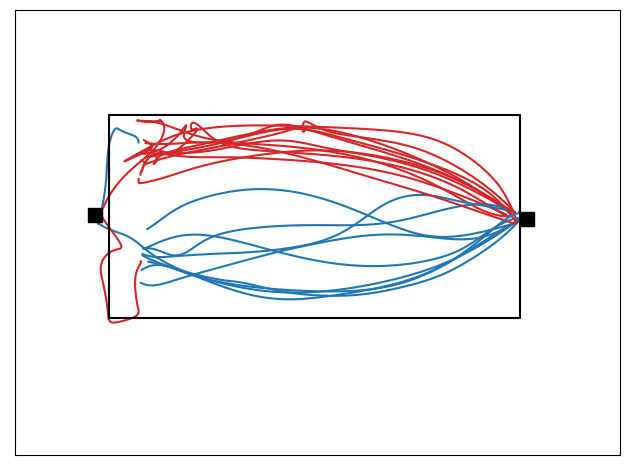

In [81]:
data = train_G8CK1_df[(train_G8CK1_df.date_index==-1)&(train_G8CK1_df.odd=='left')&(train_G8CK1_df.time<=10)]
#thresh = data.time.mean()
#data = data[data.time<=thresh]



#array_list.append(array)
fig,ax = plt.subplots()
ax.set_xticks([])
ax.set_yticks([])
plot_arena(data,ax)
for ind, row in data.sample(20).iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    if row.turn_direction == 'up':
        ax.plot(x.astype(float),y.astype(float),color ='tab:red',zorder=0)
    else:
        ax.plot(x.astype(float),y.astype(float),color ='tab:blue',zorder=0)
plt.tight_layout()
fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final_v_4\mon_distance_at_turn_histogram.pdf", dpi=300, transparent=True)


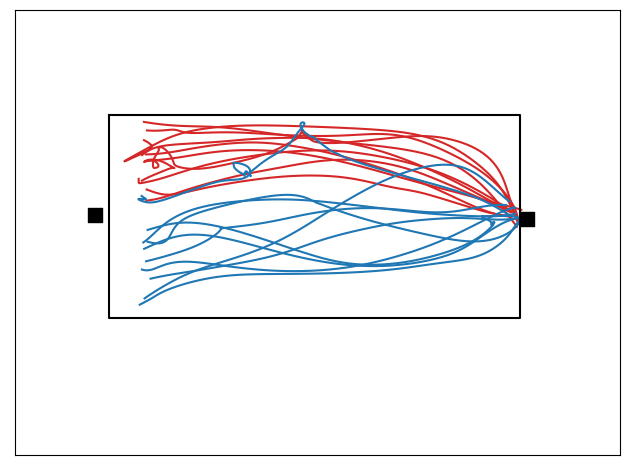

In [82]:
data = train_G8CK1_df[(train_G8CK1_df.date_index==-1)&(train_G8CK1_df.odd=='left')&(train_G8CK1_df.time<=10)]
#thresh = data.time.mean()
#data = data[data.time<=thresh]

fig, ax = plt.subplots()
ax.set_xticks([])
ax.set_yticks([])
plot_arena(data, ax)

# Sample 10 trials from each turn direction
#up_trials = data[data.turn_direction == 'up'].sample(10)
#down_trials = data[data.turn_direction == 'down'].sample(10)

# Plot 'up' trials in red
for ind, row in up_trials.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float), 3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float), 3)
    ax.plot(x.astype(float), y.astype(float), color='tab:red', zorder=0)

# Plot 'down' trials in blue
for ind, row in down_trials.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float), 3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float), 3)
    ax.plot(x.astype(float), y.astype(float), color='tab:blue', zorder=0)
plt.tight_layout()
fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final_v_4\mon_distance_at_turn_histogram.pdf", dpi=300, transparent=True)

In [201]:
train_df.groupby(['animal']).count()

,level_0,index,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,nose_likelihood,leftear_x,...,linearity,date_index,start,head_angle,head_angle_whole_trial,head_angle_velocity,head_angle_velocity_whole_trial,turn_direction,turn_direction_end,turn_direction_left_right
animal,,,,,,,,,,,,,,,,,,,,,
G8CK1LN,672,672,672,672,672,672,672,672,672,672,...,672,672,672,672,672,672,672,672,672,672
G8CK1LT,544,544,544,544,544,544,544,544,544,544,...,544,544,543,544,544,544,544,544,544,544
G8CK1RT,584,584,584,584,584,584,584,584,584,584,...,584,584,584,584,584,584,584,584,584,584
G8CK1TT,706,706,706,706,706,706,706,706,706,706,...,706,706,705,706,706,706,706,706,706,706
G8CKLN,864,864,864,864,864,864,864,864,864,864,...,864,864,850,864,864,864,864,864,864,864
G8CKLT,608,608,608,608,608,608,608,608,608,608,...,608,608,598,608,608,608,608,608,608,608
G8CKRN,816,816,816,816,816,816,816,816,816,816,...,816,816,812,816,816,816,816,816,816,816
G8CKRT,936,936,936,936,936,936,936,936,936,936,...,936,936,926,936,936,936,936,936,936,936
G8CKTT,988,988,988,988,988,988,988,988,988,988,...,988,988,969,988,988,988,988,988,988,988


<AxesSubplot: >

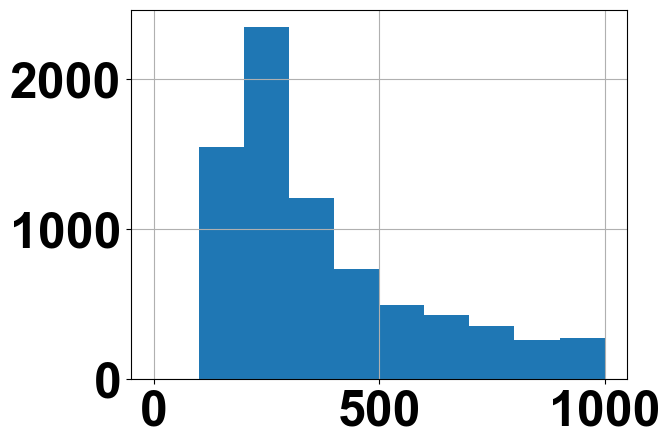

In [223]:
train_df.len.hist(range=(0,1000))

In [370]:
group_df

,level_0,index,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,nose_likelihood,leftear_x,...,linearity,date_index,start,head_angle,head_angle_whole_trial,head_angle_velocity,head_angle_velocity_whole_trial,turn_direction,turn_direction_end,turn_direction_left_right
8453,1735,1,41963.318451,41967.423065,"[41963.323776, 41963.340723, 41963.35726, 4196...","[[672, 673, 674, 675, 676, 677, 678, 679, 680,...","[655.7756958007812, 655.7756958007812, 655.775...","[241.73504638671878, 241.73504638671878, 241.7...","[0.07601401954889297, 0.08751232922077179, 0.0...","[651.5118182567265, 651.5835302800729, 651.723...",...,0.865817,-1.0,top,"[25.384023036943745, 24.598103560002592, 23.28...","[95.74858990007903, 95.53825876666505, 95.1246...","[-0.823012951690486, -1.3786858654727707, -1.5...","[-0.823012951690486, -1.3786858654727707, -1.5...",up,NaN,left
8455,1737,3,41972.178816,41976.938726,"[41972.194329, 41972.210176, 41972.22702, 4197...","[[1204, 1205, 1206, 1207, 1208, 1209, 1210, 12...","[656.1240844726562, 656.1240844726562, 656.124...","[247.69033813476562, 247.69033813476562, 247.6...","[0.0926070511341095, 0.08020554482936859, 0.10...","[652.2444578803711, 652.2679994058543, 652.305...",...,0.833870,-1.0,top,"[56.812688629022595, 55.82563281190351, 53.950...","[94.55565641259822, 94.55183728539748, 94.5464...","[-1.0336424345814588, -1.964031983366119, -2.7...","[-1.0336424345814588, -1.964031983366119, -2.7...",up,NaN,left
8476,1758,25,42084.795532,42088.351232,"[42084.799782, 42084.81591, 42084.832473, 4208...","[[7958, 7959, 7960, 7961, 7962, 7963, 7964, 79...","[656.3755493164062, 656.3755493164062, 656.375...","[243.11814880371094, 243.11814880371094, 243.1...","[0.10827839374542236, 0.09808196127414703, 0.0...","[652.2866390071374, 652.3374840484059, 652.439...",...,0.759502,-1.0,top,"[38.82317502102475, 38.15416006472576, 37.0710...","[91.76293382944561, 91.65440643509862, 91.4312...","[-0.7005908239502068, -1.1342427628358487, -1....","[-0.7005908239502068, -1.1342427628358487, -1....",up,NaN,left
8478,1760,27,42093.508531,42096.388275,"[42093.51904, 42093.535654, 42093.553664, 4209...","[[8481, 8482, 8483, 8484, 8485, 8486, 8487, 84...","[656.2421875, 656.2421875, 656.2421875, 656.24...","[241.3168487548828, 241.3168487548828, 241.316...","[0.13472431898117065, 0.10486368089914322, 0.0...","[653.4058318589911, 653.5145262536183, 653.720...",...,0.847299,-1.0,top,"[42.625833295298975, 41.21188951336531, 38.736...","[89.81656038418731, 89.5103075096797, 88.93150...","[-1.4806784659705952, -2.5927028485002412, -3....","[-1.4806784659705952, -2.5927028485002412, -3....",up,NaN,left
8494,1776,43,42152.672115,42155.752435,"[42152.672742, 42152.689996, 42152.706252, 421...","[[12029, 12030, 12031, 12032, 12033, 12034, 12...","[653.5599365234375, 653.5599365234375, 653.559...","[224.89178466796875, 224.89178466796875, 224.8...","[0.08419839292764664, 0.17895729839801788, 0.0...","[655.0599295457025, 655.1815954484888, 655.409...",...,0.969806,-1.0,top,"[33.94984008260996, 32.5426228435347, 30.03314...","[88.34015177463357, 88.21768225025704, 87.9843...","[-1.4736344467612517, -2.627919918632533, -3.3...","[-1.4736344467612517, -2.627919918632533, -3.3...",up,NaN,left
8496,1778,45,42161.655424,42164.088614,"[42161.65966, 42161.675942, 42161.693324, 4216...","[[12568, 12569, 12570, 12571, 12572, 12573, 12...","[656.2716674804689, 656.2716674804689, 656.271...","[245.59593200683594, 245.59593200683594, 245.5...","[0.09675757586956024, 0.05276951193809509, 0.1...","[650.8048194674601, 650.925025714969, 651.1494...",...,0.935207,-1.0,top,"[46.90948977279578, 45.235074346510416, 42.305...","[95.25841760515537, 94.97542312142366, 94.4410...","[-1.7534437340918374, -3.067433121325507, -3.7...","[-1.7534437340918374, -3.067433121325507, -3.7...",up,NaN,left
8502,1784,51,42191.960051,42194.893030,"[42191.969612, 42191.98656, 42192.002867, 4219...","[[14386, 14387, 14388, 14389, 14390, 14391, 14...","[652.8280639

In [382]:
np.mean(trials)

15.826713228517628

In [544]:
## data population std in y 
population = train_df[(train_df.time<=10)]
grouped_data = population.groupby(['date_index','animal','odd','turn_direction'])
grouped_dict = {
    'date_index': [],
    'animal': [],
    'odd': [],
    'turn_direction': [],
    'std_dev': []
}
## create i want 
for group,group_df in grouped_data:
    mean_y,trials = get_mean_of_df(group_df,'ts_nose_y_cm',matx=True,bins=50)
    trials = trials - trials[:, 0:1]
    std = np.std(trials,axis=0).mean()
    grouped_dict['date_index'].append(group_df.date_index.unique()[0])
    grouped_dict['animal'].append(group_df.animal.unique()[0])
    grouped_dict['odd'].append(group_df.odd.unique()[0])
    grouped_dict['turn_direction'].append(group_df.turn_direction.unique()[0])
    grouped_dict['std_dev'].append(std)

grouped_df = pd.DataFrame.from_dict(grouped_dict)
    

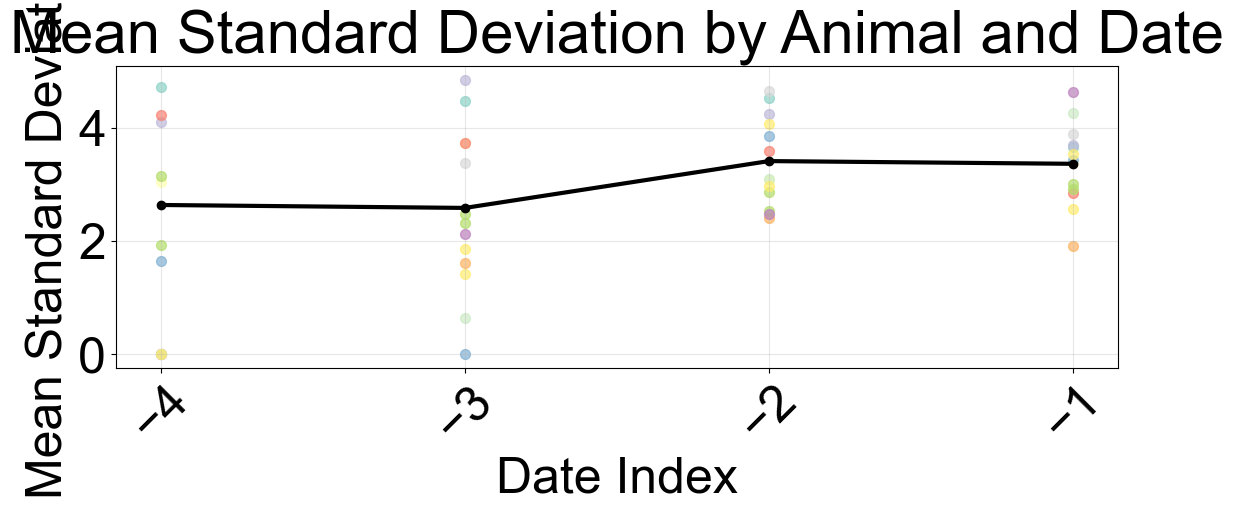

In [546]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Sample data creation (replace with your actual DataFrame)


# Calculate mean std deviation for each animal at each date
animal_means = grouped_df.groupby(['date_index', 'animal'])['std_dev'].mean().reset_index()

# Calculate overall mean across all animals at each date
overall_means = grouped_df.groupby('date_index')['std_dev'].mean().reset_index()

# Create the plot
plt.figure(figsize=(12, 6))

# Plot each animal as scatter points
animals = animal_means['animal'].unique()
colors = plt.cm.Set3(np.linspace(0, 1, len(animals)))

for i, animal in enumerate(animals):
    animal_data = animal_means[animal_means['animal'] == animal]
    plt.scatter(animal_data['date_index'], animal_data['std_dev'], 
                color=colors[i], alpha=0.7, s=50, label=animal)

# Plot overall mean as a line
plt.plot(overall_means['date_index'], overall_means['std_dev'], 
         color='black', linewidth=3, label='Overall Mean', marker='o', markersize=6)

# Customize the plot
plt.title('Mean Standard Deviation by Animal and Date')
plt.xlabel('Date Index')
plt.ylabel('Mean Standard Deviation')
#plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [550]:
## data population std in y 
light = light_dark[light_dark.task == 'oadark']
population = light[(light.time<=10)]
grouped_data = population.groupby(['date_index','animal','odd','turn_direction','obstacle_cluster'])
grouped_dict = {
    'date_index': [],
    'animal': [],
    'odd': [],
    'turn_direction': [],
    'std_dev': [],
    'obstacle_cluster':[]
}
## create i want 
for group,group_df in grouped_data:
    mean_y,trials = get_mean_of_df(group_df,'ts_nose_y_cm',matx=True,bins=50)
    trials = trials - trials[:, 0:1]
    std = np.std(trials,axis=0).mean()
    grouped_dict['date_index'].append(group_df.date_index.unique()[0])
    grouped_dict['animal'].append(group_df.animal.unique()[0])
    grouped_dict['odd'].append(group_df.odd.unique()[0])
    grouped_dict['turn_direction'].append(group_df.turn_direction.unique()[0])
    grouped_dict['obstacle_cluster'].append(group_df.obstacle_cluster.unique()[0])
    grouped_dict['std_dev'].append(std)

grouped_df = pd.DataFrame.from_dict(grouped_dict)

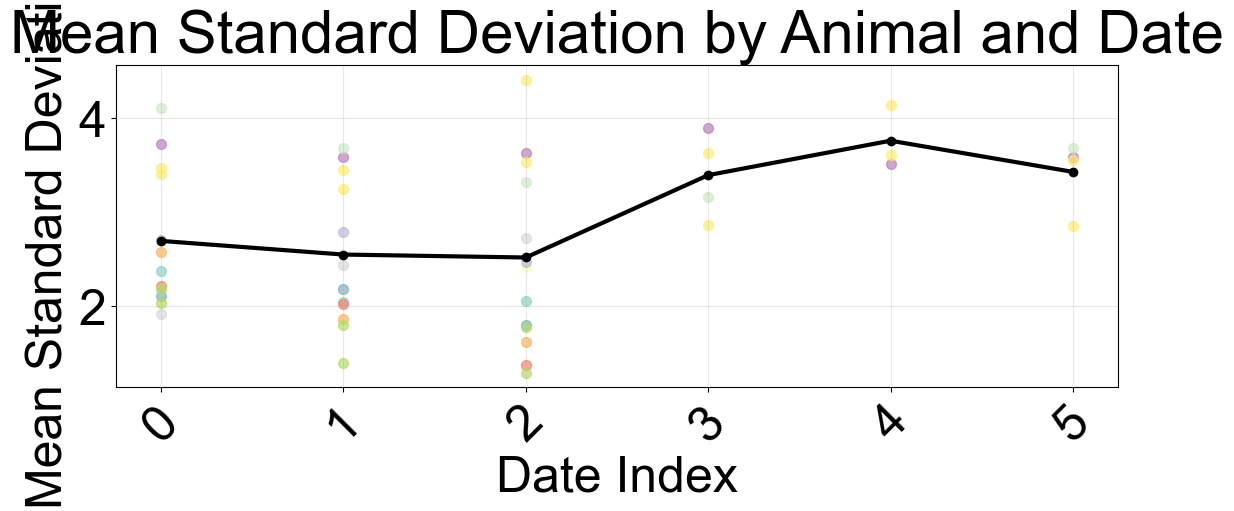

In [551]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Sample data creation (replace with your actual DataFrame)


# Calculate mean std deviation for each animal at each date
animal_means = grouped_df.groupby(['date_index', 'animal'])['std_dev'].mean().reset_index()

# Calculate overall mean across all animals at each date
overall_means = grouped_df.groupby('date_index')['std_dev'].mean().reset_index()

# Create the plot
plt.figure(figsize=(12, 6))

# Plot each animal as scatter points
animals = animal_means['animal'].unique()
colors = plt.cm.Set3(np.linspace(0, 1, len(animals)))

for i, animal in enumerate(animals):
    animal_data = animal_means[animal_means['animal'] == animal]
    plt.scatter(animal_data['date_index'], animal_data['std_dev'], 
                color=colors[i], alpha=0.7, s=50, label=animal)

# Plot overall mean as a line
plt.plot(overall_means['date_index'], overall_means['std_dev'], 
         color='black', linewidth=3, label='Overall Mean', marker='o', markersize=6)

# Customize the plot
plt.title('Mean Standard Deviation by Animal and Date')
plt.xlabel('Date Index')
plt.ylabel('Mean Standard Deviation')
#plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [372]:
std_df = {
    'date_index': [],
    'animal': [],
    'odd': [],
    'turn_direction': [],
    'std_dev': []
}
std_df

{'date_index': [],
 'animal': [],
 'odd': [],
 'turn_direction': [],
 'std_dev': []}

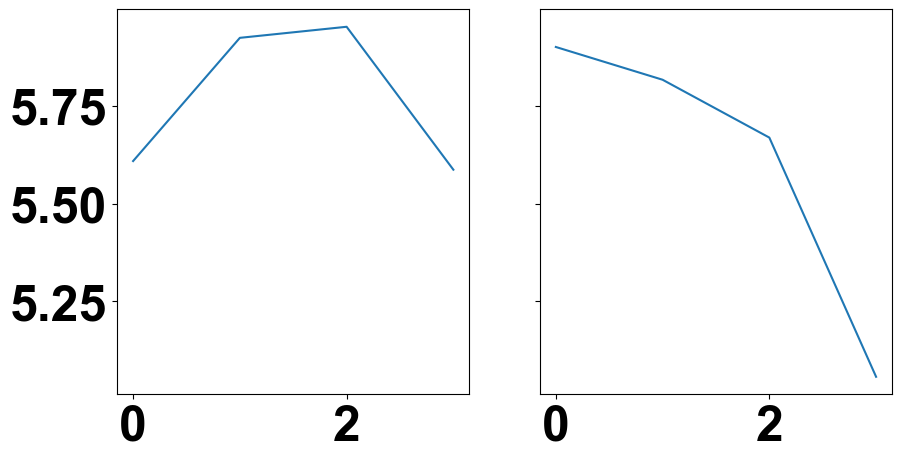

In [ ]:
# Create figure and subplots with shared y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

## data population std in y 
population = train_df[(train_df.time<=10)]


for date in population.date_index.unique():
    
    _,up_trials = get_mean_of_df(up[up.date_index == date],'ts_nose_y_cm',matx=True,bins=100)
    up_std = np.std(up_trials)
    up_pop_std.append(up_std)
    _,down_trials = get_mean_of_df(down[down.date_index == date],'ts_nose_y_cm',matx=True,bins=100)
    down_std = np.std(down_trials)
    down_pop_std.append(down_std)
ax1.plot(up_pop_std)
ax2.plot(down_pop_std)





In [ ]:
# Create figure and subplots with shared y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

## data population std in y 
population = train_df[(train_df.time<=10)]

up = population[population.turn_direction == 'up']
down = population[population.turn_direction == 'down']


up_pop_std = []
down_pop_std = []
for date in population.date_index.unique():
    _,up_trials = get_mean_of_df(up[up.date_index == date],'ts_nose_y_cm',matx=True,bins=100)
    up_std = np.std(up_trials)
    up_pop_std.append(up_std)
    _,down_trials = get_mean_of_df(down[down.date_index == date],'ts_nose_y_cm',matx=True,bins=100)
    down_std = np.std(down_trials)
    down_pop_std.append(down_std)
ax1.plot(up_pop_std)
ax2.plot(down_pop_std)

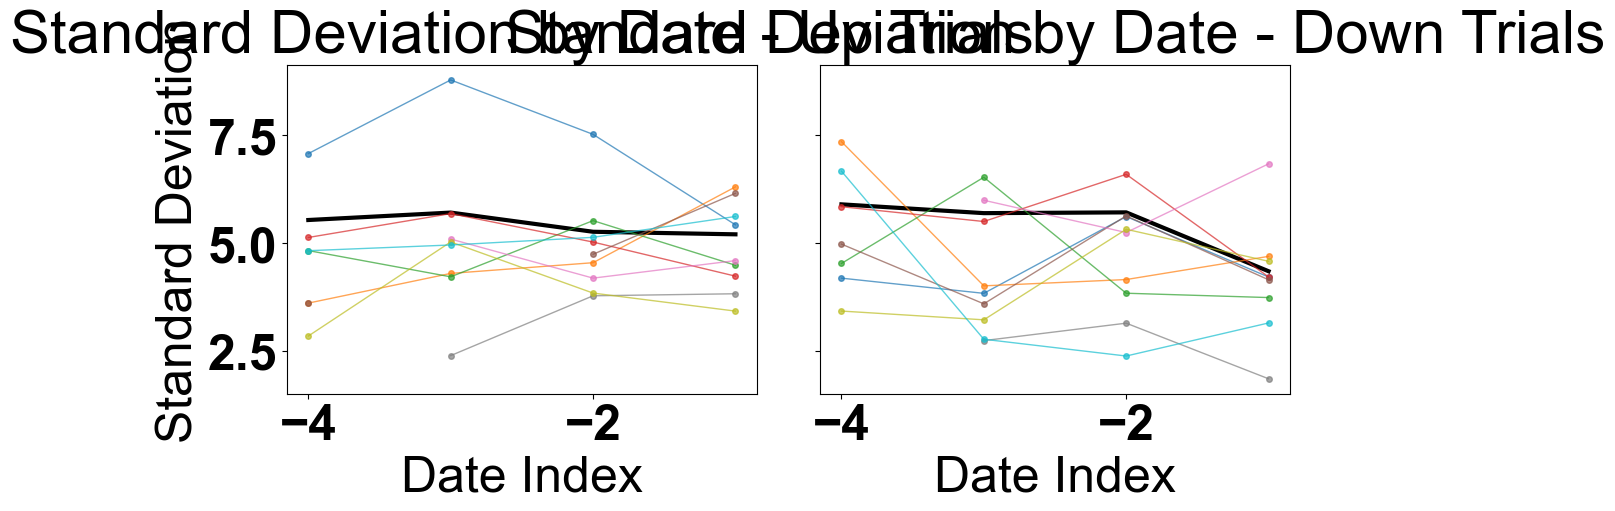

In [366]:
# Create figure and subplots with shared y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

## data population std in y 

data = train_df[~train_df['animal'].isin(['J701LT','J701NN','J701RN','J701RT'])] 
population = data[(data.odd=='left')&(data.time<=10)]
#population = train_df[(train_df.odd=='left')&(train_df.time<=10)]

up = population[population.turn_direction == 'up']
down = population[population.turn_direction == 'down']

# Get unique animals and date indices
animals = sorted(population.animal.unique())
date_indices = sorted(population.date_index.unique())

# Create dictionaries to store std values by animal
up_std_by_animal = {animal: [] for animal in animals}
down_std_by_animal = {animal: [] for animal in animals}

# Also store the overall population std (your original calculation)
up_pop_std = []
down_pop_std = []

for date in date_indices:
    # Overall population std (your original calculation)
    _, up_trials = get_median_of_df(up[up.date_index == date], 'ts_nose_y_cm', matx=True, bins=100)
    up_std = np.std(up_trials)
    up_pop_std.append(up_std)
    
    _, down_trials = get_median_of_df(down[down.date_index == date], 'ts_nose_y_cm', matx=True, bins=100)
    down_std = np.std(down_trials)
    down_pop_std.append(down_std)
    
    # Individual animal std by date
    for animal in animals:
        up_animal_date = up[(up.animal == animal) & (up.date_index == date)]
        down_animal_date = down[(down.animal == animal) & (down.date_index == date)]
        
        if len(up_animal_date) > 0:
            _, up_animal_trials = get_median_of_df(up_animal_date, 'ts_nose_y_cm', matx=True, bins=100)
            up_animal_std = np.std(up_animal_trials)
            up_std_by_animal[animal].append(up_animal_std)
        else:
            up_std_by_animal[animal].append(np.nan)
            
        if len(down_animal_date) > 0:
            _, down_animal_trials = get_median_of_df(down_animal_date, 'ts_nose_y_cm', matx=True, bins=100)
            down_animal_std = np.std(down_animal_trials)
            down_std_by_animal[animal].append(down_animal_std)
        else:
            down_std_by_animal[animal].append(np.nan)

# Plot overall population std (thick line)
ax1.plot(date_indices, up_pop_std, 'k-', linewidth=3, label='Population')
ax2.plot(date_indices, down_pop_std, 'k-', linewidth=3, label='Population')

# Plot individual animal std (thin lines with different colors/markers)
colors = plt.cm.tab10(np.linspace(0, 1, len(animals)))
for i, animal in enumerate(animals):
    ax1.plot(date_indices, up_std_by_animal[animal], 'o-', color=colors[i], 
             markersize=4, linewidth=1, alpha=0.7, label=animal)
    ax2.plot(date_indices, down_std_by_animal[animal], 'o-', color=colors[i], 
             markersize=4, linewidth=1, alpha=0.7, label=animal)

# Customize plots
ax1.set_title('Standard Deviation by Date - Up Trials')
ax1.set_xlabel('Date Index')
ax1.set_ylabel('Standard Deviation')
#ax1.legend()

ax2.set_title('Standard Deviation by Date - Down Trials')
ax2.set_xlabel('Date Index')
#ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
def compute_frenchet_distance(df):
    """returns df each row is the average frenchet distance of a cluster by direction, turn_direction, animal, and date_index"""
    dictists = {key: [] for key in ['animal','date_index',"trials",'fdist','turn_direction','odd']}
    df = df
    for date_id,date_id_df in df.groupby(['date_index']):
        for ani, ani_df in date_id_df.groupby(['animal']):
            for turn_direction,turn_direction_df in ani_df.groupby('turn_direction'):
                for odd,odd_df in turn_direction_df.groupby('odd'):
                    dictists['animal'].append(ani)
                    dictists['date_index'].append(odd_df.date_index.unique()[0])
                    dictists['trials'].append(len(odd_df))
                    #dictists['obstacle_cluster'].append(odd_df.obstacle_cluster.unique()[0])
                    dictists['turn_direction'].append(odd_df.turn_direction.unique()[0])
                    dictists['odd'].append(odd_df.odd.unique()[0])
                    if len(odd_df) >=4:
                        sl, matx, maty = create_streamlines(odd_df,'ts_nose_x_cm','ts_nose_y_cm')
                        fdist_avg = []
                        for i,row in enumerate(sl):
                            fdist_list = []
                            for traj in sl: 
                                avg_fdist = frdist(sl[i],traj)
                                fdist_list.append(avg_fdist)
                            fdist_avg.append(np.nanmean(fdist_list))
                        dictists['fdist'].append(np.mean(fdist_avg))
                    else:
                        dictists['fdist'].append(np.nan)
    f_dist_df = pd.DataFrame.from_dict(dictists)
    return f_dist_df

In [ ]:
mean = np.nanmean(mat, axis=0)

        df = pd.Series(mean)
        df.fillna(method='bfill', axis=0, inplace=True)
        df.fillna(method='ffill', axis=0, inplace=True)
        mean = df.to_numpy()

In [ ]:
def compute_frenchet_distance_from_mean(df):
    """returns df each row is the average frenchet distance of a cluster by direction, turn_direction, animal, and date_index"""
    dictists = {key: [] for key in ['animal','date_index',"trials",'fdist','turn_direction','odd']}
    df = df
    for date_id,date_id_df in df.groupby(['date_index']):
        for ani, ani_df in date_id_df.groupby(['animal']):
            for turn_direction,turn_direction_df in ani_df.groupby('turn_direction'):
                for odd,odd_df in turn_direction_df.groupby('odd'):
                    dictists['animal'].append(ani)
                    dictists['date_index'].append(odd_df.date_index.unique()[0])
                    dictists['trials'].append(len(odd_df))
                    #dictists['obstacle_cluster'].append(odd_df.obstacle_cluster.unique()[0])
                    dictists['turn_direction'].append(odd_df.turn_direction.unique()[0])
                    dictists['odd'].append(odd_df.odd.unique()[0])
                    if len(odd_df) >=4:
                        sl, matx, maty = create_streamlines(odd_df,'ts_nose_x_cm','ts_nose_y_cm')
                        fdist_avg = []
                        for i,row in enumerate(sl):
                            fdist_list = []
                            for traj in sl: 
                                avg_fdist = frdist(sl[i],traj)
                                fdist_list.append(avg_fdist)
                            fdist_avg.append(np.nanmean(fdist_list))
                        dictists['fdist'].append(np.mean(fdist_avg))
                    else:
                        dictists['fdist'].append(np.nan)
    f_dist_df = pd.DataFrame.from_dict(dictists)
    return f_dist_df

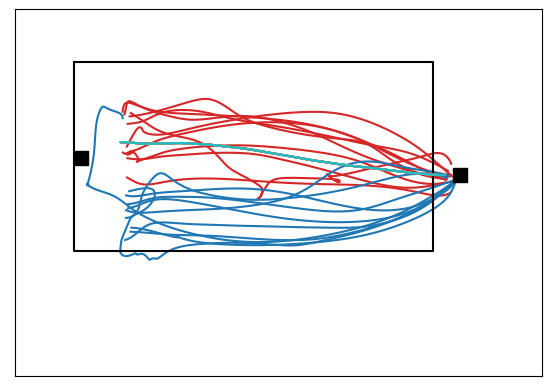

In [302]:
#data = train_G8CK1_df[(train_G8CK1_df.date_index==-1)&(train_G8CK1_df.odd=='left')&(train_G8CK1_df.time<=10)]
#thresh = data.time.mean()
#data = data[data.time<=thresh]

fig, ax = plt.subplots()
ax.set_xticks([])
ax.set_yticks([])
plot_arena(data, ax)

data = train_df[~train_df['animal'].isin(['J701LT','J701NN','J701RN','J701RT'])] 
population = data[(data.odd=='left')&(data.time<=10)]

up = population[population.turn_direction == 'up']
sl, matx, maty = create_streamlines(up,'ts_nose_x_cm','ts_nose_y_cm')

# Sample 10 trials from each turn direction
data = train_G8CK1_df[(train_G8CK1_df.date_index==-1)&(train_G8CK1_df.odd=='left')&(train_G8CK1_df.time<=10)]
up_trials = data[data.turn_direction == 'up'].sample(10)
down_trials = data[data.turn_direction == 'down'].sample(10)

# Plot 'up' trials in red
for ind, row in up_trials.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float), 3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float), 3)
    ax.plot(x.astype(float), y.astype(float), color='tab:red', zorder=0)
    
    ax.plot(np.mean(matx,axis=0),np.mean(maty,axis=0))

# Plot 'down' trials in blue
for ind, row in down_trials.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float), 3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float), 3)
    ax.plot(x.astype(float), y.astype(float), color='tab:blue', zorder=0)
plt.tight_layout()

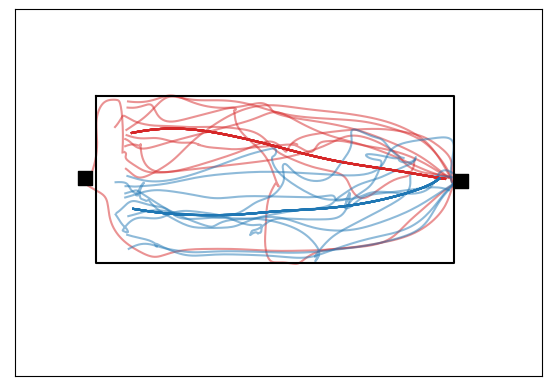

In [363]:




fig, ax = plt.subplots()
ax.set_xticks([])
ax.set_yticks([])


data = train_df[~train_df['animal'].isin(['J701LT','J701NN','J701RN','J701RT'])] 
population = data[(data.odd=='left')&(data.time<=10)&(data.date_index==-4)]
plot_arena(population, ax)

up = population[population.start == 'top']
down = population[population.start == 'bottom']
up_sl, up_matx, up_maty = create_streamlines(up,'ts_nose_x_cm','ts_nose_y_cm')
down_sl, down_matx, down_maty = create_streamlines(down,'ts_nose_x_cm','ts_nose_y_cm')

# Sample 10 trials from each turn direction
#data = train_G8CK1_df[(train_G8CK1_df.date_index==-1)&(train_G8CK1_df.odd=='left')&(train_G8CK1_df.time<=10)]
up_trials = up.sample(10)
down_trials = down.sample(10)

# Plot 'up' trials in red
for ind, row in up_trials.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float), 3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float), 3)
    ax.plot(x.astype(float), y.astype(float), color='tab:red', zorder=0,alpha=.5)
    
    ax.plot(gaussian_filter(np.mean(up_matx,axis=0),3),gaussian_filter(np.mean(up_maty,axis=0),3),color='tab:red')

# Plot 'down' trials in blue
for ind, row in down_trials.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float), 3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float), 3)
    ax.plot(x.astype(float), y.astype(float), color='tab:blue', zorder=0,alpha=.5)
    ax.plot(gaussian_filter(np.mean(down_matx,axis=0),3),gaussian_filter(np.mean(down_maty,axis=0),3), color='tab:blue')
plt.tight_layout()

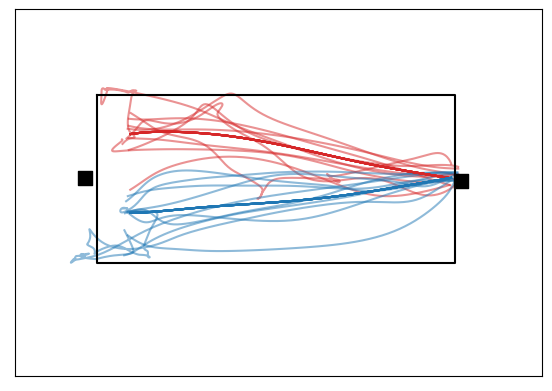

In [362]:




fig, ax = plt.subplots()
ax.set_xticks([])
ax.set_yticks([])


data = train_df[~train_df['animal'].isin(['J701LT','J701NN','J701RN','J701RT'])] 
population = data[(data.odd=='left')&(data.time<=10)&(data.date_index==-1)]
plot_arena(population, ax)

up = population[population.start == 'top']
down = population[population.start == 'bottom']
up_sl, up_matx, up_maty = create_streamlines(up,'ts_nose_x_cm','ts_nose_y_cm')
down_sl, down_matx, down_maty = create_streamlines(down,'ts_nose_x_cm','ts_nose_y_cm')

# Sample 10 trials from each turn direction
#data = train_G8CK1_df[(train_G8CK1_df.date_index==-1)&(train_G8CK1_df.odd=='left')&(train_G8CK1_df.time<=10)]
up_trials = up.sample(10)
down_trials = down.sample(10)

# Plot 'up' trials in red
for ind, row in up_trials.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float), 3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float), 3)
    ax.plot(x.astype(float), y.astype(float), color='tab:red', zorder=0,alpha=.5)
    
    ax.plot(gaussian_filter(np.mean(up_matx,axis=0),3),gaussian_filter(np.mean(up_maty,axis=0),3),color='tab:red')

# Plot 'down' trials in blue
for ind, row in down_trials.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float), 3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float), 3)
    ax.plot(x.astype(float), y.astype(float), color='tab:blue', zorder=0,alpha=.5)
    ax.plot(gaussian_filter(np.mean(down_matx,axis=0),3),gaussian_filter(np.mean(down_maty,axis=0),3), color='tab:blue')
plt.tight_layout()

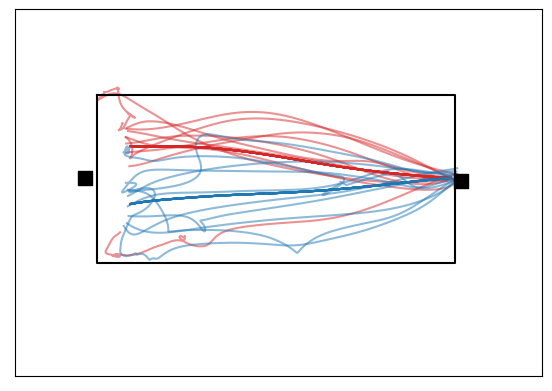

In [354]:




fig, ax = plt.subplots()
ax.set_xticks([])
ax.set_yticks([])


data = train_df[~train_df['animal'].isin(['J701LT','J701NN','J701RN','J701RT'])] 
population = data[(data.odd=='left')&(data.time<=10)&(data.date_index==-1)]
plot_arena(population, ax)

up = population[population.turn_direction == 'up']
down = population[population.turn_direction == 'down']
up_sl, up_matx, up_maty = create_streamlines(up,'ts_nose_x_cm','ts_nose_y_cm')
down_sl, down_matx, down_maty = create_streamlines(down,'ts_nose_x_cm','ts_nose_y_cm')

# Sample 10 trials from each turn direction
#data = train_G8CK1_df[(train_G8CK1_df.date_index==-1)&(train_G8CK1_df.odd=='left')&(train_G8CK1_df.time<=10)]
up_trials = up.sample(10)
down_trials = down.sample(10)

# Plot 'up' trials in red
for ind, row in up_trials.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float), 3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float), 3)
    ax.plot(x.astype(float), y.astype(float), color='tab:red', zorder=0,alpha=.5)
    
    ax.plot(gaussian_filter(np.mean(up_matx,axis=0),3),gaussian_filter(np.mean(up_maty,axis=0),3),color='tab:red')

# Plot 'down' trials in blue
for ind, row in down_trials.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float), 3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float), 3)
    ax.plot(x.astype(float), y.astype(float), color='tab:blue', zorder=0,alpha=.5)
    ax.plot(gaussian_filter(np.mean(down_matx,axis=0),3),gaussian_filter(np.mean(down_maty,axis=0),3), color='tab:blue')
plt.tight_layout()

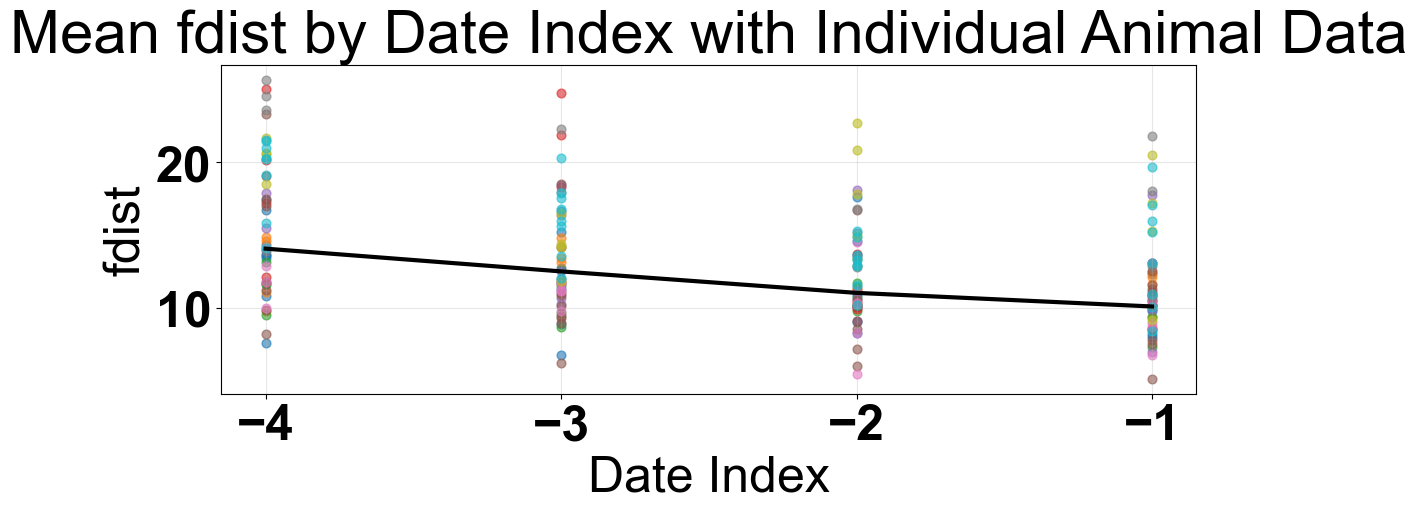

In [367]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming train_f_dist_df is your DataFrame
# Calculate overall mean

data = train_f_dist_df[~train_f_dist_df['animal'].isin(['J701LT','J701NN','J701RN','J701RT'])] 
overall_mean = data.groupby('date_index')['fdist'].mean().reset_index()

# Create the plot
plt.figure(figsize=(12, 6))

# Plot overall mean line
plt.plot(overall_mean['date_index'], overall_mean['fdist'], 
         color='black', linewidth=3, label='Overall Mean')

# Get unique animals for coloring
animals = train_f_dist_df['animal'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(animals)))

# Plot scatter points for each animal
for i, animal in enumerate(animals):
    animal_data = train_f_dist_df[train_f_dist_df['animal'] == animal]
    plt.scatter(animal_data['date_index'], animal_data['fdist'], 
                color=colors[i], alpha=0.6, s=40, label=f'Animal {animal}')

plt.xlabel('Date Index')
plt.ylabel('fdist')
plt.title('Mean fdist by Date Index with Individual Animal Data')
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [240]:
down_pop_std

[5.90073858255376, 5.81692768518525, 5.66893933236326, 5.057026057509516]

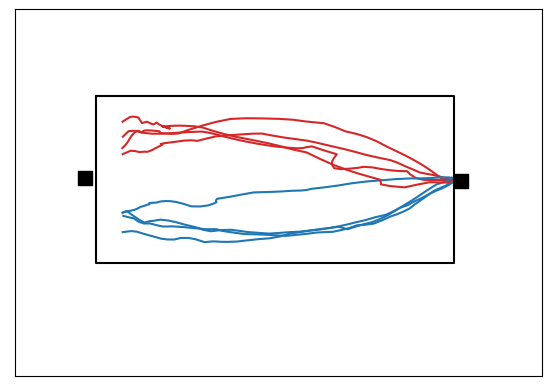

In [216]:
data = train_G8CK1_df[(train_G8CK1_df.date_index==-2)&(train_G8CK1_df.odd=='left')&(train_G8CK1_df.time<=10)]
#thresh = data.time.mean()
#data = data[data.time<=thresh]

fig, ax = plt.subplots()
ax.set_xticks([])
ax.set_yticks([])
plot_arena(data, ax)

# Sample 10 trials from each turn direction
for ani in data.animal.unique():
    ani_df = data[data.animal == ani]

    up_trials = ani_df[ani_df.turn_direction == 'up']
    down_trials = ani_df[ani_df.turn_direction == 'down']
    up_median_x = get_median_of_df(up_trials,'ts_nose_x_cm',50)
    up_median_y= get_median_of_df(up_trials,'ts_nose_y_cm',50)
    
    down_median_x = get_median_of_df(down_trials,'ts_nose_x_cm',50)
    down_median_y= get_median_of_df(down_trials,'ts_nose_y_cm',50)



    ax.plot(up_median_x.astype(float), up_median_y.astype(float), color='tab:red', zorder=0)


    ax.plot(down_median_x.astype(float), down_median_y.astype(float), color='tab:blue', zorder=0)
plt.tight_layout()
#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final_v_4\mon_distance_at_turn_histogram.pdf", dpi=300, transparent=True)

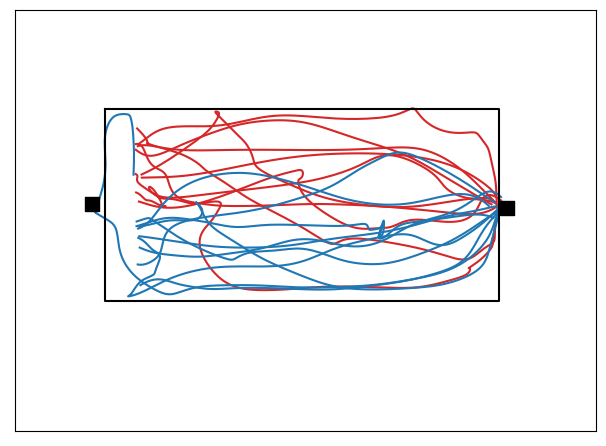

In [173]:
data = train_G8CK1_df[(train_G8CK1_df.date_index==-4)&(train_G8CK1_df.odd=='left')&(train_G8CK1_df.time<=10)]
#thresh = data.time.mean()
#data = data[data.time<=thresh]

fig, ax = plt.subplots()
ax.set_xticks([])
ax.set_yticks([])
plot_arena(data, ax)

# Sample 10 trials from each turn direction
up_trials = data[data.turn_direction == 'up'].sample(10)
down_trials = data[data.turn_direction == 'down'].sample(10)

# Plot 'up' trials in red
for ind, row in up_trials.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float), 3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float), 3)
    ax.plot(x.astype(float), y.astype(float), color='tab:red', zorder=0)

# Plot 'down' trials in blue
for ind, row in down_trials.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float), 3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float), 3)
    ax.plot(x.astype(float), y.astype(float), color='tab:blue', zorder=0)
plt.tight_layout()
fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final_v_4\early_training_traces.pdf", dpi=300, transparent=True)

In [175]:
light_data.turn_direction

0         up
1       down
2       down
3         up
4       down
        ... 
9241    down
9242    down
9243    down
9244    down
9245    down
Name: turn_direction, Length: 9246, dtype: object

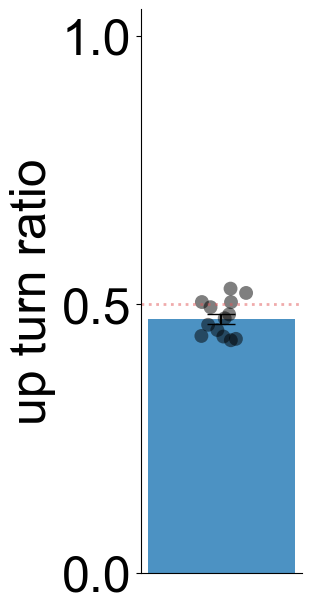

In [470]:
font = {'family': 'arial', 'size': 36}
plt.rc('font', **font)

# Create figure
fig, ax = plt.subplots(figsize=(4, 7))

# Prepare data - using light_dark dataframe and filtering for light condition
light_data = train_df

# Group level calculation
total = len(light_data)
up = len(light_data[light_data['turn_direction'] == 'up']) if total > 0 else 0
ratio = up / total if total > 0 else 0

# Individual animal calculation
animal_ratios = []
for animal in light_data['animal'].unique():
    animal_data = light_data[light_data['animal'] == animal]
    a_total = len(animal_data)
    a_up = len(animal_data[animal_data['turn_direction'] == 'up']) if a_total > 0 else 0
    a_ratio = a_up / a_total if a_total > 0 else 0
    animal_ratios.append(a_ratio)

# Calculate standard error
se = np.std(animal_ratios) / np.sqrt(len(animal_ratios)) if animal_ratios else 0

# Plot settings
bar_width = 0.6
color = 'tab:blue' 
x_pos = 0  # Single bar position

# Plot 50% reference line (chance level for up/right turns)
ax.axhline(0.5, color='#e15759', linestyle=':', alpha=0.5, linewidth=2)

# Plot bar with error bar
ax.bar(x_pos, ratio, bar_width,
       color=color,
       edgecolor='none',
       alpha=0.8,
       yerr=se,
       capsize=10)

# Plot individual data points with jitter
jitter = np.random.normal(0, 0.05, size=len(animal_ratios))
ax.scatter(x_pos + jitter, animal_ratios,
           color='black', alpha=0.5, s=100, edgecolor='none')

# Customize plot
ax.set_ylabel('up turn ratio')
ax.set_xticks([])  # Remove x-axis ticks
ax.set_yticks([0, 0.5, 1.0])
ax.set_ylim(0, 1.05)  # Slightly above 1 for point visibility

# Remove unnecessary spines
ax.grid(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_visible(True)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final figures\up_ratio_light_bar.pdf",dpi = 300, transparent=True)
plt.show()

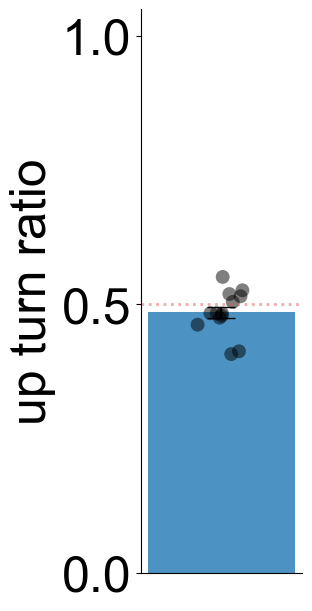

In [469]:
font = {'family': 'arial', 'size': 36}
plt.rc('font', **font)

# Create figure
fig, ax = plt.subplots(figsize=(4, 7))

# Prepare data - using light_dark dataframe and filtering for light condition
light_data = light

# Group level calculation
total = len(light_data)
up = len(light_data[light_data['turn_direction'] == 'up']) if total > 0 else 0
ratio = up / total if total > 0 else 0

# Individual animal calculation
animal_ratios = []
for animal in light_data['animal'].unique():
    animal_data = light_data[light_data['animal'] == animal]
    a_total = len(animal_data)
    a_up = len(animal_data[animal_data['turn_direction'] == 'up']) if a_total > 0 else 0
    a_ratio = a_up / a_total if a_total > 0 else 0
    animal_ratios.append(a_ratio)

# Calculate standard error
se = np.std(animal_ratios) / np.sqrt(len(animal_ratios)) if animal_ratios else 0

# Plot settings
bar_width = 0.6
color = 'tab:blue' 
x_pos = 0  # Single bar position

# Plot 50% reference line (chance level for up/right turns)
ax.axhline(0.5, color='#e15759', linestyle=':', alpha=0.5, linewidth=2)

# Plot bar with error bar
ax.bar(x_pos, ratio, bar_width,
       color=color,
       edgecolor='none',
       alpha=0.8,
       yerr=se,
       capsize=10)

# Plot individual data points with jitter
jitter = np.random.normal(0, 0.05, size=len(animal_ratios))
ax.scatter(x_pos + jitter, animal_ratios,
           color='black', alpha=0.5, s=100, edgecolor='none')

# Customize plot
ax.set_ylabel('up turn ratio')
ax.set_xticks([])  # Remove x-axis ticks
ax.set_yticks([0, 0.5, 1.0])
ax.set_ylim(0, 1.05)  # Slightly above 1 for point visibility

# Remove unnecessary spines
ax.grid(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_visible(True)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final figures\up_ratio_light_bar.pdf",dpi = 300, transparent=True)
plt.show()

meta NOT subset; don't know how to subset; dropped


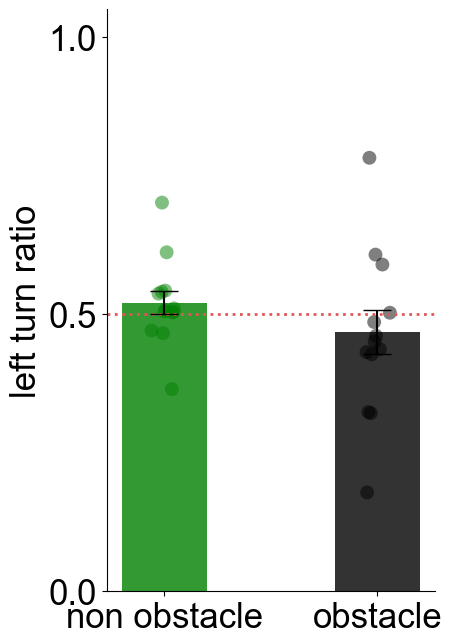

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

font = {'family': 'arial', 'size': 25}
plt.rc('font', **font)

# Create figure
fig, ax = plt.subplots(figsize=(5, 7))  # Wider figure to accommodate two bars

# Prepare data for both conditions
train_data = train_df
light_data = light_dark[light_dark.task =='oa']

# Function to calculate ratios and SE
def calculate_ratios(data):
    # Groleft level calculation
    total = len(data)
    left = len(data[data['turn_direction_left_right'] == 'left']) if total > 0 else 0
    ratio = left / total if total > 0 else 0
    
    # Individual animal calculation
    animal_ratios = []
    for animal in data['animal'].unique():
        animal_data = data[data['animal'] == animal]
        a_total = len(animal_data)
        a_left = len(animal_data[animal_data['turn_direction_left_right'] == 'left']) if a_total > 0 else 0
        a_ratio = a_left / a_total if a_total > 0 else 0
        animal_ratios.append(a_ratio)
    
    # Calculate standard error
    se = np.std(animal_ratios) / np.sqrt(len(animal_ratios)) if animal_ratios else 0
    
    return ratio, animal_ratios, se

# Calculate for both conditions
train_ratio, train_animal_ratios, train_se = calculate_ratios(train_data)
light_ratio, light_animal_ratios, light_se = calculate_ratios(light_data)

# Plot settings
bar_width = 0.4
x_positions = [0, 1]  # Training at position 0, Light at position 1

# Plot 50% reference line (chance level for left/right turns)
ax.axhline(0.5, color='#e15759', linestyle=':', alpha=1, linewidth=2)

# Plot bars with error bars
# Training data (green)
ax.bar(x_positions[0], train_ratio, bar_width,
       color='green',
       edgecolor='none',
       alpha=0.8,
       yerr=train_se,
       capsize=10,
       label='Training')

# Light data (black)
ax.bar(x_positions[1], light_ratio, bar_width,
       color='black',
       edgecolor='none',
       alpha=0.8,
       yerr=light_se,
       capsize=10,
       label='Light')

# Plot individual data points with jitter
# Training points (green)
train_jitter = np.random.normal(0, 0.03, size=len(train_animal_ratios))
ax.scatter(x_positions[0] + train_jitter, train_animal_ratios,
           color='green', alpha=0.5, s=100, edgecolor='none')

# Light points (black)
light_jitter = np.random.normal(0, 0.03, size=len(light_animal_ratios))
ax.scatter(x_positions[1] + light_jitter, light_animal_ratios,
           color='black', alpha=0.5, s=100, edgecolor='none')

# Customize plot
ax.set_ylabel('left turn ratio')
ax.set_xticks(x_positions)
ax.set_xticklabels(['non obstacle', 'obstacle'])
ax.set_yticks([0, 0.5, 1.0])
ax.set_ylim(0, 1.05)  # Slightly above 1 for point visibility

# Remove unnecessary spines
ax.grid(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_visible(True)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)

# Add legend if desired
# ax.legend()

plt.tight_layout()
fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_one\left_ratio_combined_bar.pdf", dpi=300, transparent=True)
plt.show()

In [17]:
calculate_speed(train_data)

ValueError: operands could not be broadcast together with shapes (135,) (136,) 

In [15]:
train_data

,level_0,index,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,nose_likelihood,leftear_x,...,tortuosity,linearity,date_index,start,head_angle,head_angle_whole_trial,head_angle_velocity,head_angle_velocity_whole_trial,turn_direction,turn_direction_left_right
0,0,0,48291.963648,48299.722048,"[48291.966745, 48291.983513, 48292.001139, 482...","[74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 8...","[322.7669982910156, 322.7966613769531, 322.688...","[338.88916015625, 339.8389587402344, 339.77331...","[0.9986294507980347, 0.9982536435127258, 0.996...","[341.3308410644531, 341.3048095703125, 341.188...",...,2.410357,0.414876,-4.0,bottom,"[-11.61819642944021, -11.662653439718325, -11....","[-11.61819642944021, -11.662653439718325, -11....","[-0.046555272296762706, -0.2901426479626201, -...","[-0.046555272296762706, -0.2901426479626201, -...",up,left
1,1,1,48299.722048,48320.756761,"[48299.735961, 48299.752857, 48299.770214, 482...","[[540, 541, 542, 543, 544, 545, 546, 547, 548,...","[nan, nan, 678.4345092773438, nan, 677.6582031...","[nan, nan, 271.54266357421875, nan, 272.342864...","[0.643954336643219, 0.7237951755523682, 0.7583...","[671.766357421875, 671.3782348632812, 671.3090...",...,2.912068,0.343399,-4.0,top,"[36.53021264521536, 36.333048567357466, 35.879...","[-128.43942626271988, -128.4046290237332, -128...","[-0.20646973951672143, -0.4744621000581861, -0...","[-0.20646973951672143, -0.4744621000581861, -0...",down,right
2,2,2,48320.756761,48336.933337,"[48320.759808, 48320.776793, 48320.793446, 483...","[1801, 1802, 1803, 1804, 1805, 1806, 1807, 180...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.4386709928512573, 0.3302008807659149, 0.556...","[125.09806060791016, 123.87207794189453, 125.8...",...,2.206921,0.453120,-4.0,bottom,"[-59.901199497106845, -59.09411437526988, -57....","[-142.1295279304282, -142.20109641679596, -142...","[0.8451775631948744, 1.2558930783028321, 1.222...","[0.8451775631948744, 1.2558930783028321, 1.222...",down,left
3,3,3,48336.933337,48353.113894,"[48336.949824, 48336.965644, 48336.982604, 483...","[[2772, 2773, 2774, 2775, 2776, 2777, 2778, 27...","[678.5415649414062, 678.7808227539062, 678.542...","[273.16656494140625, 273.0782470703125, 272.89...","[0.8804085850715637, 0.8659980893135071, 0.900...","[672.8291015625, 672.8394165039062, 672.080017...",...,2.229625,0.448506,-4.0,bottom,"[-58.020728139042404, -58.644406655642115, -59...","[-120.34723378290457, -121.08682819822035, -12...","[-0.6531146153171452, -1.2427740992784875, -1....","[-0.6531146153171452, -1.2427740992784875, -1....",up,left
4,4,4,48353.113894,48368.995379,"[48353.121113, 48353.138048, 48353.155596, 483...","[3742, 3743, 3744, 3745, 3746, 3747, 3748, 374...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.06864601373672485, 0.05904984846711159, 0.0...","[121.75239562988281, 121.0805435180664, 120.76...",...,1.119404,0.893332,-4.0,bottom,"[-33.9530982887047, -32.10488540032637, -29.13...","[-119.95620520391918, -119.77593654484141, -11...","[1.9354440107997872, 3.106778106916177, 3.3433...","[1.9354440107997872, 3.106778106916177, 3.3433...",down,left
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9241,2523,133,46326.600409,46329.389939,"[46326.609318, 46326.626393, 46326.642675, 463...","[[85822, 85823, 85824, 85825, 85826, 85827, 85...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.11932701617479324, 0.1674748808145523, 0.08...","[656.65966796875, 657.4611206054688, 658.33752...",...,1.227684,0.814542,-1.0,bottom,"[-41.00388560121894, -40.7447122820803, -40.32...","[-102.58135385346034, -101.442708331494, -99.4...","[0.27140566513747855, 0.4428579817039213, 0.52...","[0.27140566513747855, 0.4428579817039213, 0.52...",down,right
9242,2524,134,46329.389939,46339.655462,"[46329.39368

Training Condition:
  Individual animal ratios: [0.5042735042735043, 0.4654605263157895, 0.5101214574898786, 0.5036764705882353, 0.5069444444444444, 0.6113013698630136, 0.5367647058823529, 0.4702549575070821, 0.7008928571428571, 0.5421348314606742, 0.5028011204481793, 0.3645418326693227, 0.54]
  Average (condition ratio): 0.507
  Standard Error: 0.021
  Number of animals: 13

Light Condition:
  Individual animal ratios: [0.6070796460176991, 0.32125984251968503, 0.32323232323232326, 0.43134535367545074, 0.5022761760242792, 0.4855195911413969, 0.4505988023952096, 0.7816993464052288, 0.5891891891891892, 0.17819706498951782, 0.4605855855855856, 0.42724458204334365, 0.4363143631436314]
  Average (condition ratio): 0.451
  Standard Error: 0.040
  Number of animals: 13


meta NOT subset; don't know how to subset; dropped


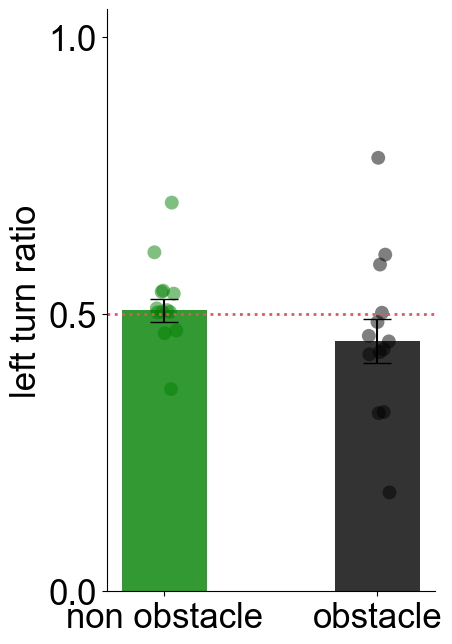

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

font = {'family': 'arial', 'size': 25}
plt.rc('font', **font)

# Create figure
fig, ax = plt.subplots(figsize=(5, 7))  # Wider figure to accommodate two bars

# Prepare data for both conditions
train_data = train_df
light_data = light_dark[light_dark.task =='oa']

# Function to calculate ratios and SE using average of individual animal ratios
def calculate_ratios(data):
    # Individual animal calculation
    animal_ratios = []
    for animal in data['animal'].unique():
        animal_data = data[data['animal'] == animal]
        a_total = len(animal_data)
        a_left = len(animal_data[animal_data['turn_direction_left_right'] == 'left']) if a_total > 0 else 0
        a_ratio = a_left / a_total if a_total > 0 else 0
        animal_ratios.append(a_ratio)
    
    # Calculate condition ratio as average of individual animal ratios
    ratio = np.median(animal_ratios) if animal_ratios else 0
    
    # Calculate standard error
    se = np.std(animal_ratios) / np.sqrt(len(animal_ratios)) if animal_ratios else 0
    
    return ratio, animal_ratios, se

# Calculate for both conditions
train_ratio, train_animal_ratios, train_se = calculate_ratios(train_data)
light_ratio, light_animal_ratios, light_se = calculate_ratios(light_data)

# Print the calculated values for verification
print("Training Condition:")
print(f"  Individual animal ratios: {train_animal_ratios}")
print(f"  Average (condition ratio): {train_ratio:.3f}")
print(f"  Standard Error: {train_se:.3f}")
print(f"  Number of animals: {len(train_animal_ratios)}")
print()
print("Light Condition:")
print(f"  Individual animal ratios: {light_animal_ratios}")
print(f"  Average (condition ratio): {light_ratio:.3f}")
print(f"  Standard Error: {light_se:.3f}")
print(f"  Number of animals: {len(light_animal_ratios)}")

# Plot settings
bar_width = 0.4
x_positions = [0, 1]  # Training at position 0, Light at position 1

# Plot 50% reference line (chance level for left/right turns)
ax.axhline(0.5, color='#e15759', linestyle=':', alpha=1, linewidth=2)

# Plot bars with error bars
# Training data (green)
ax.bar(x_positions[0], train_ratio, bar_width,
       color='green',
       edgecolor='none',
       alpha=0.8,
       yerr=train_se,
       capsize=10,
       label='Training')

# Light data (black)
ax.bar(x_positions[1], light_ratio, bar_width,
       color='black',
       edgecolor='none',
       alpha=0.8,
       yerr=light_se,
       capsize=10,
       label='Light')

# Plot individual data points with jitter
# Training points (green)
train_jitter = np.random.normal(0, 0.03, size=len(train_animal_ratios))
ax.scatter(x_positions[0] + train_jitter, train_animal_ratios,
           color='green', alpha=0.5, s=100, edgecolor='none')

# Light points (black)
light_jitter = np.random.normal(0, 0.03, size=len(light_animal_ratios))
ax.scatter(x_positions[1] + light_jitter, light_animal_ratios,
           color='black', alpha=0.5, s=100, edgecolor='none')

# Customize plot
ax.set_ylabel('left turn ratio')
ax.set_xticks(x_positions)
ax.set_xticklabels(['non obstacle', 'obstacle'])
ax.set_yticks([0, 0.5, 1.0])
ax.set_ylim(0, 1.05)  # Slightly above 1 for point visibility

# Remove unnecessary spines
ax.grid(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_visible(True)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)

# Add legend if desired
# ax.legend()

plt.tight_layout()
fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_one\left_ratio_combined_bar.pdf", dpi=300, transparent=True)
plt.show()

In [ ]:
data = G8CK1_df[(G8CK1_df.date_index==4)&(G8CK1_df.odd=='left')]
#thresh = data.time.mean()
#data = data[data.time<=thresh]



#array_list.append(array)
fig,ax = plt.subplots()
plot_arena(data,ax)
for ind, row in data.sample(20).iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    if row.turn_direction == 'up':
        ax.plot(x.astype(float),y.astype(float),color ='tab:red')
    else:
        ax.plot(x.astype(float),y.astype(float),color ='tab:blue')

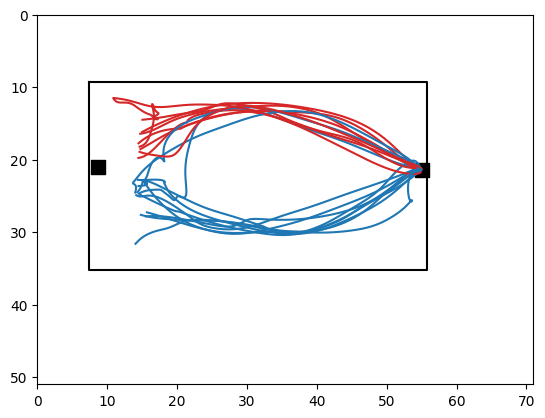

In [298]:
data = G8CK1_df[(G8CK1_df.date_index==4)&(G8CK1_df.odd=='left')]
#thresh = data.time.mean()
#data = data[data.time<=thresh]



#array_list.append(array)
fig,ax = plt.subplots()
plot_arena(data,ax)
for ind, row in data.sample(20).iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    if row.turn_direction == 'up':
        ax.plot(x.astype(float),y.astype(float),color ='tab:red')
    else:
        ax.plot(x.astype(float),y.astype(float),color ='tab:blue')

In [45]:
G8CK1_df.task

2713    oa
2714    oa
2715    oa
2716    oa
2717    oa
        ..
5387    oa
5388    oa
5389    oa
5390    oa
5391    oa
Name: task, Length: 2679, dtype: object

In [48]:
G8CK1_df[(G8CK1_df.odd=='left')&(G8CK1_df.time<=10)&(G8CK1_df.obstacle_cluster==3)&(G8CK1_df.task=='oadark')].date_index

11677    0.0
11679    0.0
11712    0.0
11714    0.0
11716    0.0
        ... 
14124    2.0
14126    2.0
14148    2.0
14150    2.0
14169    2.0
Name: date_index, Length: 139, dtype: float64

<AxesSubplot: >

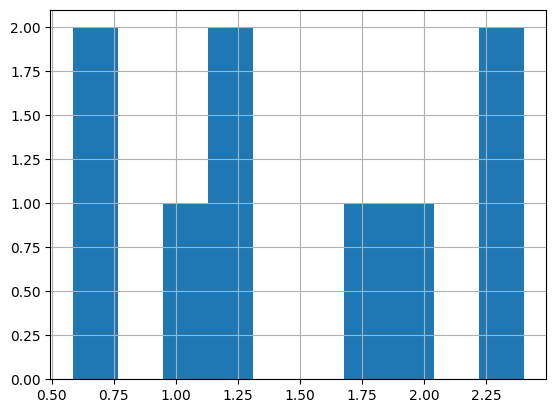

In [77]:
data.intial_lateral_error.hist()

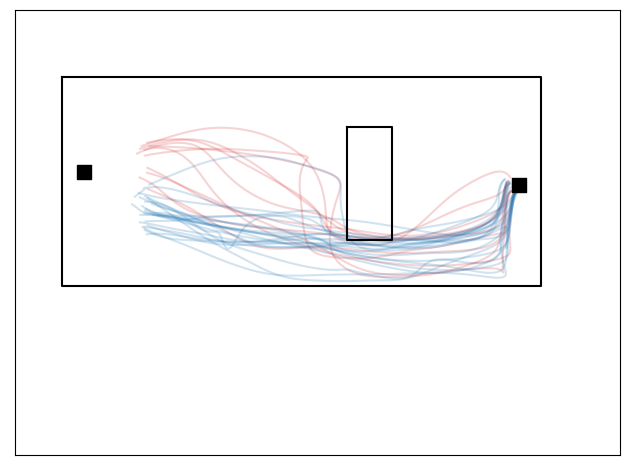

In [79]:
data = G8CK1_df[(G8CK1_df.odd=='left')&(G8CK1_df.time<=10)&(G8CK1_df.obstacle_cluster==3)&(G8CK1_df.task=='oadark')&(G8CK1_df.intial_lateral_error<=0)]
#thresh = data.time.mean()
#data = data[data.time<=thresh]

fig, ax = plt.subplots()
ax.set_xticks([])
ax.set_yticks([])
plot_arena(data, ax)
plot_orginal_obstacle(data,ax,3)

# Sample 10 trials from each turn direction
up_trials = data[data.turn_direction == 'up']
down_trials = data[data.turn_direction == 'down']

# Plot 'up' trials in red
for ind, row in up_trials.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float), 3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float), 3)
    ax.plot(x.astype(float), y.astype(float), color='tab:red', zorder=0,alpha =.2)

# Plot 'down' trials in blue
for ind, row in down_trials.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float), 3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float), 3)
    ax.plot(x.astype(float), y.astype(float), color='tab:blue', zorder=0,alpha =.2)
plt.tight_layout()

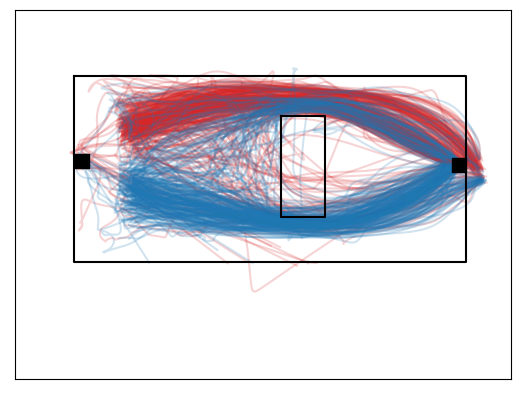

In [18]:
data = light_dark[(light_dark.odd=='left')&(light_dark.time<=10)&(light_dark.obstacle_cluster==3)&(light_dark.task=='oa')]
#thresh = data.time.mean()
#data = data[data.time<=thresh]

fig, ax = plt.subplots()
ax.set_xticks([])
ax.set_yticks([])
plot_arena(data, ax)
plot_orginal_obstacle(data,ax,3)

# Sample 10 trials from each turn direction
up_trials = data[data.turn_direction == 'up']
down_trials = data[data.turn_direction == 'down']

# Plot 'up' trials in red
for ind, row in up_trials.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float), 3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float), 3)
    ax.plot(x.astype(float), y.astype(float), color='tab:red', zorder=0,alpha =.2)

# Plot 'down' trials in blue
for ind, row in down_trials.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float), 3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float), 3)
    ax.plot(x.astype(float), y.astype(float), color='tab:blue', zorder=0,alpha =.2)

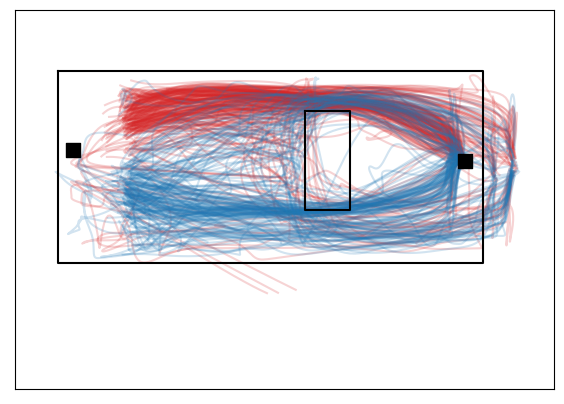

In [17]:
data = light_dark[(light_dark.odd=='left')&(light_dark.time<=10)&(light_dark.obstacle_cluster==3)&(light_dark.task=='oadark')]
#thresh = data.time.mean()
#data = data[data.time<=thresh]

fig, ax = plt.subplots()
ax.set_xticks([])
ax.set_yticks([])
plot_arena(data, ax)
plot_orginal_obstacle(data,ax,3)

# Sample 10 trials from each turn direction
up_trials = data[data.turn_direction == 'up']
down_trials = data[data.turn_direction == 'down']

# Plot 'up' trials in red
for ind, row in up_trials.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float), 3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float), 3)
    ax.plot(x.astype(float), y.astype(float), color='tab:red', zorder=0,alpha =.2)

# Plot 'down' trials in blue
for ind, row in down_trials.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float), 3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float), 3)
    ax.plot(x.astype(float), y.astype(float), color='tab:blue', zorder=0,alpha =.2)
plt.tight_layout()
#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final_v_4\middle_up_down_traces.pdf", dpi=300, transparent=True)

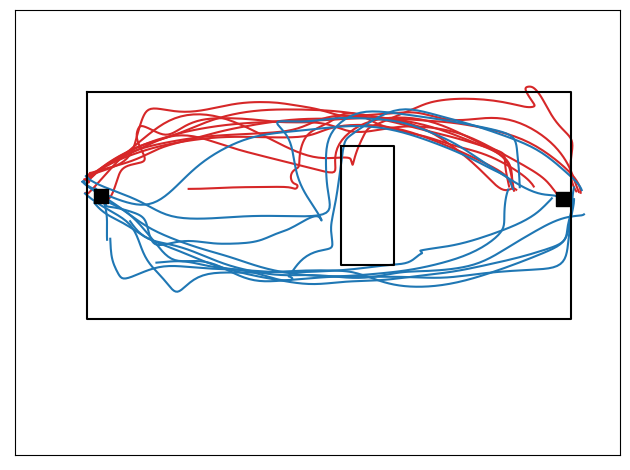

In [37]:
data = G8CK1_df[(G8CK1_df.date_index==0)&(G8CK1_df.odd=='left')&(G8CK1_df.obstacle_cluster==3)]
#thresh = data.time.mean()
#data = data[data.time<=thresh]

fig, ax = plt.subplots()
ax.set_xticks([])
ax.set_yticks([])
plot_arena(data, ax)
plot_orginal_obstacle(data,ax,3)

# Sample 10 trials from each turn direction
#up_trials = data[data.turn_direction == 'up'].sample(10)
#down_trials = data[data.turn_direction == 'down'].sample(10)

# Plot 'up' trials in red
for ind, row in up_trials.iterrows():
    x = gaussian_filter(row.nose_x_cm.astype(float), 3)
    y = gaussian_filter(row.nose_y_cm.astype(float), 3)
    ax.plot(x.astype(float), y.astype(float), color='tab:red', zorder=0)

# Plot 'down' trials in blue
for ind, row in down_trials.iterrows():
    x = gaussian_filter(row.nose_x_cm.astype(float), 3)
    y = gaussian_filter(row.nose_y_cm.astype(float), 3)
    ax.plot(x.astype(float), y.astype(float), color='tab:blue', zorder=0)
plt.tight_layout()
#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final_v_4\early_middle_up_down_traces.pdf", dpi=300, transparent=True)

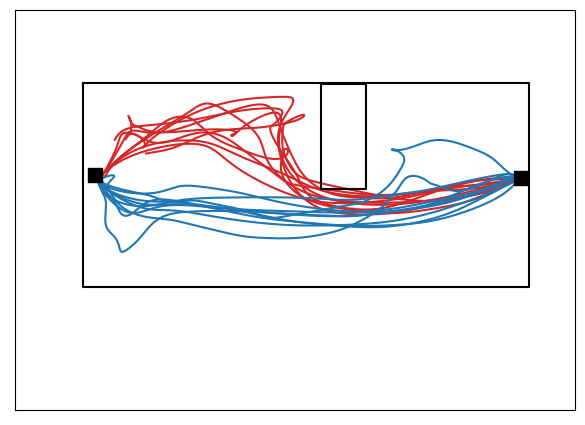

In [484]:
data = G8CK1_df[(G8CK1_df.date_index==4)&(G8CK1_df.odd=='left')&(G8CK1_df.time<=10)&(G8CK1_df.obstacle_cluster==1)]
#thresh = data.time.mean()
#data = data[data.time<=thresh]

fig, ax = plt.subplots()
ax.set_xticks([])
ax.set_yticks([])
plot_arena(data, ax)
plot_orginal_obstacle(data,ax,3)

# Sample 10 trials from each turn direction
up_trials = data[data.turn_to_obstacle == 'towards'].sample(10)
down_trials = data[data.turn_to_obstacle == 'away'].sample(10)

# Plot 'up' trials in red
for ind, row in up_trials.iterrows():
    x = gaussian_filter(row.nose_x_cm.astype(float), 3)
    y = gaussian_filter(row.nose_y_cm.astype(float), 3)
    ax.plot(x.astype(float), y.astype(float), color='tab:red', zorder=0)

# Plot 'down' trials in blue
for ind, row in down_trials.iterrows():
    x = gaussian_filter(row.nose_x_cm.astype(float), 3)
    y = gaussian_filter(row.nose_y_cm.astype(float), 3)
    ax.plot(x.astype(float), y.astype(float), color='tab:blue', zorder=0)
plt.tight_layout()

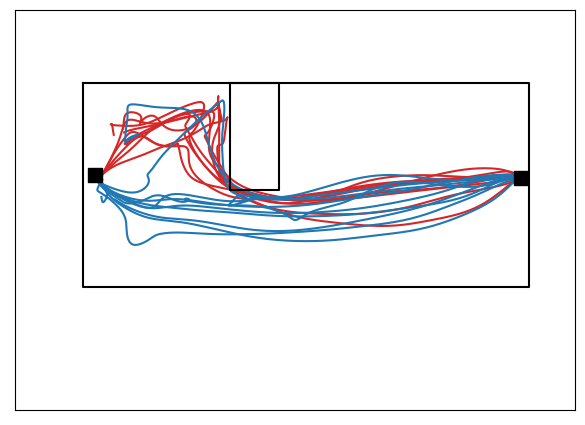

In [486]:
data = G8CK1_df[(G8CK1_df.date_index==4)&(G8CK1_df.odd=='left')&(G8CK1_df.time<=10)&(G8CK1_df.obstacle_cluster==0)]
#thresh = data.time.mean()
#data = data[data.time<=thresh]

fig, ax = plt.subplots()
ax.set_xticks([])
ax.set_yticks([])
plot_arena(data, ax)
plot_orginal_obstacle(data,ax,3)

# Sample 10 trials from each turn direction
up_trials = data[data.turn_to_obstacle == 'towards'].sample(10)
down_trials = data[data.turn_to_obstacle == 'away'].sample(10)

# Plot 'up' trials in red
for ind, row in up_trials.iterrows():
    x = gaussian_filter(row.nose_x_cm.astype(float), 3)
    y = gaussian_filter(row.nose_y_cm.astype(float), 3)
    ax.plot(x.astype(float), y.astype(float), color='tab:red', zorder=0)

# Plot 'down' trials in blue
for ind, row in down_trials.iterrows():
    x = gaussian_filter(row.nose_x_cm.astype(float), 3)
    y = gaussian_filter(row.nose_y_cm.astype(float), 3)
    ax.plot(x.astype(float), y.astype(float), color='tab:blue', zorder=0)
plt.tight_layout()


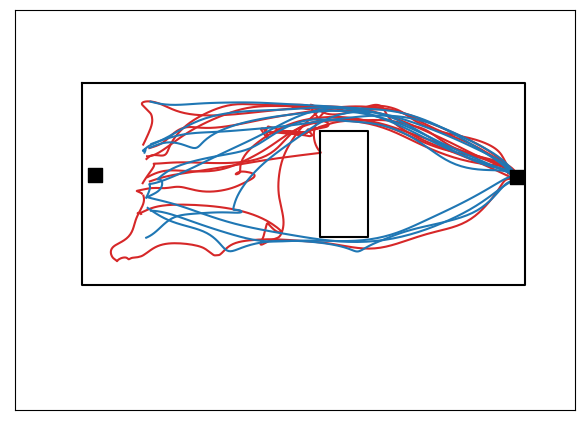

In [498]:
data = G8CK1_df[(G8CK1_df.odd=='left')&(G8CK1_df.time<=10)&(G8CK1_df.obstacle_cluster==3)]
#thresh = data.time.mean()
#data = data[data.time<=thresh]

fig, ax = plt.subplots()
ax.set_xticks([])
ax.set_yticks([])
plot_arena(data, ax)
plot_orginal_obstacle(data,ax,3)

# Sample 10 trials from each turn direction
up_trials = data[data.turn_to_obstacle == 'towards'].sample(10)
down_trials = data[data.turn_to_obstacle == 'away'].sample(10)

# Plot 'up' trials in red
for ind, row in up_trials.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float), 3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float), 3)
    ax.plot(x.astype(float), y.astype(float), color='tab:red', zorder=0)

# Plot 'down' trials in blue
for ind, row in down_trials.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float), 3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float), 3)
    ax.plot(x.astype(float), y.astype(float), color='tab:blue', zorder=0)
plt.tight_layout()

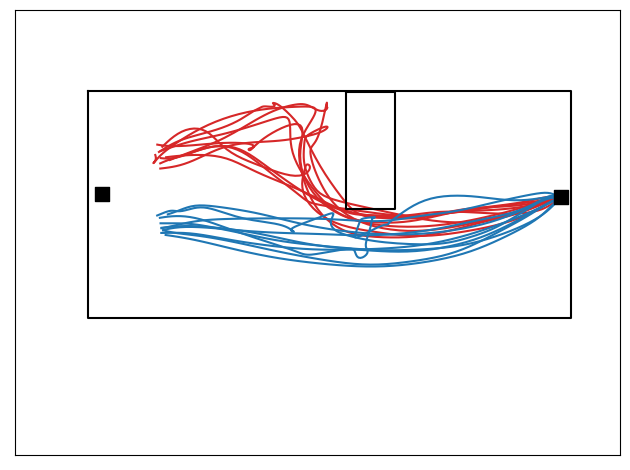

In [ ]:
data = G8CK1_df[(G8CK1_df.date_index==4)&(G8CK1_df.odd=='left')&(G8CK1_df.time<=10)&(G8CK1_df.obstacle_cluster==1)]
#thresh = data.time.mean()
#data = data[data.time<=thresh]

fig, ax = plt.subplots()
ax.set_xticks([])
ax.set_yticks([])
plot_arena(data, ax)
plot_orginal_obstacle(data,ax,3)

# Sample 10 trials from each turn direction
#up_trials = data[data.turn_direction == 'up'].sample(10)
#down_trials = data[data.turn_direction == 'down'].sample(10)

# Plot 'up' trials in red
for ind, row in up_trials.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float), 3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float), 3)
    ax.plot(x.astype(float), y.astype(float), color='tab:red', zorder=0)

# Plot 'down' trials in blue
for ind, row in down_trials.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float), 3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float), 3)
    ax.plot(x.astype(float), y.astype(float), color='tab:blue', zorder=0)
plt.tight_layout()
fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final_v_4\side_up_down_traces.pdf", dpi=300, transparent=True)

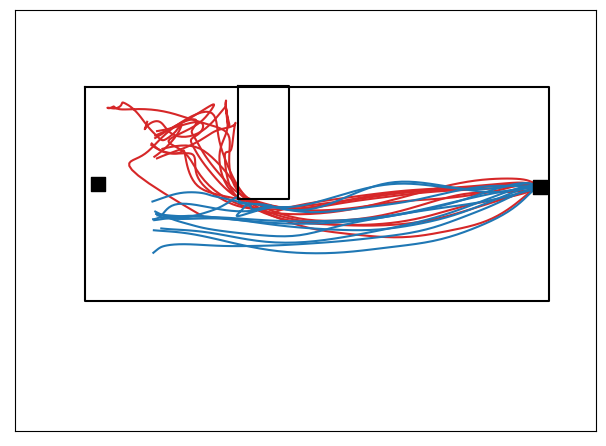

In [161]:
data = G8CK1_df[(G8CK1_df.date_index==4)&(G8CK1_df.odd=='left')&(G8CK1_df.time<=10)&(G8CK1_df.obstacle_cluster==0)]
#thresh = data.time.mean()
#data = data[data.time<=thresh]

fig, ax = plt.subplots()
ax.set_xticks([])
ax.set_yticks([])
plot_arena(data, ax)
plot_orginal_obstacle(data,ax,3)

# Sample 10 trials from each turn direction
#up_trials = data[data.turn_direction == 'up'].sample(10)
#down_trials = data[data.turn_direction == 'down'].sample(10)

# Plot 'up' trials in red
for ind, row in up_trials.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float), 3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float), 3)
    ax.plot(x.astype(float), y.astype(float), color='tab:red', zorder=0)

# Plot 'down' trials in blue
for ind, row in down_trials.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float), 3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float), 3)
    ax.plot(x.astype(float), y.astype(float), color='tab:blue', zorder=0)
plt.tight_layout()

fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final_v_4\short_side_up_down_traces.pdf", dpi=300, transparent=True)

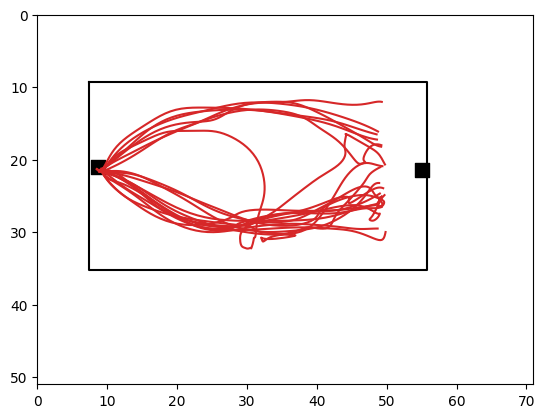

In [198]:
data = G8CK1_df[(G8CK1_df.date_index==4)&(G8CK1_df.odd=='right')]
#thresh = data.time.mean()
#data = data[data.time<=thresh]



#array_list.append(array)
fig,ax = plt.subplots()
plot_arena(data,ax)
for ind, row in data.sample(20).iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    if row.odd == 'right':
        ax.plot(x.astype(float),y.astype(float),color ='tab:red')
    else:
        ax.plot(x.astype(float),y.astype(float),color ='tab:blue')

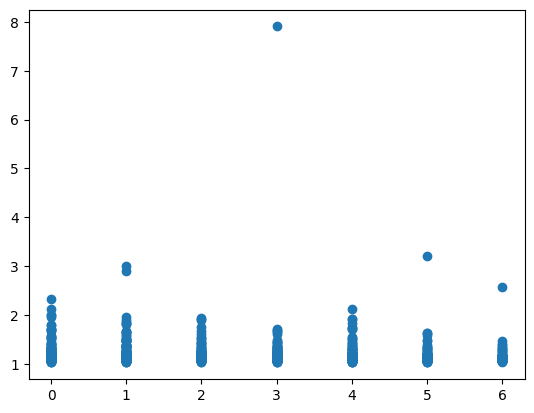

In [244]:
plt.scatter(G8CK1_df.date_index.to_numpy(),G8CK1_df.tortuosity.to_numpy())

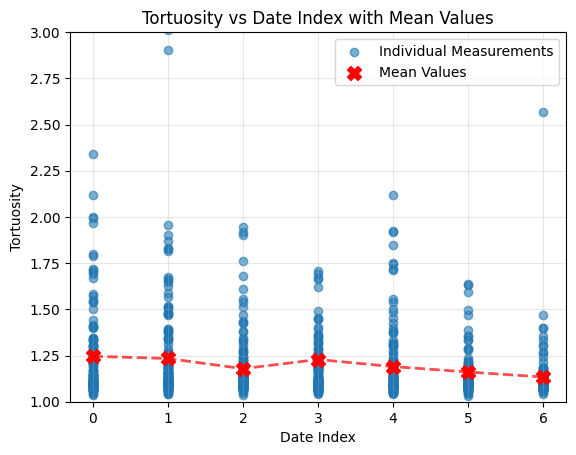

In [248]:
import matplotlib.pyplot as plt
import numpy as np

# Create the scatter plot
plt.scatter(G8CK1_df.date_index.to_numpy(), G8CK1_df.tortuosity.to_numpy(), alpha=0.6, label='Individual Measurements')

# Calculate mean tortuosity for each date index
mean_tortuosity = G8CK1_df.groupby('date_index')['tortuosity'].mean().reset_index()

# Plot the mean values
plt.scatter(mean_tortuosity.date_index, mean_tortuosity.tortuosity, 
            color='red', s=100, marker='X', label='Mean Values', zorder=5)

# Optional: Add connecting lines between mean points
plt.plot(mean_tortuosity.date_index, mean_tortuosity.tortuosity, 
         color='red', linestyle='--', alpha=0.7, linewidth=2)

# Add labels and legend
plt.xlabel('Date Index')
plt.ylabel('Tortuosity')
plt.title('Tortuosity vs Date Index with Mean Values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(1,3)
plt.show()

In [262]:
train_df.animal.unique()

array(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN', 'G8CK1RT',
       'G8CK1LT', 'G8CK1TT', 'G8CK1LN', 'J701LT', 'J701RT', 'J701NN',
       'J701RN'], dtype=object)

In [261]:
train_df[train_df.date_index == -5].animal.unique()

array(['G8CK1RT', 'G8CK1LT', 'G8CK1TT', 'G8CK1LN'], dtype=object)

<AxesSubplot: >

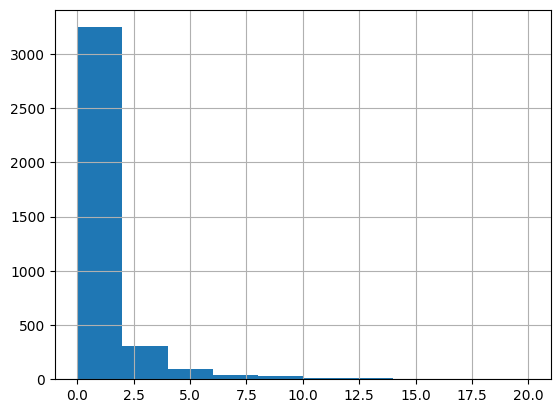

In [283]:
train_df.tortuosity.hist(range = (0,20))

<AxesSubplot: >

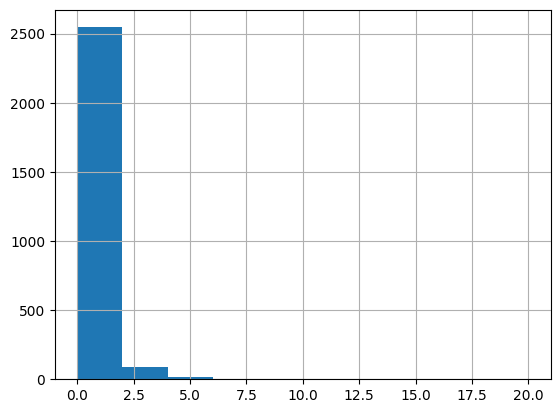

In [285]:
light_mid.tortuosity.hist(range = (0,20))

In [554]:
for ind,row in train_df.iterrows(): 
    dist = np.nansum(np.abs(np.diff(row['ts_nose_x_cm'])))
    train_df.at[ind,'dist'] = dist

In [ ]:
data.d

8881     66.500383
8882     43.777507
8883     44.351934
8884     48.614895
8885     48.759314
           ...    
14548    38.440072
14549    37.644910
14550    36.941249
14551    38.468411
14552    39.178780
Name: dist, Length: 5672, dtype: float64

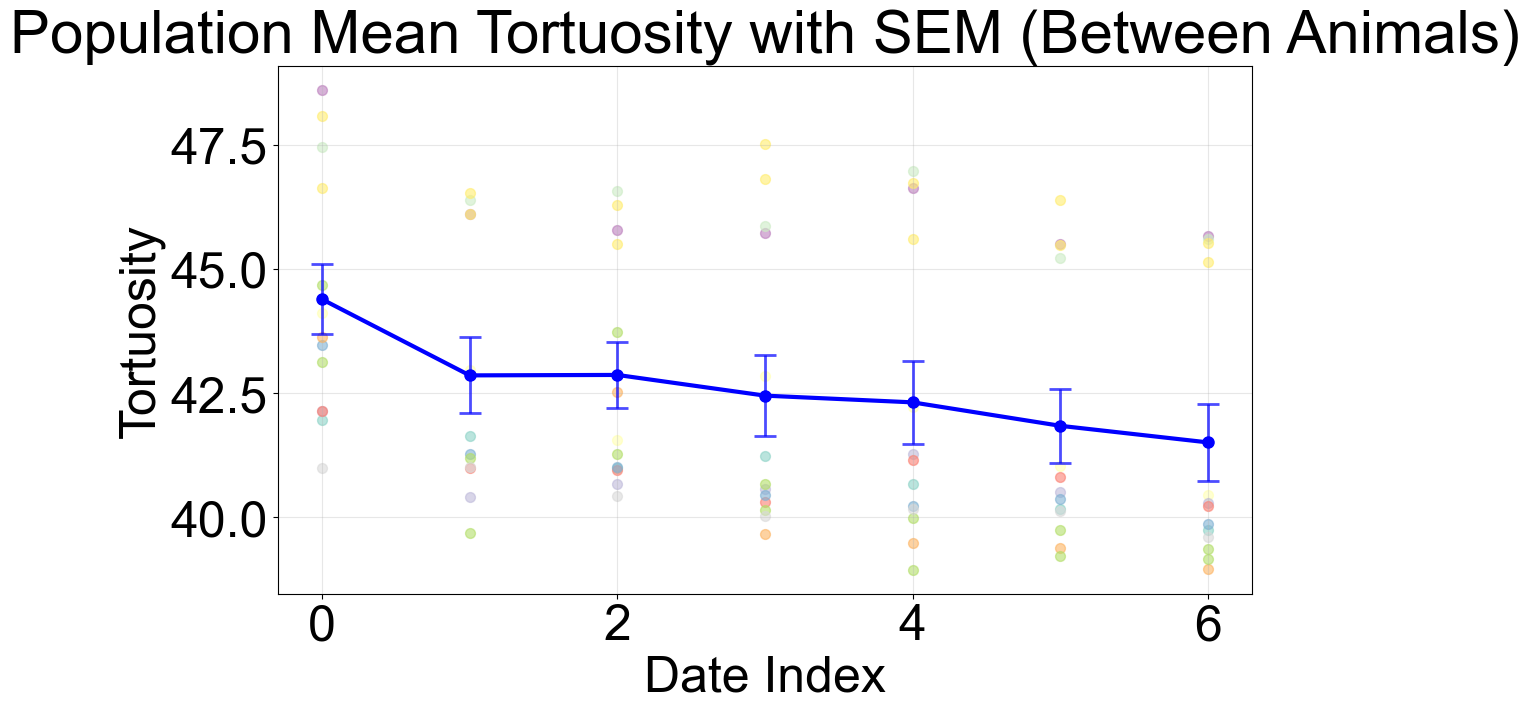

In [570]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# First calculate the mean tortuosity for each animal at each date index
data = light_dark[light_dark.tortuosity<=3]
data = data[data.task =='oa']
animal_means = data.groupby(['date_index', 'animal'])['dist'].mean().reset_index()

# Now calculate population mean and SEM across animals for each date index
population_stats = animal_means.groupby('date_index')['dist'].agg(['mean', 'sem']).reset_index()

# Create the plot
plt.figure(figsize=(12, 8))

# Plot population mean line
plt.plot(population_stats['date_index'], population_stats['mean'], 
         color='blue', marker='o', linewidth=3, markersize=8, 
         label='Population Mean', zorder=5)

# Plot SEM error bars (between animals)
plt.errorbar(population_stats['date_index'], population_stats['mean'], 
             yerr=population_stats['sem'], 
             color='blue', alpha=0.7, capsize=8, capthick=2, elinewidth=2,
             linestyle='None', label='SEM between animals', zorder=4)

## Optional: Add individual animal means as faint points
animals = animal_means['animal'].unique()
colors = plt.cm.Set3(np.linspace(0, 1, len(animals)))

for i, animal in enumerate(animals):
    animal_data = animal_means[animal_means['animal'] == animal]
    plt.scatter(animal_data['date_index'], animal_data['dist'], 
                color=colors[i], alpha=0.6, s=50, label=f'_nolegend_')

# Add labels and formatting
plt.xlabel('Date Index')
plt.ylabel('Tortuosity')
plt.title('Population Mean Tortuosity with SEM (Between Animals)')

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [571]:
data.dist.mean()

42.42203118558945

In [572]:
data.time.mean()

3.2078701568265684

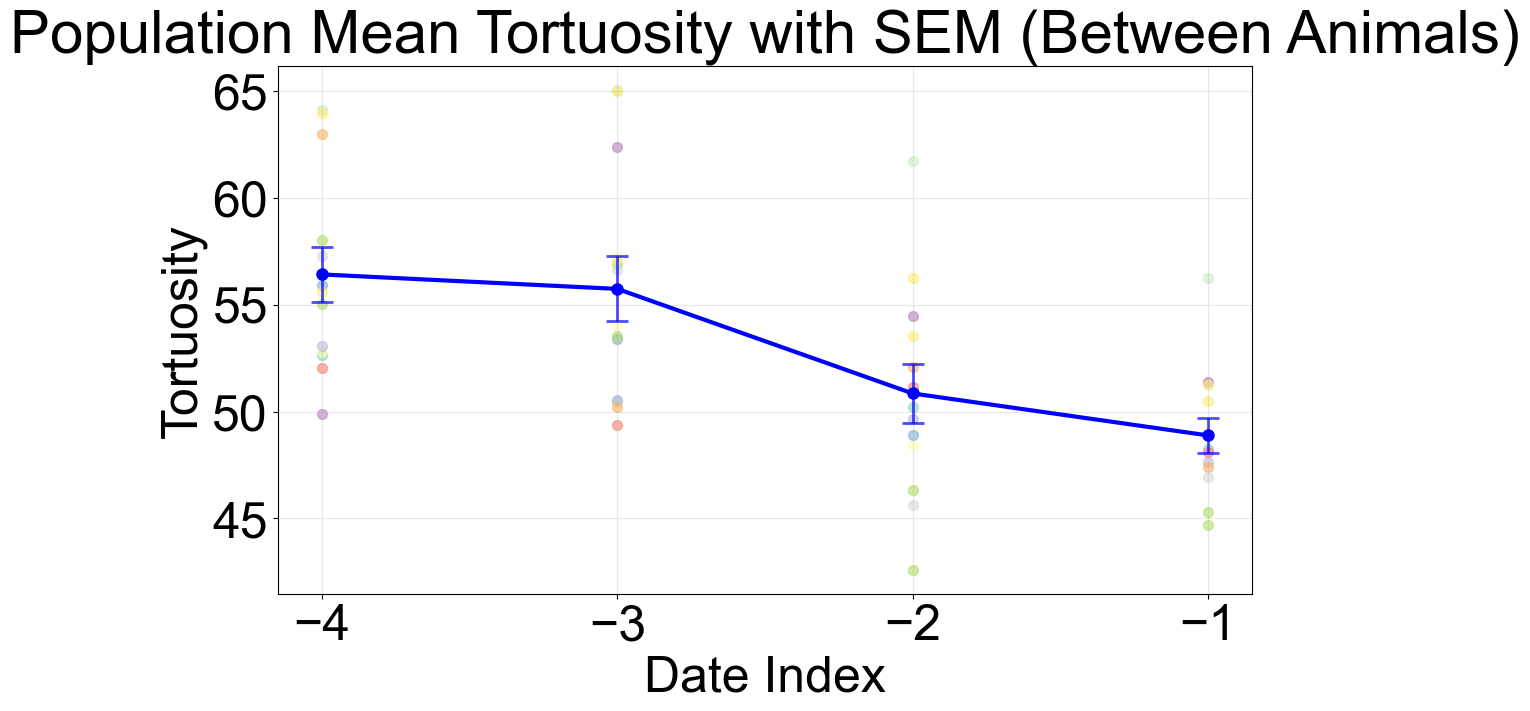

In [573]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# First calculate the mean tortuosity for each animal at each date index
data = train_df[train_df.tortuosity<=3]
animal_means = data.groupby(['date_index', 'animal'])['dist'].mean().reset_index()

# Now calculate population mean and SEM across animals for each date index
population_stats = animal_means.groupby('date_index')['dist'].agg(['mean', 'sem']).reset_index()

# Create the plot
plt.figure(figsize=(12, 8))

# Plot population mean line
plt.plot(population_stats['date_index'], population_stats['mean'], 
         color='blue', marker='o', linewidth=3, markersize=8, 
         label='Population Mean', zorder=5)

# Plot SEM error bars (between animals)
plt.errorbar(population_stats['date_index'], population_stats['mean'], 
             yerr=population_stats['sem'], 
             color='blue', alpha=0.7, capsize=8, capthick=2, elinewidth=2,
             linestyle='None', label='SEM between animals', zorder=4)

## Optional: Add individual animal means as faint points
animals = animal_means['animal'].unique()
colors = plt.cm.Set3(np.linspace(0, 1, len(animals)))

for i, animal in enumerate(animals):
    animal_data = animal_means[animal_means['animal'] == animal]
    plt.scatter(animal_data['date_index'], animal_data['dist'], 
                color=colors[i], alpha=0.6, s=50, label=f'_nolegend_')

# Add labels and formatting
plt.xlabel('Date Index')
plt.ylabel('Tortuosity')
plt.title('Population Mean Tortuosity with SEM (Between Animals)')
#plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [568]:
data.dist.mean()

50.77247027114067

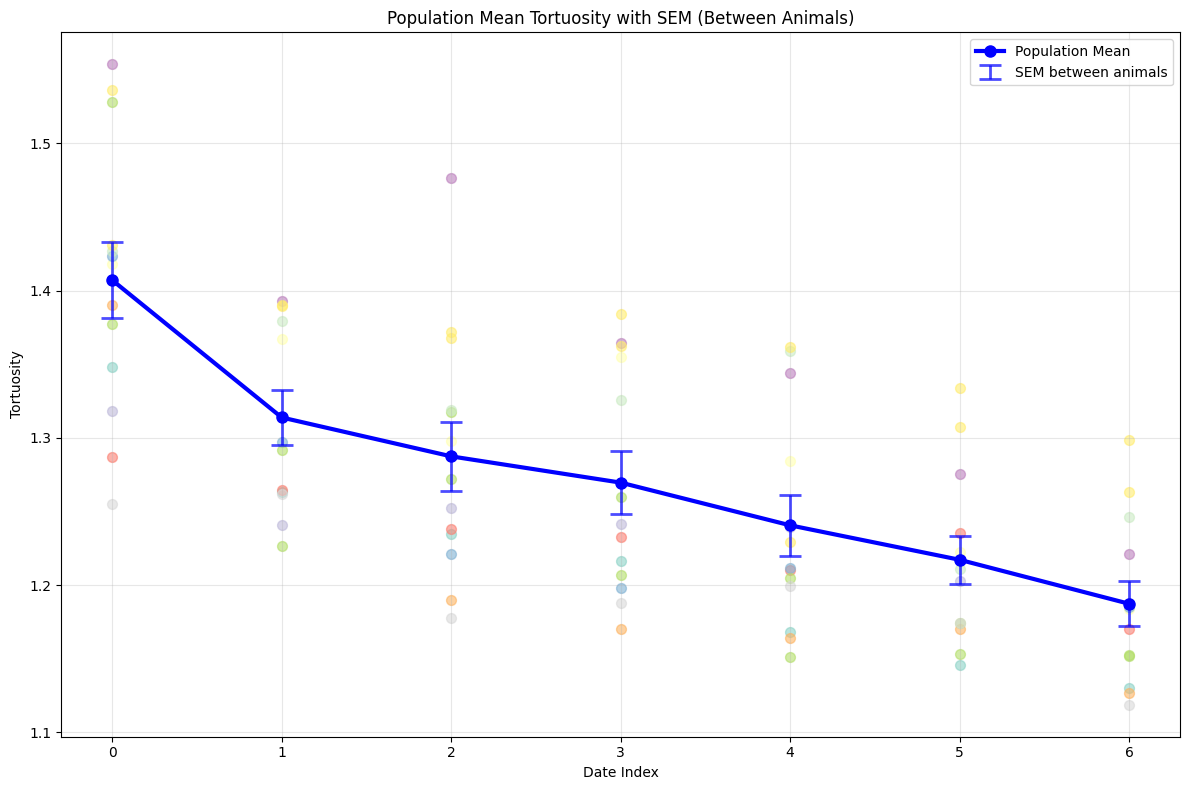

In [130]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# First calculate the mean tortuosity for each animal at each date index
data = light_dark[light_dark.task == 'oa']
data = data[data.tortuosity<=4]
animal_means = data.groupby(['date_index', 'animal'])['tortuosity'].mean().reset_index()

# Now calculate population mean and SEM across animals for each date index
population_stats = animal_means.groupby('date_index')['tortuosity'].agg(['mean', 'sem']).reset_index()

# Create the plot
plt.figure(figsize=(12, 8))

# Plot population mean line
plt.plot(population_stats['date_index'], population_stats['mean'], 
         color='blue', marker='o', linewidth=3, markersize=8, 
         label='Population Mean', zorder=5)

# Plot SEM error bars (between animals)
plt.errorbar(population_stats['date_index'], population_stats['mean'], 
             yerr=population_stats['sem'], 
             color='blue', alpha=0.7, capsize=8, capthick=2, elinewidth=2,
             linestyle='None', label='SEM between animals', zorder=4)

## Optional: Add individual animal means as faint points
animals = animal_means['animal'].unique()
colors = plt.cm.Set3(np.linspace(0, 1, len(animals)))

for i, animal in enumerate(animals):
    animal_data = animal_means[animal_means['animal'] == animal]
    plt.scatter(animal_data['date_index'], animal_data['tortuosity'], 
                color=colors[i], alpha=0.6, s=50, label=f'_nolegend_')

# Add labels and formatting
plt.xlabel('Date Index')
plt.ylabel('Tortuosity')
plt.title('Population Mean Tortuosity with SEM (Between Animals)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [465]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create the plot
plt.rcParams['font.weight'] = 'normal'
plt.rcParams['font'] = 'arial'
plt.figure(figsize=(7, 6))

# Process train_df data
train_data = train_df[train_df.tortuosity <= 3]
train_animal_means = train_data.groupby(['date_index', 'animal'])['tortuosity'].mean().reset_index()
train_population_stats = train_animal_means.groupby('date_index')['tortuosity'].agg(['mean', 'sem']).reset_index()

# Process light_dark data
light_data = light_dark[light_dark.task == 'oa']
light_data = light_data[light_data.tortuosity <= 4]
light_animal_means = light_data.groupby(['date_index', 'animal'])['tortuosity'].mean().reset_index()
light_population_stats = light_animal_means.groupby('date_index')['tortuosity'].agg(['mean', 'sem']).reset_index()

# Create aligned x-axis values
# For train_df: -4, -3, -2, -1 → we want to shift so -4 becomes 0
# For light_dark: 0, 1, 2, 3, 4, 5, 6 → already starts at 0

# Shift train data so -4 becomes 0, -3 becomes 1, etc.
train_population_stats['aligned_date'] = train_population_stats['date_index'] + 4
light_population_stats['aligned_date'] = light_population_stats['date_index']

# Also shift the individual animal means
train_animal_means['aligned_date'] = train_animal_means['date_index'] + 4
light_animal_means['aligned_date'] = light_animal_means['date_index']

# Plot train data (shifted)
plt.plot(train_population_stats['aligned_date'], train_population_stats['mean'], 
         color='green', marker='s', linewidth=3, markersize=8, 
         label='Training Population Mean', zorder=5)

plt.errorbar(train_population_stats['aligned_date'], train_population_stats['mean'], 
             yerr=train_population_stats['sem'], 
             color='green', alpha=0.7, capsize=8, capthick=2, elinewidth=2,
             linestyle='None', label='Training SEM', zorder=4)

# Plot light/dark data
plt.plot(light_population_stats['aligned_date'], light_population_stats['mean'], 
         color='black', marker='o', linewidth=3, markersize=8, 
         label='Light/Dark Population Mean', zorder=5)

plt.errorbar(light_population_stats['aligned_date'], light_population_stats['mean'], 
             yerr=light_population_stats['sem'], 
             color='black', alpha=0.7, capsize=8, capthick=2, elinewidth=2,
             linestyle='None', label='Light/Dark SEM', zorder=4)

# Add individual animal means as faint points
train_animals = train_animal_means['animal'].unique()
light_animals = light_animal_means['animal'].unique()

# Plot training individual animals
for animal in train_animals:
    animal_data = train_animal_means[train_animal_means['animal'] == animal]
    plt.scatter(animal_data['aligned_date'], animal_data['tortuosity'], 
                color='green', alpha=0.3, s=40, label='_nolegend_')

# Plot light/dark individual animals
for animal in light_animals:
    animal_data = light_animal_means[light_animal_means['animal'] == animal]
    plt.scatter(animal_data['aligned_date'], animal_data['tortuosity'], 
                color='black', alpha=0.3, s=40, label='_nolegend_')

# Add labels and formatting
plt.xlabel('days')
plt.ylabel('tortuosity')


# Set x-axis ticks to show both original and aligned values if needed
plt.xticks(range(0, 7))  # Adjust based on your data range


plt.yticks([1,1.5,2])

plt.tight_layout()


plt.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final_v_4\mean_tortuosity_train_task.pdf", dpi=300, transparent=True)
plt.show()


KeyError: 'font is not a valid rc parameter (see rcParams.keys() for a list of valid parameters)'

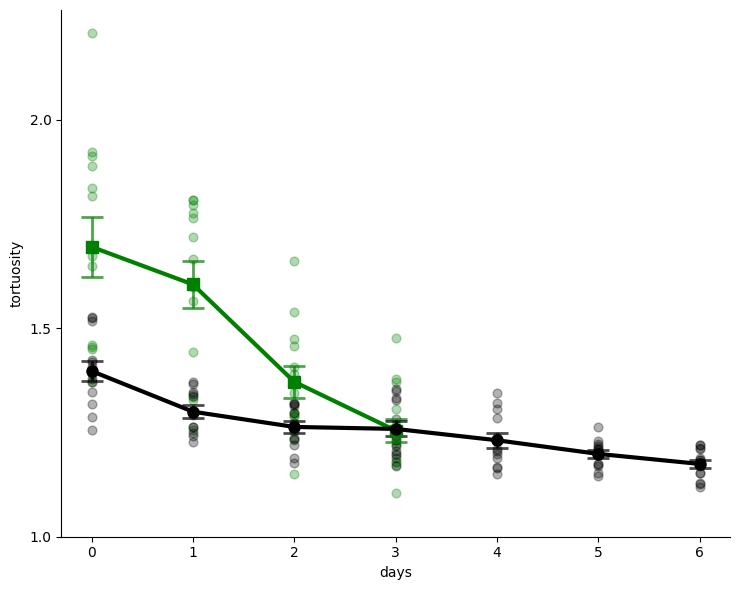

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create the plot with subplots and remove top/left axes
fig, ax = plt.subplots(figsize=(7.5, 6))

# Process train_df data
train_data = train_df[train_df.tortuosity <= 3]
train_animal_means = train_data.groupby(['date_index', 'animal'])['tortuosity'].mean().reset_index()
train_population_stats = train_animal_means.groupby('date_index')['tortuosity'].agg(['mean', 'sem']).reset_index()

# Process light_dark data
light_data = light_dark[light_dark.task == 'oa']
light_data = light_data[light_data.tortuosity <= 3]
#light_data = light_data[~light_data['animal'].isin(['J701LT', 'J701RT', 'J701NN','J701RN'])] 
light_animal_means = light_data.groupby(['date_index', 'animal'])['tortuosity'].mean().reset_index()
light_population_stats = light_animal_means.groupby('date_index')['tortuosity'].agg(['mean', 'sem']).reset_index()

# Create aligned x-axis values
# For train_df: -4, -3, -2, -1 → we want to shift so -4 becomes 0
# For light_dark: 0, 1, 2, 3, 4, 5, 6 → already starts at 0

# Shift train data so -4 becomes 0, -3 becomes 1, etc.
train_population_stats['aligned_date'] = train_population_stats['date_index'] + 4
light_population_stats['aligned_date'] = light_population_stats['date_index']

# Also shift the individual animal means
train_animal_means['aligned_date'] = train_animal_means['date_index'] + 4
light_animal_means['aligned_date'] = light_animal_means['date_index']

# Plot train data (shifted)
ax.plot(train_population_stats['aligned_date'], train_population_stats['mean'], 
         color='green', marker='s', linewidth=3, markersize=8, 
         label='Training Population Mean', zorder=5)

ax.errorbar(train_population_stats['aligned_date'], train_population_stats['mean'], 
             yerr=train_population_stats['sem'], 
             color='green', alpha=0.7, capsize=8, capthick=2, elinewidth=2,
             linestyle='None', label='Training SEM', zorder=4)

# Plot light/dark data
ax.plot(light_population_stats['aligned_date'], light_population_stats['mean'], 
         color='black', marker='o', linewidth=3, markersize=8, 
         label='Light/Dark Population Mean', zorder=5)

ax.errorbar(light_population_stats['aligned_date'], light_population_stats['mean'], 
             yerr=light_population_stats['sem'], 
             color='black', alpha=0.7, capsize=8, capthick=2, elinewidth=2,
             linestyle='None', label='Light/Dark SEM', zorder=4)

# Add individual animal means as faint points
train_animals = train_animal_means['animal'].unique()
light_animals = light_animal_means['animal'].unique()

# Plot training individual animals
for animal in train_animals:
    animal_data = train_animal_means[train_animal_means['animal'] == animal]
    ax.scatter(animal_data['aligned_date'], animal_data['tortuosity'], 
                color='green', alpha=0.3, s=40, label='_nolegend_')

# Plot light/dark individual animals
for animal in light_animals:
    animal_data = light_animal_means[light_animal_means['animal'] == animal]
    ax.scatter(animal_data['aligned_date'], animal_data['tortuosity'], 
                color='black', alpha=0.3, s=40, label='_nolegend_')

# Add labels and formatting
ax.set_xlabel('days')
ax.set_ylabel('tortuosity')

# Set x-axis ticks
ax.set_xticks(range(0, 7))
ax.set_yticks([1, 1.5, 2])

# Remove top and right axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Optional: Also remove left axis if you want (though you typically keep left for y-axis)
# ax.spines['left'].set_visible(False)

plt.tight_layout()

#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final_v_4\mean_tortuosity_train_task.pdf", 
            #dpi=300, transparent=True)
plt.show()

meta NOT subset; don't know how to subset; dropped


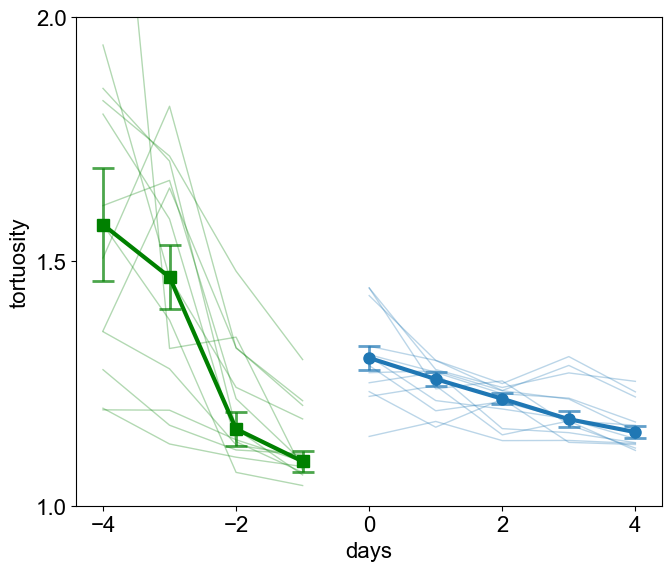

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create the plot with subplots and remove top/left axes
fig, ax = plt.subplots(figsize=(7, 6))

# Set font size to 12
plt.rcParams.update({'font.size': 16})

# Process train_df data
#train_data = train_df[train_df.tortuosity <= 3]
train_animal_medians = train_data.groupby(['date_index', 'animal'])['tortuosity'].median().reset_index()
train_population_stats = train_animal_medians.groupby('date_index')['tortuosity'].agg(['median', 'sem']).reset_index()

# Process light_dark data
light_data = light_dark[light_dark.task == 'oa']
#light_data = light_data[light_data.tortuosity <= 3]
#light_data = light_data[~light_data['animal'].isin(['J701LT', 'J701RT', 'J701NN','J701RN'])] 
light_animal_medians = light_data.groupby(['date_index', 'animal'])['tortuosity'].median().reset_index()
light_population_stats = light_animal_medians.groupby('date_index')['tortuosity'].agg(['median', 'sem']).reset_index()

# Filter train data to only include date_index from -4 to 2
train_population_stats = train_population_stats[train_population_stats['date_index'].between(-4, 2)]
train_animal_medians = train_animal_medians[train_animal_medians['date_index'].between(-4, 2)]

# Filter light/dark data to include date_index from -4 to 4 (adding date_index 4)
light_population_stats = light_population_stats[light_population_stats['date_index'].between(-4, 4)]
light_animal_medians = light_animal_medians[light_animal_medians['date_index'].between(-4, 4)]

# Recalculate SEM based on individual animal medians for both datasets
train_sem_by_animal = train_animal_medians.groupby('date_index')['tortuosity'].sem().reset_index()
train_sem_by_animal.columns = ['date_index', 'sem_animal']

light_sem_by_animal = light_animal_medians.groupby('date_index')['tortuosity'].sem().reset_index()
light_sem_by_animal.columns = ['date_index', 'sem_animal']

# Merge the recalculated SEM back to population stats
train_population_stats = train_population_stats.merge(train_sem_by_animal, on='date_index')
light_population_stats = light_population_stats.merge(light_sem_by_animal, on='date_index')

# Plot train data (using original date_index)
ax.plot(train_population_stats['date_index'], train_population_stats['median'], 
         color='green', marker='s', linewidth=3, markersize=8, 
         label='Training Population Mean', zorder=5)

ax.errorbar(train_population_stats['date_index'], train_population_stats['median'], 
             yerr=train_population_stats['sem_animal'], 
             color='green', alpha=0.7, capsize=8, capthick=2, elinewidth=2,
             linestyle='None', label='Training SEM', zorder=4)

# Plot light/dark data (using original date_index)
ax.plot(light_population_stats['date_index'], light_population_stats['median'], 
         color='tab:blue', marker='o', linewidth=3, markersize=8, 
         label='Light/Dark Population Mean', zorder=5)

ax.errorbar(light_population_stats['date_index'], light_population_stats['median'], 
             yerr=light_population_stats['sem_animal'], 
             color='tab:blue', alpha=0.7, capsize=8, capthick=2, elinewidth=2,
             linestyle='None', label='Light/Dark SEM', zorder=4)

# Plot individual animal traces with lines
train_animals = train_animal_medians['animal'].unique()
light_animals = light_animal_medians['animal'].unique()

# Plot training individual animal traces
for animal in train_animals:
    animal_data = train_animal_medians[train_animal_medians['animal'] == animal].sort_values('date_index')
    ax.plot(animal_data['date_index'], animal_data['tortuosity'], 
             color='green', alpha=0.3, linewidth=1,
             label='_nolegend_', zorder=1)

# Plot light/dark individual animal traces
for animal in light_animals:
    animal_data = light_animal_medians[light_animal_medians['animal'] == animal].sort_values('date_index')
    ax.plot(animal_data['date_index'], animal_data['tortuosity'], 
             color='tab:blue', alpha=0.3, linewidth=1, 
             label='_nolegend_', zorder=1)

# Add labels and formatting
ax.set_xlabel('days', fontsize=16)
ax.set_ylabel('tortuosity', fontsize=16)

# Set x-axis ticks from -4 to 4 (to accommodate the extended OA data)
ax.set_xticks([-4,-2,0,2,4])
ax.set_yticks([1, 1.5, 2])
ax.set_ylim(1, 2)



plt.tight_layout()

#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_one\median_tortuosity_train_task_lines.pdf", 
#            dpi=300, transparent=True)
plt.show()

Training animals with complete data: 13
Light/Dark animals with complete data: 0


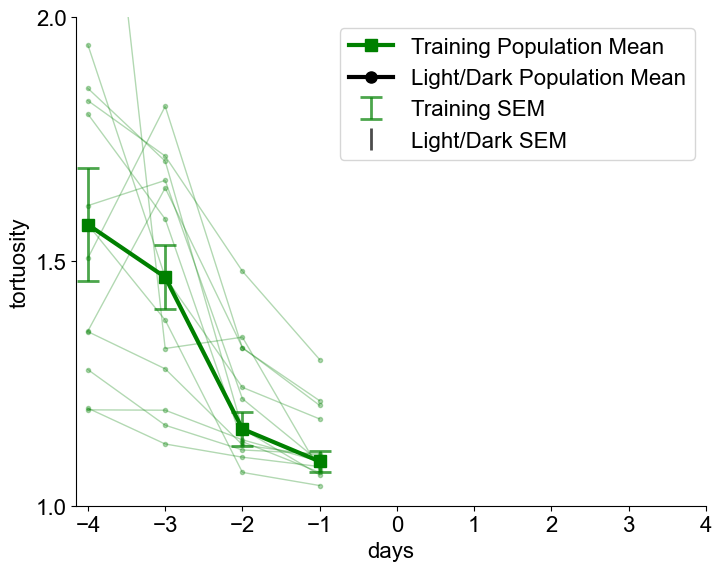

In [60]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create the plot with subplots and remove top/left axes
fig, ax = plt.subplots(figsize=(7.5, 6))

# Set font size to 12
plt.rcParams.update({'font.size': 16})

# Process train_df data
#train_data = train_df[train_df.tortuosity <= 3]
train_animal_medians = train_data.groupby(['date_index', 'animal'])['tortuosity'].median().reset_index()
train_population_stats = train_animal_medians.groupby('date_index')['tortuosity'].agg(['median', 'sem']).reset_index()

# Process light_dark data
light_data = light_dark[light_dark.task == 'oa']
#light_data = light_data[light_data.tortuosity <= 3]
#light_data = light_data[~light_data['animal'].isin(['J701LT', 'J701RT', 'J701NN','J701RN'])] 
light_animal_medians = light_data.groupby(['date_index', 'animal'])['tortuosity'].median().reset_index()
light_population_stats = light_animal_medians.groupby('date_index')['tortuosity'].agg(['median', 'sem']).reset_index()

# Filter train data to only include date_index from -4 to 2
train_date_range = range(-4, 0)  # -4 to 2 inclusive
train_population_stats = train_population_stats[train_population_stats['date_index'].between(-4, 2)]
train_animal_medians = train_animal_medians[train_animal_medians['date_index'].between(-4, 2)]

# Filter light/dark data to include date_index from -4 to 4
light_date_range = range(0, 4)  # -4 to 4 inclusive
light_population_stats = light_population_stats[light_population_stats['date_index'].between(-4, 4)]
light_animal_medians = light_animal_medians[light_animal_medians['date_index'].between(-4, 4)]

# Find animals with complete data for training
train_animals_complete = []
for animal in train_animal_medians['animal'].unique():
    animal_data = train_animal_medians[train_animal_medians['animal'] == animal]
    animal_dates = sorted(animal_data['date_index'].unique())
    if set(animal_dates) == set(train_date_range):
        train_animals_complete.append(animal)

# Find animals with complete data for light/dark
light_animals_complete = []
for animal in light_animal_medians['animal'].unique():
    animal_data = light_animal_medians[light_animal_medians['animal'] == animal]
    animal_dates = sorted(animal_data['date_index'].unique())
    if set(animal_dates) == set(light_date_range):
        light_animals_complete.append(animal)

print(f"Training animals with complete data: {len(train_animals_complete)}")
print(f"Light/Dark animals with complete data: {len(light_animals_complete)}")

# Filter to only include animals with complete data
train_animal_medians_complete = train_animal_medians[train_animal_medians['animal'].isin(train_animals_complete)]
light_animal_medians_complete = light_animal_medians[light_animal_medians['animal'].isin(light_animals_complete)]

# Recalculate population stats using only complete animals
train_population_stats_complete = train_animal_medians_complete.groupby('date_index')['tortuosity'].agg(['median', 'sem']).reset_index()
light_population_stats_complete = light_animal_medians_complete.groupby('date_index')['tortuosity'].agg(['median', 'sem']).reset_index()

# Recalculate SEM based on individual animal medians for both datasets
train_sem_by_animal = train_animal_medians_complete.groupby('date_index')['tortuosity'].sem().reset_index()
train_sem_by_animal.columns = ['date_index', 'sem_animal']

light_sem_by_animal = light_animal_medians_complete.groupby('date_index')['tortuosity'].sem().reset_index()
light_sem_by_animal.columns = ['date_index', 'sem_animal']

# Merge the recalculated SEM back to population stats
train_population_stats_complete = train_population_stats_complete.merge(train_sem_by_animal, on='date_index')
light_population_stats_complete = light_population_stats_complete.merge(light_sem_by_animal, on='date_index')

# Plot train data (using original date_index)
ax.plot(train_population_stats_complete['date_index'], train_population_stats_complete['median'], 
         color='green', marker='s', linewidth=3, markersize=8, 
         label='Training Population Mean', zorder=5)

ax.errorbar(train_population_stats_complete['date_index'], train_population_stats_complete['median'], 
             yerr=train_population_stats_complete['sem_animal'], 
             color='green', alpha=0.7, capsize=8, capthick=2, elinewidth=2,
             linestyle='None', label='Training SEM', zorder=4)

# Plot light/dark data (using original date_index)
ax.plot(light_population_stats_complete['date_index'], light_population_stats_complete['median'], 
         color='black', marker='o', linewidth=3, markersize=8, 
         label='Light/Dark Population Mean', zorder=5)

ax.errorbar(light_population_stats_complete['date_index'], light_population_stats_complete['median'], 
             yerr=light_population_stats_complete['sem_animal'], 
             color='black', alpha=0.7, capsize=8, capthick=2, elinewidth=2,
             linestyle='None', label='Light/Dark SEM', zorder=4)

# Plot individual animal traces with lines (only complete animals)
# Plot training individual animal traces
for animal in train_animals_complete:
    animal_data = train_animal_medians_complete[train_animal_medians_complete['animal'] == animal].sort_values('date_index')
    ax.plot(animal_data['date_index'], animal_data['tortuosity'], 
             color='green', alpha=0.3, linewidth=1, marker='o', markersize=3, 
             label='_nolegend_', zorder=1)

# Plot light/dark individual animal traces
for animal in light_animals_complete:
    animal_data = light_animal_medians_complete[light_animal_medians_complete['animal'] == animal].sort_values('date_index')
    ax.plot(animal_data['date_index'], animal_data['tortuosity'], 
             color='black', alpha=0.3, linewidth=1, marker='o', markersize=3, 
             label='_nolegend_', zorder=1)

# Add labels and formatting
ax.set_xlabel('days', fontsize=16)
ax.set_ylabel('tortuosity', fontsize=16)

# Set x-axis ticks from -4 to 4 (to accommodate the extended OA data)
ax.set_xticks(range(-4, 5))
ax.set_yticks([1, 1.5, 2])
ax.set_ylim(1, 2)

# Remove top and right axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend
ax.legend()

plt.tight_layout()

#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final_v_4\median_tortuosity_train_task_1.pdf", 
            #dpi=300, transparent=True)
plt.show()

In [54]:
light_animal_medians.date_index.to_numpy().shape

(64,)

In [52]:
light_animal_medians.date_index.to_numpy()

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
       4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.])

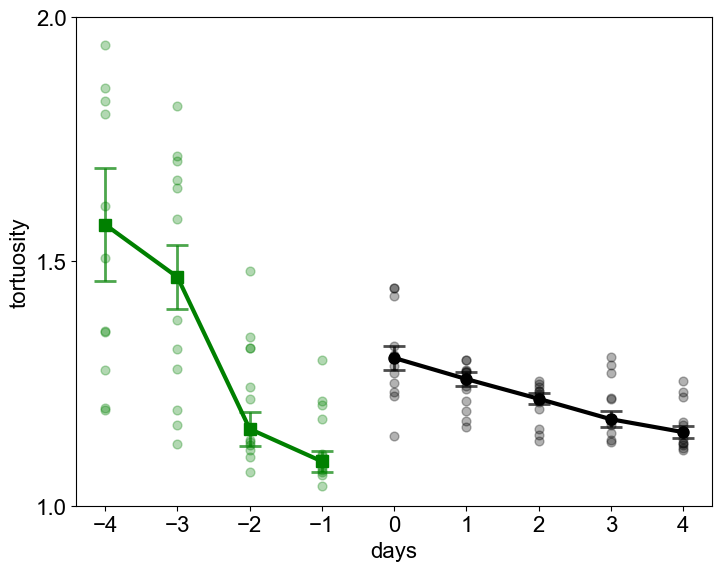

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create the plot with subplots and remove top/left axes
fig, ax = plt.subplots(figsize=(7.5, 6))

# Set font size to 12
plt.rcParams.update({'font.size': 16})

# Process train_df data
#train_data = train_df[train_df.tortuosity <= 3]
train_animal_medians = train_data.groupby(['date_index', 'animal'])['tortuosity'].median().reset_index()
train_population_stats = train_animal_medians.groupby('date_index')['tortuosity'].agg(['median', 'sem']).reset_index()

# Process light_dark data
light_data = light_dark[light_dark.task == 'oa']
#light_data = light_data[light_data.tortuosity <= 3]
#light_data = light_data[~light_data['animal'].isin(['J701LT', 'J701RT', 'J701NN','J701RN'])] 
light_animal_medians = light_data.groupby(['date_index', 'animal'])['tortuosity'].median().reset_index()
light_population_stats = light_animal_medians.groupby('date_index')['tortuosity'].agg(['median', 'sem']).reset_index()

# Filter train data to only include date_index from -4 to 2
train_population_stats = train_population_stats[train_population_stats['date_index'].between(-4, 2)]
train_animal_medians = train_animal_medians[train_animal_medians['date_index'].between(-4, 2)]

# Filter light/dark data to include date_index from -4 to 4 (adding date_index 4)
light_population_stats = light_population_stats[light_population_stats['date_index'].between(-4, 4)]
light_animal_medians = light_animal_medians[light_animal_medians['date_index'].between(-4, 4)]

# Recalculate SEM based on individual animal medians for both datasets
train_sem_by_animal = train_animal_medians.groupby('date_index')['tortuosity'].sem().reset_index()
train_sem_by_animal.columns = ['date_index', 'sem_animal']

light_sem_by_animal = light_animal_medians.groupby('date_index')['tortuosity'].sem().reset_index()
light_sem_by_animal.columns = ['date_index', 'sem_animal']

# Merge the recalculated SEM back to population stats
train_population_stats = train_population_stats.merge(train_sem_by_animal, on='date_index')
light_population_stats = light_population_stats.merge(light_sem_by_animal, on='date_index')

# Plot train data (using original date_index)
ax.plot(train_population_stats['date_index'], train_population_stats['median'], 
         color='green', marker='s', linewidth=3, markersize=8, 
         label='Training Population Mean', zorder=5)

ax.errorbar(train_population_stats['date_index'], train_population_stats['median'], 
             yerr=train_population_stats['sem_animal'], 
             color='green', alpha=0.7, capsize=8, capthick=2, elinewidth=2,
             linestyle='None', label='Training SEM', zorder=4)

# Plot light/dark data (using original date_index)
ax.plot(light_population_stats['date_index'], light_population_stats['median'], 
         color='black', marker='o', linewidth=3, markersize=8, 
         label='Light/Dark Population Mean', zorder=5)

ax.errorbar(light_population_stats['date_index'], light_population_stats['median'], 
             yerr=light_population_stats['sem_animal'], 
             color='black', alpha=0.7, capsize=8, capthick=2, elinewidth=2,
             linestyle='None', label='Light/Dark SEM', zorder=4)

# Add individual animal medians as faint points
train_animals = train_animal_medians['animal'].unique()
light_animals = light_animal_medians['animal'].unique()

# Plot training individual animals
for animal in train_animals:
    animal_data = train_animal_medians[train_animal_medians['animal'] == animal]
    ax.scatter(animal_data['date_index'], animal_data['tortuosity'], 
                color='green', alpha=0.3, s=40, label='_nolegend_')

# Plot light/dark individual animals
for animal in light_animals:
    animal_data = light_animal_medians[light_animal_medians['animal'] == animal]
    ax.scatter(animal_data['date_index'], animal_data['tortuosity'], 
                color='black', alpha=0.3, s=40, label='_nolegend_')

# Add labels and formatting
ax.set_xlabel('days', fontsize=16)
ax.set_ylabel('tortuosity', fontsize=16)

# Set x-axis ticks from -4 to 4 (to accommodate the extended OA data)
ax.set_xticks(range(-4, 5))
ax.set_yticks([1, 1.5,2])
ax.set_ylim(1,2)
# Remove top and right axes

plt.tight_layout()

#fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final_v_4\median_tortuosity_train_task_1.pdf", 
            #dpi=300, transparent=True)
plt.show()

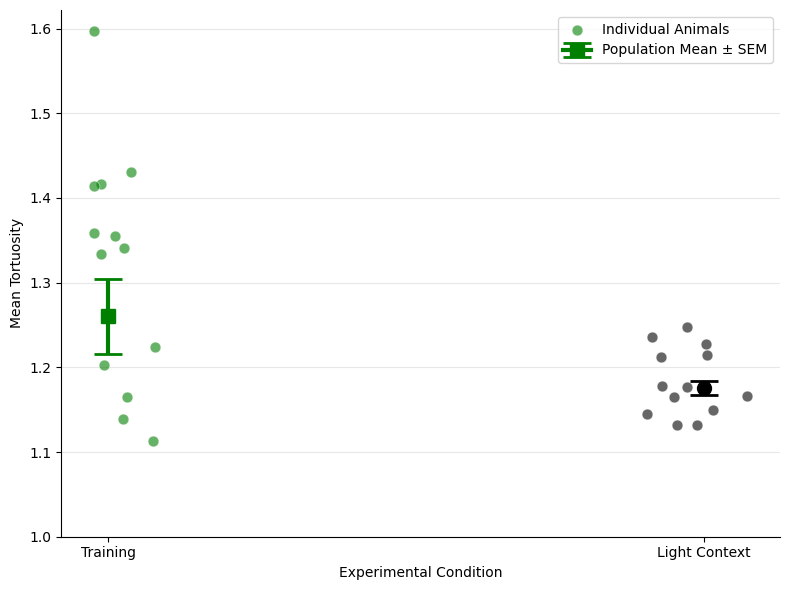

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create the plot with subplots
fig, ax = plt.subplots(figsize=(8, 6))

# Process train_df data
train_data = train_df[train_df.tortuosity <= 3]
train_animal_medians = train_data.groupby(['date_index', 'animal'])['tortuosity'].median().reset_index()
train_population_median = train_animal_medians['tortuosity'].median()
train_population_sem = train_animal_medians['tortuosity'].sem()

# Process light_dark data
light_data = light_dark[light_dark.task == 'oa']
light_data = light_data[light_data.tortuosity <= 3]
# light_data = light_data[~light_data['animal'].isin(['J701LT', 'J701RT', 'J701NN','J701RN'])] 
light_animal_medians = light_data.groupby(['date_index', 'animal'])['tortuosity'].median().reset_index()
light_population_median = light_animal_medians['tortuosity'].median()
light_population_sem = light_animal_medians['tortuosity'].sem()

# Create positions for the two groups
positions = [0, 1]
group_labels = ['Training', 'Light Context']

# Plot population medians with error bars (SEM)
ax.errorbar(positions[0], train_population_median, yerr=train_population_sem, 
            color='green', marker='s', markersize=10, capsize=10, capthick=2,
            linewidth=3, label='Population Mean ± SEM', zorder=5)

ax.errorbar(positions[1], light_population_median, yerr=light_population_sem, 
            color='black', marker='o', markersize=10, capsize=10, capthick=2,
            linewidth=3, zorder=5)

# Plot individual animal medians as scatter points
# Add jitter to x-position to avoid overplotting
np.random.seed(42)  # For reproducible jitter
train_jitter = np.random.normal(0, 0.05, len(train_animal_medians['animal'].unique()))
light_jitter = np.random.normal(0, 0.05, len(light_animal_medians['animal'].unique()))

# Get unique animals for each group
train_animals = train_animal_medians['animal'].unique()
light_animals = light_animal_medians['animal'].unique()

# Plot training individual animals
for i, animal in enumerate(train_animals):
    animal_median = train_animal_medians[train_animal_medians['animal'] == animal]['tortuosity'].median()
    ax.scatter(positions[0] + train_jitter[i], animal_median, 
               color='green', alpha=0.6, s=60, edgecolor='white', linewidth=0.5,
               label='Individual Animals' if i == 0 else '_nolegend_', zorder=4)

# Plot light/dark individual animals
for i, animal in enumerate(light_animals):
    animal_median = light_animal_medians[light_animal_medians['animal'] == animal]['tortuosity'].median()
    ax.scatter(positions[1] + light_jitter[i], animal_median, 
               color='black', alpha=0.6, s=60, edgecolor='white', linewidth=0.5,
               label='_nolegend_', zorder=4)

# Add labels and formatting
ax.set_xlabel('Experimental Condition')
ax.set_ylabel('Mean Tortuosity')
ax.set_xticks(positions)
ax.set_xticklabels(group_labels)

# Set y-axis limits if needed
ax.set_ylim(bottom=1)  # Adjust based on your data range

# Remove top and right axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add grid for better readability
ax.grid(True, alpha=0.3, axis='y')

# Add legend
ax.legend(loc='best')

plt.tight_layout()

# Optional: Add statistical annotation if you have statistical test results
# ax.text(0.5, max(train_population_median, light_population_median) + 0.1, 
#        '*', ha='center', va='bottom', fontsize=16)

plt.show()

NameError: name 'train_df' is not defined

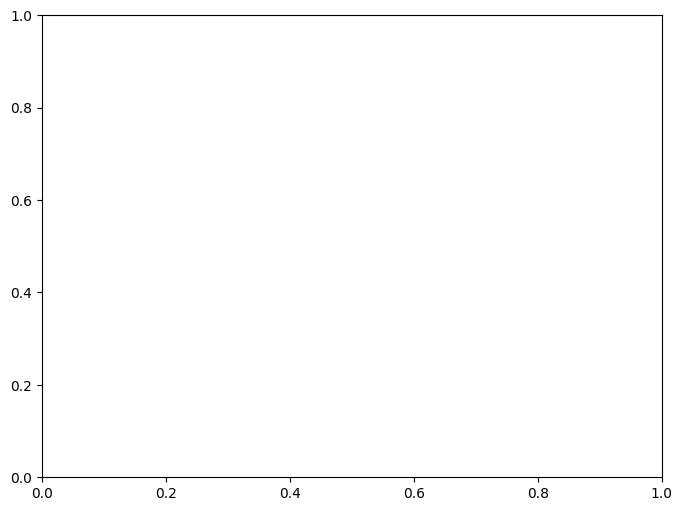

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create the plot with subplots
fig, ax = plt.subplots(figsize=(8, 6))

# Process train_df data
train_data = train_df[train_df.tortuosity <= 3]
train_data = train_df[train_df.date_index == -1]
train_animal_medians = train_data.groupby(['date_index', 'animal'])['tortuosity'].median().reset_index()

# Calculate population median and SEM for training
# Group by animal to get one median per animal across all dates
train_animal_final_medians = train_animal_medians.groupby('animal')['tortuosity'].median().reset_index()
train_population_median = train_animal_final_medians['tortuosity'].median()
train_population_sem = train_animal_final_medians['tortuosity'].sem()

# Process light_dark data
light_data = light_dark[light_dark.task == 'oa']
light_data = light_data[light_data.tortuosity <= 3]
light_data = light_data[light_data.date_index == 0]
# light_data = light_data[~light_data['animal'].isin(['J701LT', 'J701RT', 'J701NN','J701RN'])] 
light_animal_medians = light_data.groupby(['date_index', 'animal'])['tortuosity'].median().reset_index()

# Calculate population median and SEM for light/dark
# Group by animal to get one median per animal across all dates
light_animal_final_medians = light_animal_medians.groupby('animal')['tortuosity'].median().reset_index()
light_population_median = light_animal_final_medians['tortuosity'].median()
light_population_sem = light_animal_final_medians['tortuosity'].sem()

# Create positions for the two groups
positions = [0, 1]
group_labels = ['Training', 'Light Context']
bar_width = 0.6

# Plot population medians as bars with error bars (SEM)
bars = ax.bar(positions[0], train_population_median, width=bar_width, 
              color='green', alpha=0.7, label='Population Median', zorder=3)
ax.errorbar(positions[0], train_population_median, yerr=train_population_sem, 
            color='darkgreen', marker='', markersize=0, capsize=8, capthick=2,
            linewidth=2, linestyle='', zorder=5)

bars = ax.bar(positions[1], light_population_median, width=bar_width, 
              color='black', alpha=0.7, zorder=3)
ax.errorbar(positions[1], light_population_median, yerr=light_population_sem, 
            color='darkgray', marker='', markersize=0, capsize=8, capthick=2,
            linewidth=2, linestyle='', zorder=5)

# Plot individual animal medians as scatter points
# Add jitter to x-position to avoid overplotting
np.random.seed(42)  # For reproducible jitter
train_jitter = np.random.normal(0, 0.1, len(train_animal_final_medians))
light_jitter = np.random.normal(0, 0.1, len(light_animal_final_medians))

# Plot training individual animals
for i, row in train_animal_final_medians.iterrows():
    ax.scatter(positions[0] + train_jitter[i], row['tortuosity'], 
               color='green', alpha=0.6, s=60, edgecolor='white', linewidth=0.5,
               label='Individual Animals' if i == 0 else '_nolegend_', zorder=4)

# Plot light/dark individual animals
for i, row in light_animal_final_medians.iterrows():
    ax.scatter(positions[1] + light_jitter[i], row['tortuosity'], 
               color='black', alpha=0.6, s=60, edgecolor='white', linewidth=0.5,
               label='_nolegend_', zorder=4)

# Add labels and formatting
ax.set_xlabel('Experimental Condition')
ax.set_ylabel('Median Tortuosity')
ax.set_xticks(positions)
ax.set_xticklabels(group_labels)

# Set y-axis limits if needed
ax.set_ylim(bottom=1)  # Adjust based on your data range

# Remove top and right axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add grid for better readability
ax.grid(True, alpha=0.3, axis='y')

# Add legend
ax.legend(loc='best')

plt.tight_layout()

# Optional: Add statistical annotation if you have statistical test results
# ax.text(0.5, max(train_population_median, light_population_median) + 0.1, 
#        '*', ha='center', va='bottom', fontsize=16)

plt.show()

# Print summary statistics
print("Training Condition:")
print(f"  Number of animals: {len(train_animal_final_medians)}")
print(f"  Population median: {train_population_median:.3f}")
print(f"  SEM: {train_population_sem:.3f}")
print(f"  Individual animal medians: {train_animal_final_medians['tortuosity'].values}")

print("\nLight Context Condition:")
print(f"  Number of animals: {len(light_animal_final_medians)}")
print(f"  Population median: {light_population_median:.3f}")
print(f"  SEM: {light_population_sem:.3f}")
print(f"  Individual animal medians: {light_animal_final_medians['tortuosity'].values}")

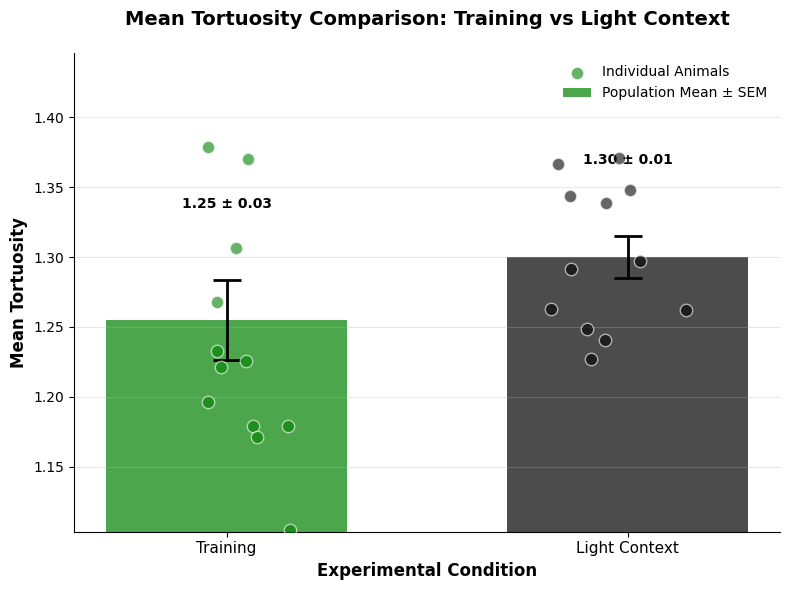

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create the plot with subplots
fig, ax = plt.subplots(figsize=(8, 6))

# Process train_df data
train_data = train_df
train_data = train_df[train_df.tortuosity <= 3]
train_data = train_data[train_data.date_index==-1]
train_animal_means = train_data.groupby(['date_index', 'animal'])['tortuosity'].mean().reset_index()
train_population_mean = train_animal_means['tortuosity'].mean()
train_population_sem = train_animal_means['tortuosity'].sem()

# Process light_dark data
light_data = light_dark[light_dark.task == 'oa']

light_data = light_data[light_data.tortuosity <= 3]
#light_data = light_data[light_data['obstacle_cluster'].isin([2,3])] 
light_data = light_data[light_data.date_index==1]
light_animal_means = light_data.groupby(['date_index', 'animal'])['tortuosity'].mean().reset_index()
light_population_mean = light_animal_means['tortuosity'].mean()
light_population_sem = light_animal_means['tortuosity'].sem()

# Create positions for the two groups
positions = [0, 1]
group_labels = ['Training', 'Light Context']
bar_width = 0.6

# Plot population means as bars with error bars (SEM)
bars = ax.bar(positions, [train_population_mean, light_population_mean], 
              width=bar_width, color=['green', 'black'], alpha=0.7,
              yerr=[train_population_sem, light_population_sem], 
              capsize=10, error_kw={'elinewidth': 2, 'capthick': 2},
              label='Population Mean ± SEM')

# Plot individual animal means as scatter points
# Add jitter to x-position to avoid overplotting
np.random.seed(42)  # For reproducible jitter
train_jitter = np.random.normal(0, 0.1, len(train_animal_means['animal'].unique()))
light_jitter = np.random.normal(0, 0.1, len(light_animal_means['animal'].unique()))

# Get unique animals for each group
train_animals = train_animal_means['animal'].unique()
light_animals = light_animal_means['animal'].unique()

# Plot training individual animals
for i, animal in enumerate(train_animals):
    animal_mean = train_animal_means[train_animal_means['animal'] == animal]['tortuosity'].mean()
    ax.scatter(positions[0] + train_jitter[i], animal_mean, 
               color='green', alpha=0.6, s=80, edgecolor='white', linewidth=1,
               label='Individual Animals' if i == 0 else '_nolegend_', zorder=5)

# Plot light/dark individual animals
for i, animal in enumerate(light_animals):
    animal_mean = light_animal_means[light_animal_means['animal'] == animal]['tortuosity'].mean()
    ax.scatter(positions[1] + light_jitter[i], animal_mean, 
               color='black', alpha=0.6, s=80, edgecolor='white', linewidth=1,
               label='_nolegend_', zorder=5)

# Add value labels on top of bars
for i, (mean, sem) in enumerate(zip([train_population_mean, light_population_mean], 
                                   [train_population_sem, light_population_sem])):
    ax.text(positions[i], mean + sem + 0.05, f'{mean:.2f} ± {sem:.2f}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add labels and formatting
ax.set_xlabel('Experimental Condition', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Tortuosity', fontsize=12, fontweight='bold')
ax.set_xticks(positions)
ax.set_xticklabels(group_labels, fontsize=11)

# Set y-axis limits with some padding
y_min = min(train_population_mean - train_population_sem, light_population_mean - light_population_sem) * 0.9
y_max = max(train_population_mean + train_population_sem, light_population_mean + light_population_sem) * 1.1
ax.set_ylim(y_min, y_max)

# Remove top and right axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add grid for better readability
ax.grid(True, alpha=0.3, axis='y')

# Add legend
ax.legend(loc='best', frameon=False)

# Add title
ax.set_title('Mean Tortuosity Comparison: Training vs Light Context', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()

# Optional: Add statistical annotation if you have statistical test results
# ax.text(0.5, max(train_population_mean, light_population_mean) + 0.1, 
#        '*', ha='center', va='bottom', fontsize=16)

plt.show()

In [58]:
train_data

,level_0,index,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,nose_likelihood,leftear_x,...,tortuosity,linearity,date_index,start,head_angle,head_angle_whole_trial,head_angle_velocity,head_angle_velocity_whole_trial,turn_direction,turn_direction_left_right
2596,2596,0,50247.852441,50249.396800,"[50247.865958, 50247.882073, 50247.898931, 502...","[72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 8...","[675.0280151367189, 675.0280151367189, 675.028...","[254.61351013183594, 254.61351013183594, 254.6...","[0.06801322847604752, 0.061899758875370026, 0....","[674.3634325810413, 674.3855603835425, 674.425...",...,1.442581,0.693202,-1.0,top,"[44.70473529037297, 44.739841068869964, 45.163...","[100.09426450388713, 99.98119199525459, 99.782...","[0.03676268527489812, 0.4434658102963396, 1.32...","[0.03676268527489812, 0.4434658102963396, 1.32...",down,right
2597,2597,1,50249.396800,50254.156761,"[50249.399078, 50249.415961, 50249.432896, 502...","[[164, 165, 166, 167, 168, 169, 170, 171, 172,...","[674.8306274414062, 674.8306245551744, 674.830...","[271.7885437011719, 271.78854871259625, 271.78...","[0.4414965808391571, 0.5344058275222778, 0.503...","[677.5368691664975, 677.5476629547716, 677.565...",...,1.012678,0.987481,-1.0,bottom,"[-57.704323269507924, -56.45509736803558, -54....","[-96.45115299850002, -96.27290708764863, -95.9...","[1.3081863049131925, 2.5524183863257566, 3.664...","[1.3081863049131925, 2.5524183863257566, 3.664...",down,right
2598,2598,2,50254.156761,50258.576665,"[50254.167488, 50254.184921, 50254.200704, 502...","[450, 451, 452, 453, 454, 455, 456, 457, 458, ...","[108.22493185366221, 108.14825201945754, 108.0...","[258.8528146564046, 258.84789445172737, 258.84...","[0.8622837662696838, 0.9034079313278198, 0.942...","[122.27672845973808, 122.24343876222807, 122.1...",...,1.013240,0.986933,-1.0,bottom,"[-36.96097469183741, -34.37989622665458, -29.9...","[-139.59816282763003, -139.5349738269801, -139...","[2.702899048185734, 4.6449129026779605, 5.5008...","[2.702899048185734, 4.6449129026779605, 5.5008...",down,left
2599,2599,3,50258.576665,50262.300288,"[50258.585484, 50258.602163, 50258.619814, 502...","[[715, 716, 717, 718, 719, 720, 721, 722, 723,...","[674.6126708984375, 674.6126708984375, 674.612...","[250.88551330566403, 250.88551330566403, 250.8...","[0.2774178385734558, 0.1592460423707962, 0.164...","[672.4481660848379, 672.6168494393683, 672.927...",...,1.008984,0.991096,-1.0,bottom,"[-32.15030846649823, -30.626658770095094, -28....","[103.47165340072105, 102.82216444785851, 101.6...","[1.59556223095481, 2.7333705280744915, 3.22643...","[1.59556223095481, 2.7333705280744915, 3.22643...",down,right
2600,2600,4,50262.300288,50265.794432,"[50262.303347, 50262.320153, 50262.33792, 5026...","[938, 939, 940, 941, 942, 943, 944, 945, 946, ...","[111.37246704101562, 111.37246704101562, 111.3...","[243.02639770507812, 243.02639770507812, 243.0...","[0.14326253533363342, 0.1265486776828766, 0.06...","[120.78631829981003, 120.79673617600778, 120.8...",...,1.005602,0.994430,-1.0,top,"[40.06885815271369, 37.65976058738551, 33.4714...","[134.80157564464395, 134.8789623479478, 135.01...","[-2.522801071005345, -4.385961268817889, -5.29...","[-2.522801071005345, -4.385961268817889, -5.29...",up,right
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9238,2520,130,46302.755558,46309.616998,"[46302.767744, 46302.784371, 46302.801049, 463...","[84392, 84393, 84394, 84395, 84396, 84397, 843...","[91.4333267211914, 91.85319519042969, 93.84513...","[222.04513549804688, 221.6123504638672, 221.33...","[0.99132239818573, 0.9838533401489258, 0.96963...","[96.326171875, 96.2281494140625, 97.7683334350...",...,2.314028,0.432147,-1.0,top,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[154.18155255776358, 153.61064367084055, 152.0...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",up,right
9240,2522,132,46321.139993

In [57]:
light_data

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,angles_at_head_turns_ends,avg_speed,avg_ts_speed,head_angle_whole_trial,head_angle_velocity_whole_trial,turn_direction_left_right,intial_distance,goal_distance_from_target_port,goal_angle_to_target_port,goal_lateral_error_to_target_port
0,0,48054.835737,48059.792371,"[48054.850086, 48054.866291, 48054.883008, 480...","[[718, 719, 720, 721, 722, 723, 724, 725, 726,...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[646.5863647460938, 647.6791381835938, 647.953...","[256.8539123535156, 256.5686340332031, 256.810...","[655.6896362304688, 655.893798828125, 656.1171...",...,"[0.4748630033916924, 13.206937651525928, 29.11...",17.107891,17.150953,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-2.5067424782757053, -3.975730695107509, -3.9...",left,23.0,"[22.0959312118867, 21.663251903654018, 21.2305...","[7.429573008006076, 3.8913678278574193, 6.6502...","[8.090737985945012, 8.097815708845173, 8.10489..."
1,1,48059.792371,48066.055564,"[48059.801369, 48059.818099, 48059.834739, 480...","[1015, 1016, 1017, 1018, 1019, 1020, 1021, 102...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[100.70337677001953, 100.96659851074219, 100.9...","[229.06690979003906, 229.2141571044922, 229.14...","[97.77118682861328, 97.44432830810547, 97.2664...",...,"[5.1771296691027295, 55.096723742024594, 117.9...",16.703003,16.664893,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[2.681299671880082, 4.408661208135752, 4.82935...",left,12.0,"[32.40458268960001, 31.682537511489265, 30.960...","[7.88523149777408, 6.681033882623484, 16.72080...","[5.699668885836058, 6.02997036219443, 6.360271..."
2,2,48066.055564,48070.369088,"[48066.070515, 48066.087513, 48066.103731, 480...","[[1391, 1392, 1393, 1394, 1395, 1396, 1397, 13...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[652.5042114257812, 653.2907104492188, 653.849...","[249.86825561523438, 249.44972229003906, 249.3...","[653.6144409179688, 655.35498046875, 655.19451...",...,[49.773470466177024],21.682364,21.810839,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-0.5522916970620639, -0.8708074362329055, -0....",right,24.0,"[22.360668702782093, 21.628938184728185, 20.92...","[8.945629711439155, 6.775464098045578, 5.25602...","[7.575429066207144, 7.619104329372066, 7.57230..."
3,3,48070.369088,48076.550553,"[48070.37175, 48070.388352, 48070.40526, 48070...","[1649, 1650, 1651, 1652, 1653, 1654, 1655, 165...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[102.01713562011719, 102.3261489868164, 102.09...","[225.12435913085938, 225.2169189453125, 225.56...","[97.98050689697266, 98.4389877319336, 98.42494...",...,"[43.861660432756864, 64.82904966104601]",14.243221,14.215612,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-0.3559020814814273, -0.5258943041331365, -0....",right,11.0,"[33.23714013772765, 32.30934654354773, 31.3815...","[152.06101593094374, 111.6066552513647, 44.515...","[4.57016145059243, 5.210001667301693, 5.849841..."
4,4,48076.550553,48079.610534,"[48076.557094, 48076.574464, 48076.590464, 480...","[[2020, 2021, 2022, 2023, 2024, 2025, 2026, 20...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[652.8433227539062, 653.4661254882812, 654.875...","[250.68643188476562, 250.68145751953125, 250.4...","[650.7364501953125, 652.0059814453125, 654.872...",...,[nan],30.510427,31.092952,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[-1.2344531897695687, -2.0689609014932064, -2....",left,24.0,"[22.435908738967214, 21.42253700182775, 20.623...","[17.686200424649765, 21.192715249003555, 18.82...","[8.902605950208045, 8.912086263773013, 8.87631..."
...,...,...,...,...,...,...,...,..

In [59]:
train_tortuosity

0     1.225778
1     1.221004
2     1.178927
3     1.179386
4     1.267534
5     1.232530
6     1.104785
7     1.170970
8     1.196590
9     1.370443
10    1.477320
11    1.379104
12    1.306345
Name: tortuosity, dtype: float64

In [60]:
light_animal_means

,date_index,animal,tortuosity
0,0.0,G8CK1LN,1.347719
1,0.0,G8CK1LT,1.418064
2,0.0,G8CK1RT,1.317917
3,0.0,G8CK1TT,1.287153
4,0.0,G8CKLN,1.423224
5,0.0,G8CKLT,1.389887
6,0.0,G8CKRN,1.377431
7,0.0,G8CKRT,1.528022
8,0.0,G8CKTT,1.255006
9,0.0,J701LT,1.524389


(array([4976., 2292.,  802.,  292.,  132.,   64.,   32.,   32.,   28.,
          22.]),
 array([1.01267581, 1.21025657, 1.40783733, 1.6054181 , 1.80299886,
        2.00057962, 2.19816038, 2.39574114, 2.59332191, 2.79090267,
        2.98848343]),
 <BarContainer object of 10 artists>)

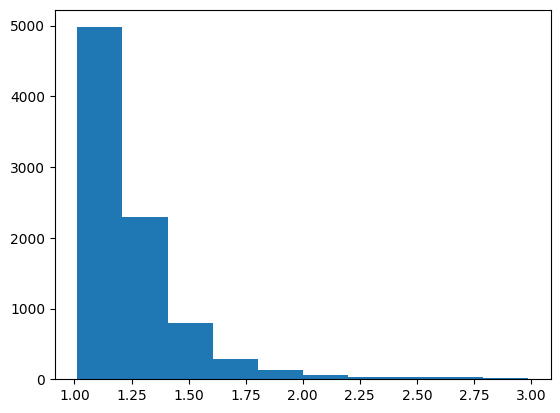

In [67]:
light_data = light_dark[light_dark.task =='oa']
light_data = light_data[light_data.tortuosity <= 3]
light_tortuosity = light_data['tortuosity'].to_numpy()
plt.hist(light_tortuosity)

In [ ]:
light_data = light_dark[light_dark.task =='oa']
light_data = light_data[light_data.tortuosity <= 3]
light_tortuosity = light_data['tortuosity'].to_numpy()
plt.hist(light_tortuosity)

(array([2173.,  446.,  191.,  117.,   74.,   53.,   44.,   26.,   30.,
          28.]),
 array([1.00202405, 1.20143124, 1.40083843, 1.60024561, 1.7996528 ,
        1.99905999, 2.19846718, 2.39787436, 2.59728155, 2.79668874,
        2.99609592]),
 <BarContainer object of 10 artists>)

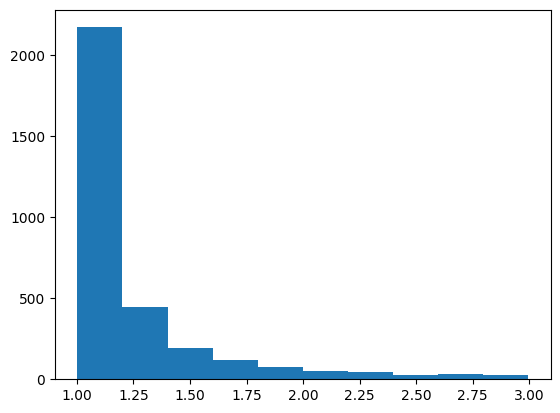

In [63]:
plt.hist(train_tortuosity)

NameError: name 'light_data' is not defined

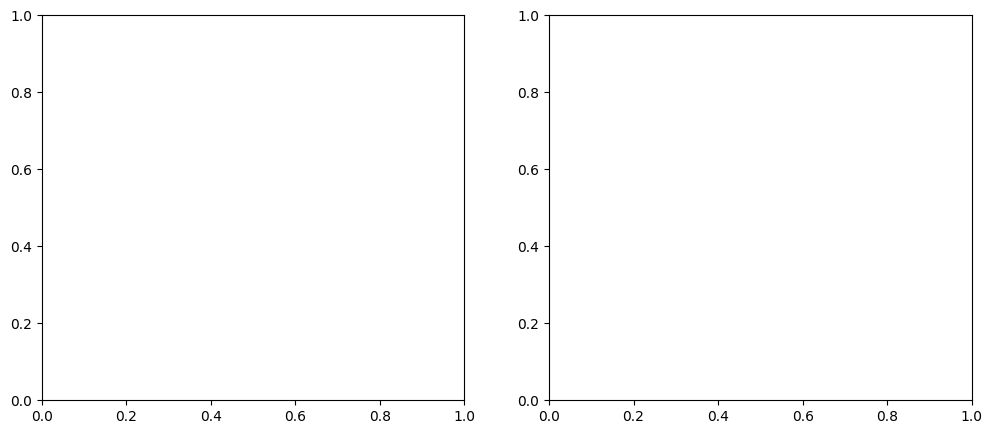

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Create the plot with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Get the full tortuosity data (not means)
train_tortuosity = train_df['tortuosity'].to_numpy()
light_tortuosity = light_data['tortuosity'].to_numpy()

# Calculate statistics for annotation
train_mean = train_tortuosity.mean()
#train_median = train_tortuosity.median()
train_std = train_tortuosity.std()

light_mean = light_tortuosity.mean()
#light_median = light_tortuosity.median()
light_std = light_tortuosity.std()

# Determine bin range based on data
all_data = np.concatenate([train_tortuosity, light_tortuosity])
bin_range = (all_data.min(), all_data.max())
bins = np.linspace(bin_range[0], bin_range[1], 20)

# Plot training distribution
ax1.hist(train_tortuosity, bins=bins, color='green', alpha=0.7, edgecolor='black', linewidth=0.5, density=True)
ax1.axvline(train_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {train_mean:.2f}')
#ax1.axvline(train_median, color='blue', linestyle='--', linewidth=2, label=f'Median: {train_median:.2f}')
ax1.set_xlabel('Tortuosity', fontsize=12, fontweight='bold')
ax1.set_ylabel('Density', fontsize=12, fontweight='bold')
ax1.set_title('Training Condition\nFull Tortuosity Distribution', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add statistics text box
textstr = f'Mean: {train_mean:.2f}\nMedian: {train_median:.2f}\nStd: {train_std:.2f}\nn: {len(train_tortuosity)}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax1.text(0.95, 0.95, textstr, transform=ax1.transAxes, fontsize=10,
         verticalalignment='top', horizontalalignment='right', bbox=props)

# Plot light context distribution
ax2.hist(light_tortuosity, bins=bins, color='black', alpha=0.7, edgecolor='white', linewidth=0.5, density=True)
ax2.axvline(light_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {light_mean:.2f}')
#ax2.axvline(light_median, color='blue', linestyle='--', linewidth=2, label=f'Median: {light_median:.2f}')
ax2.set_xlabel('Tortuosity', fontsize=12, fontweight='bold')
ax2.set_ylabel('Density', fontsize=12, fontweight='bold')
ax2.set_title('Light Context Condition\nFull Tortuosity Distribution', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Add statistics text box
textstr = f'Mean: {light_mean:.2f}\nMedian: {light_median:.2f}\nStd: {light_std:.2f}\nn: {len(light_tortuosity)}'
ax2.text(0.95, 0.95, textstr, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', horizontalalignment='right', bbox=props)

# Remove top and right spines from both plots
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Alternative: Overlaid histograms for direct comparison
fig, ax = plt.subplots(figsize=(10, 6))

# Plot both distributions on the same axes
ax.hist(train_tortuosity, bins=bins, color='green', alpha=0.6, edgecolor='black', 
        linewidth=0.5, label='Training', density=True)
ax.hist(light_tortuosity, bins=bins, color='black', alpha=0.6, edgecolor='white', 
        linewidth=0.5, label='Light Context', density=True)

# Add mean lines
ax.axvline(train_mean, color='green', linestyle='--', linewidth=2, alpha=0.8, label='Training Mean')
ax.axvline(light_mean, color='black', linestyle='--', linewidth=2, alpha=0.8, label='Light Context Mean')

ax.set_xlabel('Tortuosity', fontsize=12, fontweight='bold')
ax.set_ylabel('Density', fontsize=12, fontweight='bold')
ax.set_title('Full Tortuosity Distribution Comparison\nTraining vs Light Context', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Kernel Density Estimate plot for smoother distribution visualization
fig, ax = plt.subplots(figsize=(10, 6))

# Plot KDE for both conditions using the full data
sns.kdeplot(train_tortuosity, color='green', label='Training', linewidth=2, ax=ax, fill=True, alpha=0.3)
sns.kdeplot(light_tortuosity, color='black', label='Light Context', linewidth=2, ax=ax, fill=True, alpha=0.3)

# Add mean lines
ax.axvline(train_mean, color='green', linestyle='--', linewidth=2, alpha=0.8, label='Training Mean')
ax.axvline(light_mean, color='black', linestyle='--', linewidth=2, alpha=0.8, label='Light Context Mean')

ax.set_xlabel('Tortuosity', fontsize=12, fontweight='bold')
ax.set_ylabel('Density', fontsize=12, fontweight='bold')
ax.set_title('Full Tortuosity Distribution (KDE)\nTraining vs Light Context', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Box plot for another perspective
fig, ax = plt.subplots(figsize=(8, 6))

# Create box plot
boxplot_data = [train_tortuosity, light_tortuosity]
box = ax.boxplot(boxplot_data, patch_artist=True, labels=['Training', 'Light Context'])

# Customize box plot colors
colors = ['green', 'black']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in box['medians']:
    median.set_color('red')
    median.set_linewidth(2)

ax.set_ylabel('Tortuosity', fontsize=12, fontweight='bold')
ax.set_title('Tortuosity Distribution Comparison\n(Box Plot)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

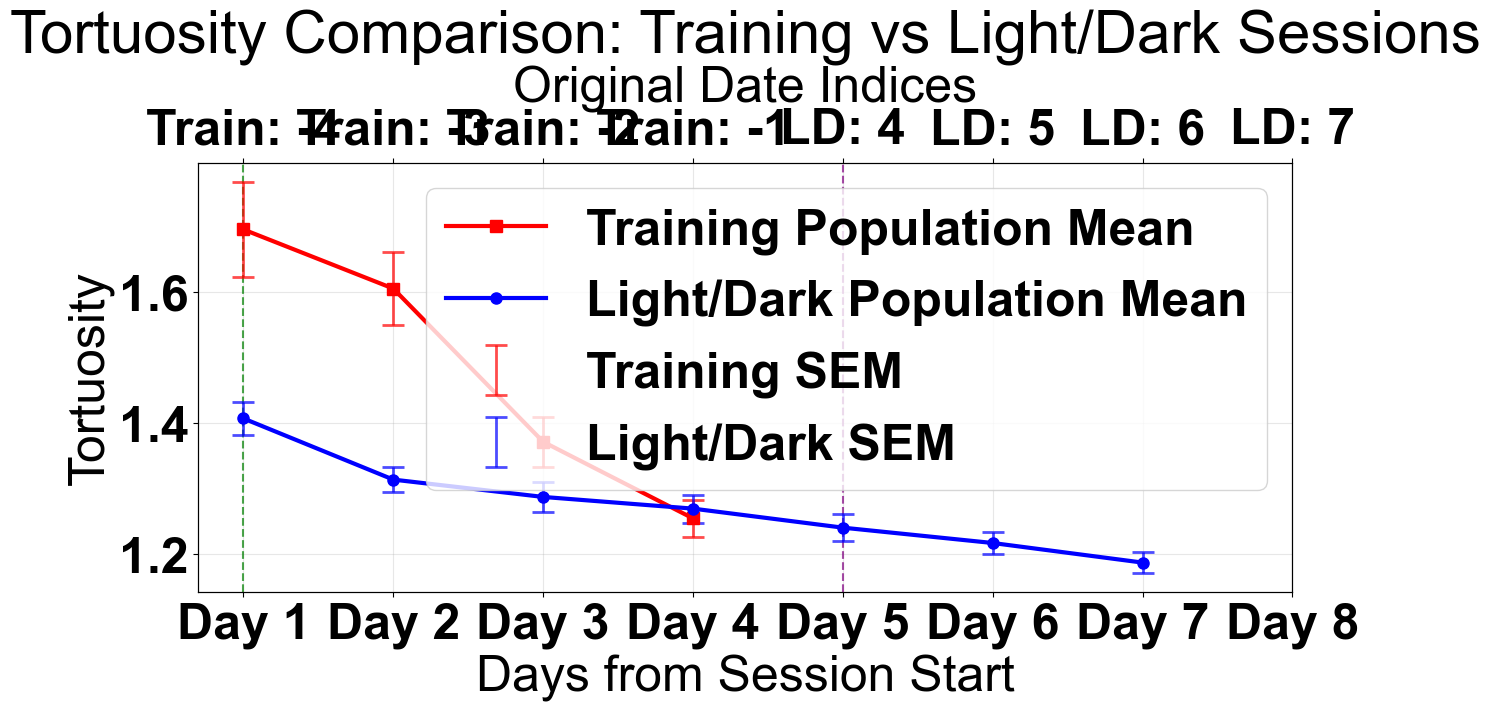

In [404]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create the plot with dual x-axis
fig, ax1 = plt.subplots(figsize=(14, 8))

# Process data (same as before)
train_data = train_df[train_df.tortuosity <= 3]
train_animal_means = train_data.groupby(['date_index', 'animal'])['tortuosity'].mean().reset_index()
train_population_stats = train_animal_means.groupby('date_index')['tortuosity'].agg(['mean', 'sem']).reset_index()

light_data = light_dark[light_dark.task == 'oa']
light_data = light_data[light_data.tortuosity <= 4]
light_animal_means = light_data.groupby(['date_index', 'animal'])['tortuosity'].mean().reset_index()
light_population_stats = light_animal_means.groupby('date_index')['tortuosity'].agg(['mean', 'sem']).reset_index()

# Create aligned x-axis
train_population_stats['aligned_date'] = train_population_stats['date_index'] + 4
light_population_stats['aligned_date'] = light_population_stats['date_index']

# Plot both datasets on aligned x-axis
# Training data
ax1.plot(train_population_stats['aligned_date'], train_population_stats['mean'], 
         color='red', marker='s', linewidth=3, markersize=8, 
         label='Training Population Mean', zorder=5)

ax1.errorbar(train_population_stats['aligned_date'], train_population_stats['mean'], 
             yerr=train_population_stats['sem'], 
             color='red', alpha=0.7, capsize=8, capthick=2, elinewidth=2,
             linestyle='None', label='Training SEM', zorder=4)

# Light/Dark data
ax1.plot(light_population_stats['aligned_date'], light_population_stats['mean'], 
         color='blue', marker='o', linewidth=3, markersize=8, 
         label='Light/Dark Population Mean', zorder=5)

ax1.errorbar(light_population_stats['aligned_date'], light_population_stats['mean'], 
             yerr=light_population_stats['sem'], 
             color='blue', alpha=0.7, capsize=8, capthick=2, elinewidth=2,
             linestyle='None', label='Light/Dark SEM', zorder=4)

# Create second x-axis for original date indices
ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())

# Set ticks for both axes
aligned_ticks = list(range(0, 8))  # Adjust based on your data range
ax1.set_xticks(aligned_ticks)
ax1.set_xticklabels([f'Day {i+1}' for i in aligned_ticks])

# For ax2, show both original values
train_original_ticks = [-4, -3, -2, -1]
light_original_ticks = [0, 1, 2, 3, 4, 5, 6]

# Create combined tick labels
combined_labels = []
for tick in aligned_ticks:
    if tick < 4:  # Training days
        orig_val = tick - 4
        combined_labels.append(f'Train: {orig_val}')
    else:  # Light/Dark days
        orig_val = tick
        combined_labels.append(f'LD: {orig_val}')

ax2.set_xticks(aligned_ticks)
ax2.set_xticklabels(combined_labels)
ax2.set_xlabel('Original Date Indices')

# Add labels and formatting
ax1.set_xlabel('Days from Session Start')
ax1.set_ylabel('Tortuosity')
ax1.set_title('Tortuosity Comparison: Training vs Light/Dark Sessions')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add vertical line to show session transition
ax1.axvline(x=0, color='green', linestyle='--', alpha=0.7, label='Session Start')
ax1.axvline(x=4, color='purple', linestyle='--', alpha=0.7, label='Training End / LightDark Start')

plt.tight_layout()
plt.show()

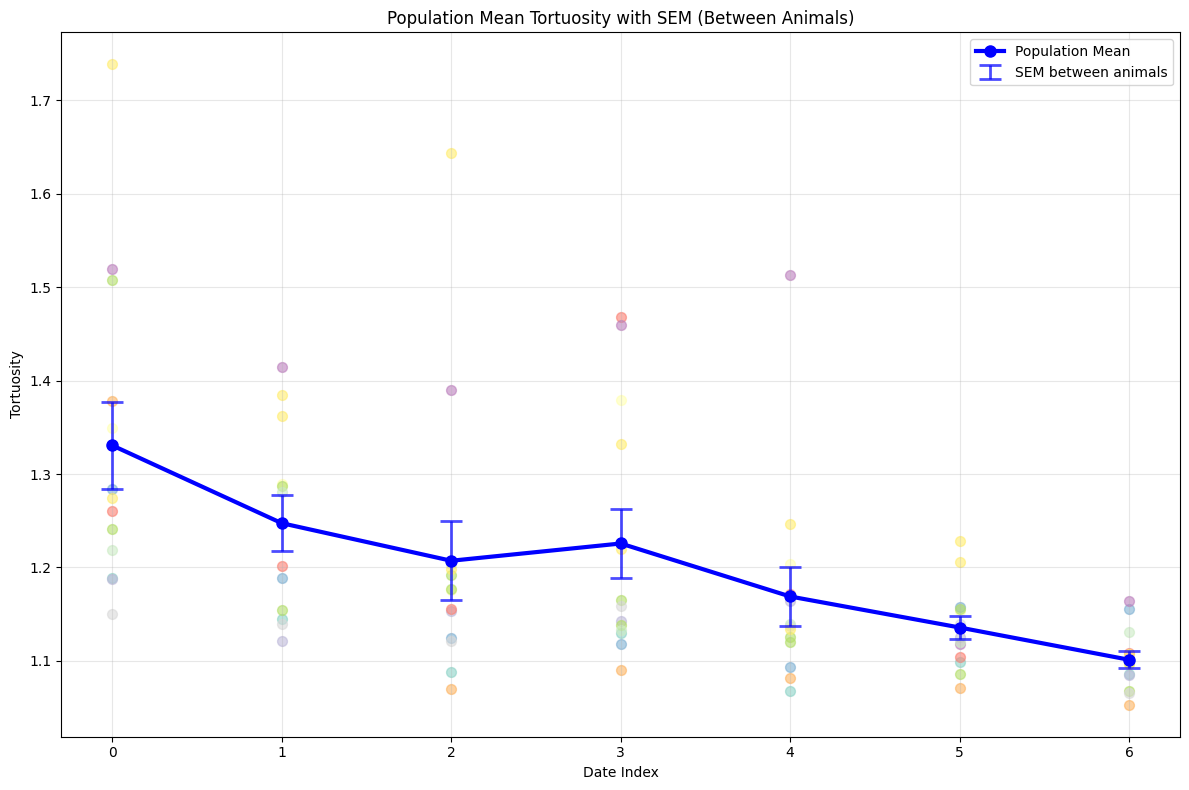

In [122]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# First calculate the mean tortuosity for each animal at each date index
data = light_side[light_side.tortuosity<=4]
data = data[data.intial_lateral_error>0]
animal_means = data.groupby(['date_index', 'animal'])['tortuosity'].mean().reset_index()

# Now calculate population mean and SEM across animals for each date index
population_stats = animal_means.groupby('date_index')['tortuosity'].agg(['mean', 'sem']).reset_index()

# Create the plot
plt.figure(figsize=(12, 8))

# Plot population mean line
plt.plot(population_stats['date_index'], population_stats['mean'], 
         color='blue', marker='o', linewidth=3, markersize=8, 
         label='Population Mean', zorder=5)

# Plot SEM error bars (between animals)
plt.errorbar(population_stats['date_index'], population_stats['mean'], 
             yerr=population_stats['sem'], 
             color='blue', alpha=0.7, capsize=8, capthick=2, elinewidth=2,
             linestyle='None', label='SEM between animals', zorder=4)

## Optional: Add individual animal means as faint points
animals = animal_means['animal'].unique()
colors = plt.cm.Set3(np.linspace(0, 1, len(animals)))

for i, animal in enumerate(animals):
    animal_data = animal_means[animal_means['animal'] == animal]
    plt.scatter(animal_data['date_index'], animal_data['tortuosity'], 
                color=colors[i], alpha=0.6, s=50, label=f'_nolegend_')

# Add labels and formatting
plt.xlabel('Date Index')
plt.ylabel('Tortuosity')
plt.title('Population Mean Tortuosity with SEM (Between Animals)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

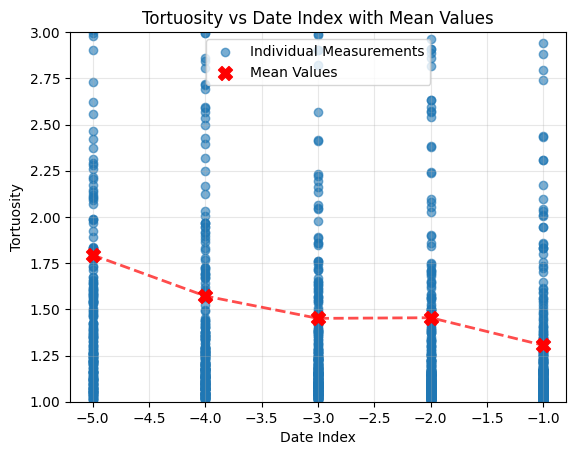

In [249]:
import matplotlib.pyplot as plt
import numpy as np

# Create the scatter plot
plt.scatter(train2.date_index.to_numpy(), train2.tortuosity.to_numpy(), alpha=0.6, label='Individual Measurements')

# Calculate mean tortuosity for each date index
mean_tortuosity = train2.groupby('date_index')['tortuosity'].mean().reset_index()

# Plot the mean values
plt.scatter(mean_tortuosity.date_index, mean_tortuosity.tortuosity, 
            color='red', s=100, marker='X', label='Mean Values', zorder=5)

# Optional: Add connecting lines between mean points
plt.plot(mean_tortuosity.date_index, mean_tortuosity.tortuosity, 
         color='red', linestyle='--', alpha=0.7, linewidth=2)

# Add labels and legend
plt.xlabel('Date Index')
plt.ylabel('Tortuosity')
plt.title('Tortuosity vs Date Index with Mean Values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(1,3)
plt.show()

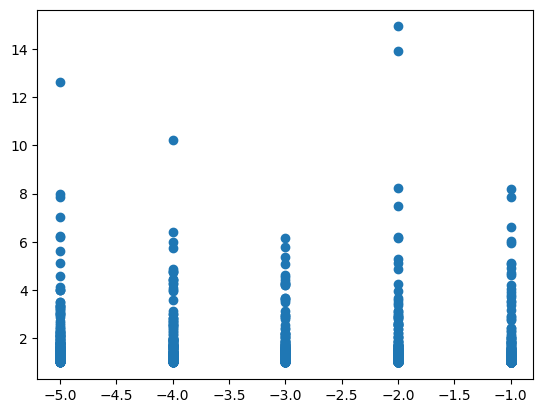

In [245]:
plt.scatter(train2.date_index.to_numpy(),train2.tortuosity.to_numpy())

In [146]:
train_df.columns.to_numpy()


array(['index', 'first_poke', 'second_poke', 'trial_timestamps',
       'trial_vidframes', 'nose_x', 'nose_y', 'nose_likelihood',
       'leftear_x', 'leftear_y', 'leftear_likelihood', 'rightear_x',
       'rightear_y', 'rightear_likelihood', 'spine_x', 'spine_y',
       'spine_likelihood', 'midspine_x', 'midspine_y',
       'midspine_likelihood', 'tailbase_x', 'tailbase_y',
       'tailbase_likelihood', 'midtail_x', 'midtail_y',
       'midtail_likelihood', 'tailend_x', 'tailend_y',
       'tailend_likelihood', 'arenaTL_x', 'arenaTL_y',
       'arenaTL_likelihood', 'arenaTR_x', 'arenaTR_y',
       'arenaTR_likelihood', 'arenaBL_x', 'arenaBL_y',
       'arenaBL_likelihood', 'arenaBR_x', 'arenaBR_y',
       'arenaBR_likelihood', 'leftportT_x', 'leftportT_y',
       'leftportT_likelihood', 'leftportB_x', 'leftportB_y',
       'leftportB_likelihood', 'rightportT_x', 'rightportT_y',
       'rightportT_likelihood', 'rightportB_x', 'rightportB_y',
       'rightportB_likelihood', 'len', 'anim

<AxesSubplot: >

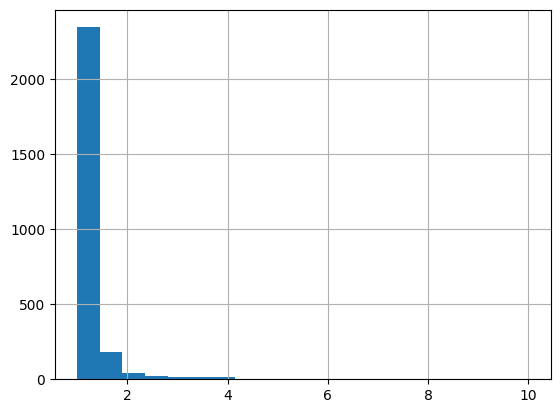

In [24]:
light_mid.tortuosity.hist(range=(1,10),bins=20)

<AxesSubplot: >

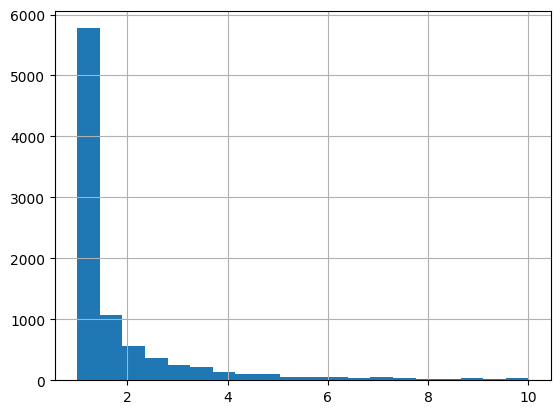

In [23]:
train_df.tortuosity.hist(range=(1,10),bins=20)

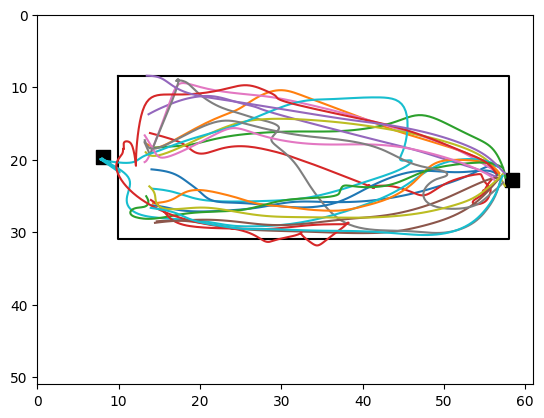

In [21]:
data = train_df[(train_df.animal=='J701RT') &(train_df.date_index==-1) &(train_df.odd=='left')&(train_df.time<=10)]
#thresh = data.time.mean()
#data = data[data.time<=thresh]
xmin,xmax = data.arenaTL_x_cm.astype(int).unique()[0],data.arenaTR_x_cm.astype(int).unique()[0]
ymin,ymax = data.arenaTL_y_cm.astype(int).unique()[0] ,data.arenaBL_y_cm.astype(int).unique()[0]

nose_x,nose_y = flatten_list_of_arrays(data.ts_nose_x_cm.to_list()),flatten_list_of_arrays(data.ts_nose_y_cm.to_list())

array ,xedges ,yedges   = np.histogram2d(nose_x.astype(float), nose_y.astype(float), range = [[xmin,xmax],[ymin,ymax ]],bins=(list(range(xmin,xmax,2)), list(range(ymin,ymax,2)),))
#array_list.append(array)
fig,ax = plt.subplots()
plot_arena(data,ax)
for ind, row in data.sample(20).iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

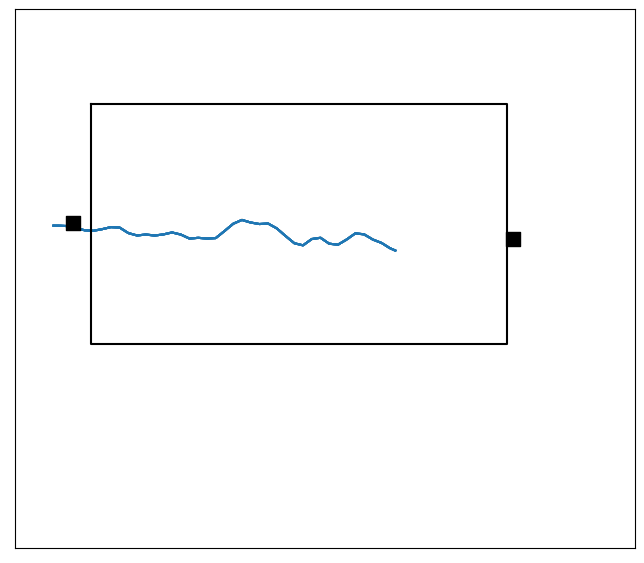

In [341]:
# Second figure (MON condition)
fig2, ax2 = plt.subplots(figsize=(8, 7))
data = train_df[(train_df.animal=='J701RT') &(train_df.date_index==-4) ]
ax2.set_xticks([])
ax2.set_yticks([])
plot_arena(data, ax2)
#ob_x, ob_y = plot_orginal_obstacle(data, ax2, 5)

# Get median trajectory using new function
data_nose_y, data_nose_x = get_median_trajectory(data, 'ts_nose_x_cm', 'ts_nose_y_cm',
                                                    turn_direction_key='odd',
                                                    start_position_key='start',
                                                    return_matrix=False)
data_nose_x = smooth(data_nose_x)
data_nose_y = smooth(data_nose_y)
#ax2.plot(data_nose_x, data_nose_y, linewidth=3, c='tab:blue', zorder=0)

# Plot individual trajectories
data_sample_towards = data
for ind, row in data_sample_towards.iterrows():
    #x, y = correct_trace(row, ob_x, ob_y)
    ax2.plot(data_nose_x, data_nose_y, alpha=.2, c='tab:blue', zorder=0)
    #ax2.scatter(x[head_turn_index],y[head_turn_index],color = 'black') 

plt.show()

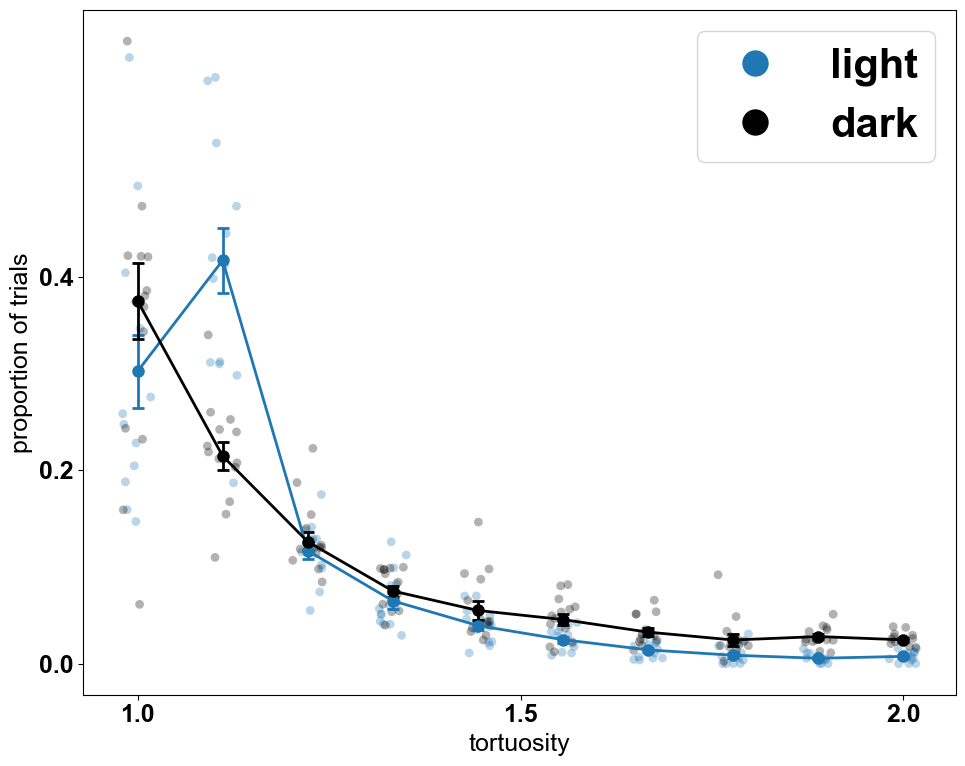

<Figure size 640x480 with 0 Axes>

In [134]:
xnew = np.linspace(1, 2, 10)

#light = light[~light['obstacle_cluster'].isin([2,3])] 
#light = light[light.intial_lateral_error<0]
#light = light[light.intial_distance>=15]  


fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (normal weight for text, bold for numbers)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = light[light.task == 'oa']

light_dist = (light.tortuosity.round(2).to_numpy())
light_dist = light_dist[np.where((light_dist <= 2))]

light_counts, light_bins = np.histogram(light_dist, bins=10,range=(1,2))
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []
light_mean = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.tortuosity.round(2).to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists <= 2))]
    
    counts, bins = np.histogram(ani_light_dists, bins=10,range=(1,2))
    prob = counts / sum(counts)
    light_prob.append(prob)
    light_mean.append(np.nanmean(ani_light_dists))
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.02, 0.02, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
# Calculate SEM instead of SD
light_sem = np.nanstd(light_prob, axis=0) / np.sqrt(np.sum(~np.isnan(light_prob), axis=0))

# Process dark condition
dark = train_df
dark_dist = (dark.tortuosity.round(2).to_numpy())
dark_dist = dark_dist[np.where((dark_dist <= 2))]

dark_counts, dark_bins = np.histogram(dark_dist, bins=10,range=(1,2))
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []
dark_mean = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.tortuosity.round(2).to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists <= 2))]
    
    counts, bins = np.histogram(ani_dark_dists, bins=10,range=(1,2))
    prob = counts / sum(counts)
    dark_prob.append(prob)
    dark_mean.append(np.nanmean(ani_dark_dists))
    
    # Add jitter to x positions for scatter
    x_jittered = xnew + np.random.uniform(-0.02, 0.02, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
# Calculate SEM instead of SD
dark_sem = np.nanstd(dark_prob, axis=0) / np.sqrt(np.sum(~np.isnan(dark_prob), axis=0))

# Plot individual points first (so they're behind the lines)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_hist, yerr=light_sem,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sem,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting
ax.set_xticks([1, 1.5, 2])
ax.set_yticks([0, 0.2, 0.4])
ax.set_ylabel('proportion of trials', fontweight='normal')  # Not bold
ax.set_xlabel('tortuosity', fontweight='normal')     # Not bold

# Make only the numbers bold
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')



# Legend
ax.legend(loc='upper right', framealpha=0.8)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=20),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=20)
]

# Update your legend call
ax.legend(handles=legend_handles, loc='upper right', fontsize=30, framealpha=0.8)


plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

In [501]:
row.ts_speed

array([30.50553737060481, 31.084957582187542, 32.20978411442413,
       33.80532013040248, 35.747321254828805, 37.86293561845169,
       39.95348090507456, 41.83255332257895, 43.370383498579606,
       44.51331522924482, 45.26819801269449, 45.66270861661909,
       45.71290840214243, 45.42575698625822, 44.82515785426934,
       43.98115648789444, 43.01692482895871, 42.086079127223854,
       41.33683434348598, 40.88069672506, 40.76740738341441,
       40.985325818074344, 41.481533911235836, 42.20391264382557,
       43.13690602569699, 44.305015102443384, 45.71777403640779,
       47.29652404374998, 48.83673712746423, 50.063052939715945,
       50.75374859834797, 50.853430506974334, 50.49255722577087,
       49.89026263531743, 49.21762401532908, 48.52030411888447,
       47.74598923646589, 46.84013955637613, 45.824145273688885,
       44.80836671506849, 43.942638120314584, 43.352873512529634,
       43.098748166677765, 43.16467266334809, 43.47378739386072,
       43.91563658866631, 44.3

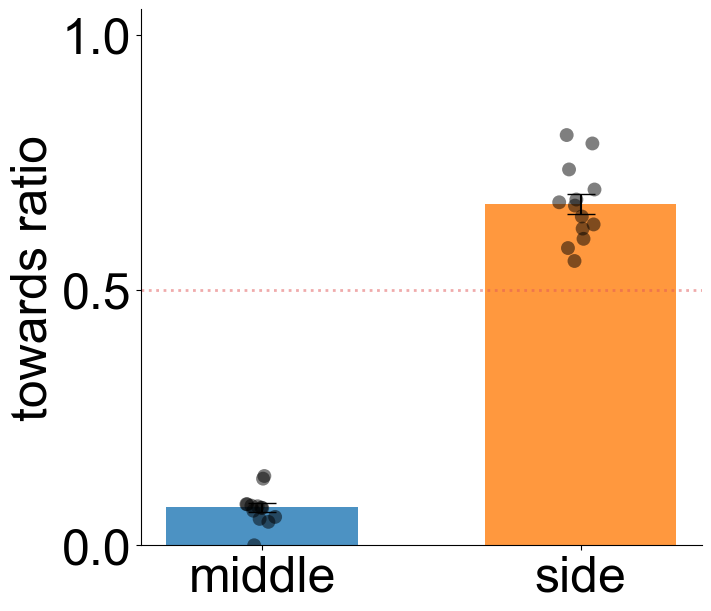

In [499]:
font = {'family': 'arial', 'size': 36,'weight':'normal'}
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rc('font', **font)

# Create figure
fig, ax = plt.subplots(figsize=(8, 7))  # Wider figure for two bars

# Prepare data - using light_dark dataframe and filtering for light condition
light_data = light_dark[light_dark['task'] == 'oa']

# Filter for middle and side clusters
middle_data = light_data[light_data['obstacle_cluster'].isin([2, 3])]
side_data = light_data[light_data['obstacle_cluster'].isin([1, 4])]

# Function to calculate ratio and individual animal ratios
def calculate_ratios(data):
    total = len(data)
    towards = len(data[data['turn_to_obstacle'] == 'towards']) if total > 0 else 0
    ratio = towards / total if total > 0 else 0
    
    animal_ratios = []
    for animal in data['animal'].unique():
        animal_data = data[data['animal'] == animal]
        a_total = len(animal_data)
        a_towards = len(animal_data[animal_data['turn_to_obstacle'] == 'towards']) if a_total > 0 else 0
        a_ratio = a_towards / a_total if a_total > 0 else 0
        animal_ratios.append(a_ratio)
    
    se = np.std(animal_ratios) / np.sqrt(len(animal_ratios)) if animal_ratios else 0
    return ratio, animal_ratios, se

# Calculate for middle and side
middle_ratio, middle_animal_ratios, middle_se = calculate_ratios(middle_data)
side_ratio, side_animal_ratios, side_se = calculate_ratios(side_data)

# Plot settings
bar_width = 0.6
colors = ['tab:blue', 'tab:orange']  # Different colors for middle and side
x_positions = [0, 1]  # Positions for the two bars
labels = ['middle', 'side']

# Plot 50% reference line
ax.axhline(0.5, color='#e15759', linestyle=':', alpha=0.5, linewidth=2)

# Plot bars with error bars
for i, (ratio, se, color, label) in enumerate(zip([middle_ratio, side_ratio], 
                                                 [middle_se, side_se], 
                                                 colors, labels)):
    ax.bar(x_positions[i], ratio, bar_width,
           color=color,
           edgecolor='none',
           alpha=0.8,
           yerr=se,
           capsize=10,
           label=label)

# Plot individual data points with jitter
for i, animal_ratios in enumerate([middle_animal_ratios, side_animal_ratios]):
    jitter = np.random.normal(0, 0.05, size=len(animal_ratios))
    ax.scatter(x_positions[i] + jitter, animal_ratios,
               color='black', alpha=0.5, s=100, edgecolor='none')

# Customize plot
ax.set_ylabel('towards ratio')
ax.set_xticks(x_positions)
ax.set_xticklabels(labels)
ax.set_yticks([0, 0.5, 1.0])
ax.set_ylim(0, 1.05)

# Add legend


# Remove grid and frame elements
ax.grid(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_visible(True)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
fig.savefig(r"d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_two\final_v_4\mean_tortuosity_train_task.pdf", 

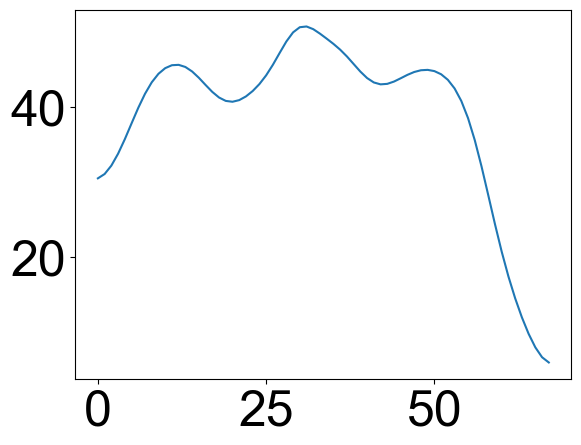

In [502]:
plt.plot(row.ts_speed)

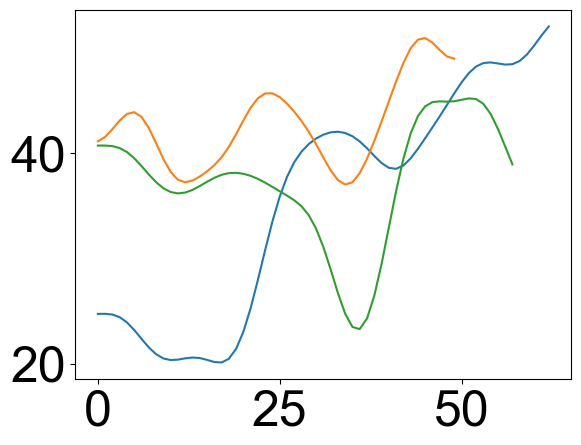

In [526]:
dark = light_dark[light_dark.task=='oadark']
dark = dark[~dark['obstacle_cluster'].isin([2,3])] 
dark = dark[dark.intial_lateral_error<0]
dark = dark[dark.intial_distance>=15]  

for ind,row in dark.sample(3).iterrows():
    plt.plot(row.ts_speed[:int(row.obstacle_ind)])

In [76]:
train_df.dist

0        47.072362
1        83.705297
2        65.953122
3        66.261621
4        41.281303
           ...    
9241     47.517792
9242     60.078692
9243     48.162045
9244    269.761641
9245    227.883437
Name: dist, Length: 9246, dtype: float64

In [80]:
light = light_dark[light_dark.task=='oa']
light[light.date_index == 0].dist.mean()

44.77713809333848

In [92]:
light.time.median()

2.9

In [91]:
train_df[train_df.date_index == -1].time.median()

4.016666666666667

<AxesSubplot: >

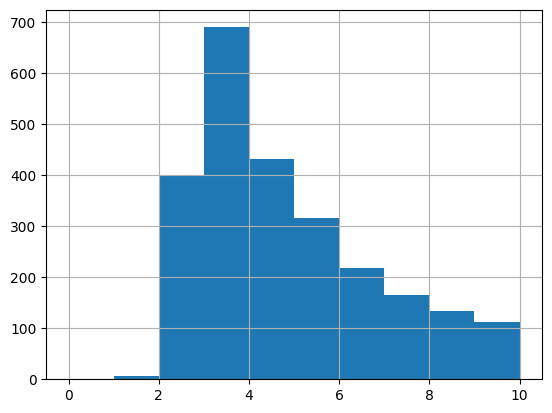

In [97]:
train_df.time.hist(range=(0,10))

<AxesSubplot: >

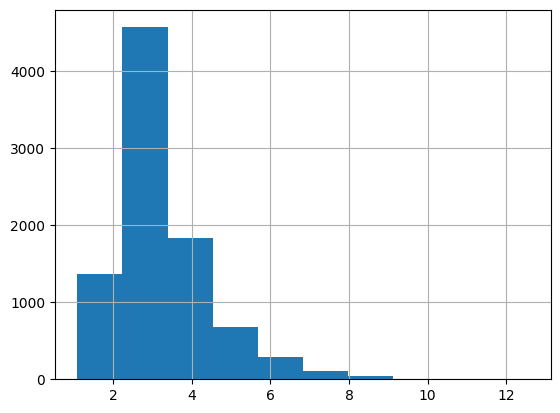

In [95]:
light.time.hist()

<AxesSubplot: >

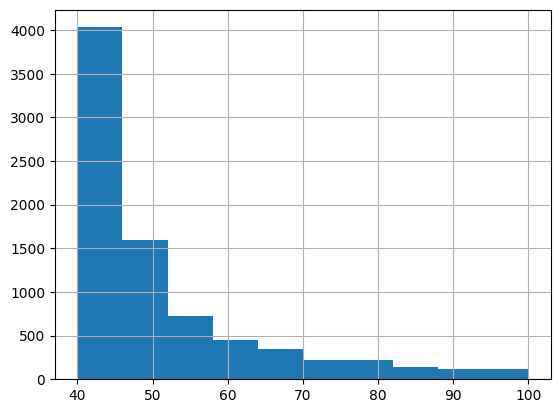

In [86]:
train_df.dist.hist(range=(40,100))

In [ ]:
train_df[train_df.date_index == -4].dist.

105.73310988404131

<AxesSubplot: >

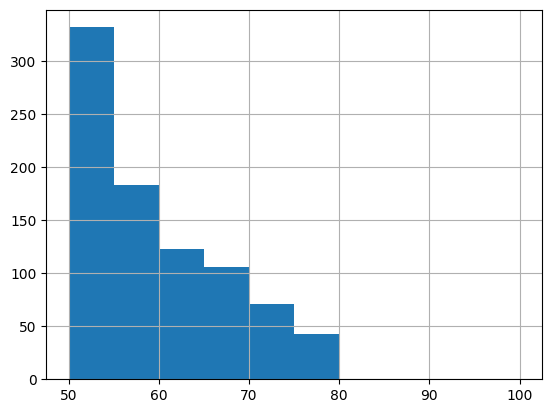

In [ ]:
light.dist.hist(range = (50,100))

In [73]:
def dist(df):
      for ind,row in df.iterrows(): 
        dist = np.nansum(np.abs(np.diff(row['ts_nose_x_cm'])))
        df.at[ind,'dist'] = dist
        


In [74]:
dist(train_df)

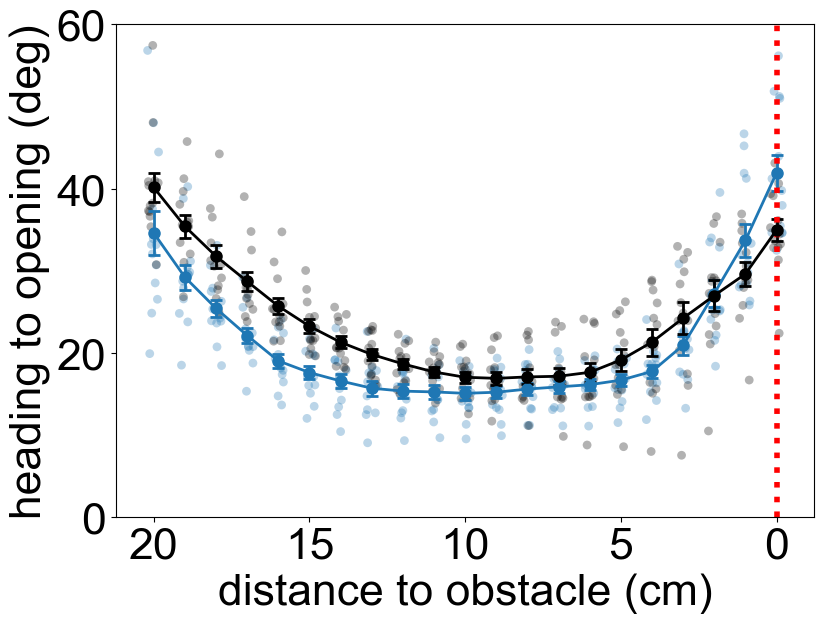

In [24]:
# Set font parameters to match previous plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
font = {'family': 'arial',
        'size': 32}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([light_dark])

data = drop_nans_in_columns(data, 'obstacle_ind')

data = data[data['obstacle_cluster'].isin([2,3])] 
#data = data[data.intial_lateral_error<0] 
data = data[data.intial_distance>=15] 


# Storage for data
light_means = []
dark_means = []
light_scatter = []  # For individual animal points
dark_scatter = []   # For individual animal points

for task, task_df in data.groupby(['task']):
    # Process each animal
    for animal, animal_df in task_df.groupby(['animal']):
        angle_array = np.empty([animal_df.shape[0], len(xnew)])
        angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                angle_array[i] = interpolater(xnew)
        
        animal_mean = np.nanmean(angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_means.append(animal_mean)
            light_scatter.append((x_jittered, animal_mean))
        else:
            dark_means.append(animal_mean)
            dark_scatter.append((x_jittered, animal_mean))

# Calculate population statistics
light_means = np.array(light_means)
dark_means = np.array(dark_means)

light_angle_mean = np.nanmean(light_means, axis=0)
dark_angle_mean = np.nanmean(dark_means, axis=0)

# Calculate standard error instead of standard deviation
light_sem = np.nanstd(light_means, axis=0) / np.sqrt(np.sum(~np.isnan(light_means), axis=0))
dark_sem = np.nanstd(dark_means, axis=0) / np.sqrt(np.sum(~np.isnan(dark_means), axis=0))

# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_angle_mean, yerr=light_sem, 
           fmt='-', color='tab:blue', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_angle_mean, yerr=dark_sem, 
           fmt='-', color='black', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting to match previous plots
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([0,20,40,60])
ax.set_ylabel('heading to opening (deg)', fontsize=32)
ax.set_xlabel('distance to obstacle (cm)', fontsize=32)
ax.axvline(0, color='r', ls=':', linewidth=4)

# Legend with matching style
#ax.legend(loc='lower left', fontsize=32, framealpha=0.8)

# Create custom legend handles
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='light',
          markerfacecolor='tab:blue', markersize=15),
    Line2D([0], [0], marker='o', color='w', label='dark',
          markerfacecolor='black', markersize=15)
]

# Update your legend call
#ax.legend(handles=legend_handles, loc='lower left', fontsize=32, framealpha=0.8)




plt.tight_layout()
plt.show()
plt.rcParams["font.weight"] = "normal"